# Parity oscillation analysis with AllSPCMs
Valid for experiments from 2026-06 until .... 

On 2025-12-05 I changed the name "SPCM0_SinglePhoton" to "SPCM0_SinglePhoton_parity" (same for SPCM1) to avoid conflict with GeneralVariableScan_HealthCheck. When doing health check, the microwave scan also saves data in SPCM0_SinglePhoton which messes up the dataset for parity oscillation analysis; we get more elements.


In [119]:
date_filters = ["2026-08-06", "2026-08-07", "2026-08-08", "2026-08-09"]

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import csv
import numpy as np
import os,sys
import PIL # for reading tif images
import h5py
import datetime as dt
import time
from scipy.optimize import curve_fit
from skimage.filters import threshold_otsu
from IPython.display import display, HTML ## for large prints

sys.path.append("..\\")
from h5_data_utilities import * # helper functions for dealing with h5 files
# from h5_data_utilities_node1 import * # helper functions for dealing with h5 files

def average_over_measurement(measurements, history):
    iteration = len(history) // measurements
    mean_by_iteration = [np.mean(history[j * measurements:(j + 1) * measurements]) for j in range(iteration)]
    return mean_by_iteration


fnames = get_files_by_criteria(date_filters, # only find files from these date directories
                               name_filters=["GeneralVariableScan"], # only find files containing all these strings
                               condition=lambda filename: True, # use this to filter by experiment parameters, like this: lambda filename: np.bool_(h5py.File(filename)['datasets']['set_current_coil_volts_at_finish'])
                               start_dir=results,
                               include_path=True, # if False, only return the name of the file, not the full path
                               print_filenames=False
)


only_show_i_greater_than = -1

print(f"found {len(fnames)} files")
for i,f in enumerate(fnames):
    if i > only_show_i_greater_than:
        try:
            ds = h5py.File(os.path.join(results, f))['datasets']
            scan_str = str_from_h5(ds['scan_variable1_name'])
            if str_from_h5(ds['scan_variable2_name']) != '':
                scan_str += ", " +str_from_h5(ds['scan_variable2_name'])
            print(f"file {i} ({f}) scanned over "+scan_str)
        except:

            print(f"oops... something wrong with {f}")

skipping C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-06\20\000038192-GeneralVariableScan_CatchError_atom_photon_parity_9_AllSPCM_scan_over_target_780_HWP.h5, which is corrupt
skipping C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-06\21\000038193-GeneralVariableScan_CatchError_atom_photon_parity_9_AllSPCM_scan_over_target_780_HWP.h5, which is corrupt
skipping C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-06\23\000038198-GeneralVariableScan_CatchError_atom_photon_parity_9_AllSPCM_scan_over_target_780_HWP.h5, which is corrupt
skipping C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-06\23\000038199-GeneralVariableScan_CatchError_atom_photon_parity_9_AllSPCM_scan_over_target_780_HWP.h5, which is corrupt
skipping C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-07\00\000038200-GeneralVariableScan_CatchError.h5, which is corrupt
skipping C:\Networking Experiment\artiq codes\artiq-master\results\20

## Combine files generated with GVS_HealthCheck_CatchError
If you run the experiment using GVS_HealthCheck_CatchError, it may generate multiple h5 files. This section, combines the files to be used for the analysis below.

#### Node1 code

In [35]:
# date_filters = ["2026-04-03"]
# date_filters = ["2026-06-04", "2026-06-05"]


from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import csv
import numpy as np
import os, sys
import PIL  # for reading tif images
import h5py
import datetime as dt
import time
from scipy.optimize import curve_fit
from skimage.filters import threshold_otsu
from IPython.display import display, HTML  # for large prints
import math

# sys.path.append("..\\")
from h5_data_utilities_node1 import *  # helper functions for dealing with h5 files


def average_over_measurement(measurements, history):
    iteration = len(history) // measurements
    mean_by_iteration = [
        np.mean(history[j * measurements:(j + 1) * measurements])
        for j in range(iteration)
    ]
    return mean_by_iteration


# -------------------------------------------------------
# 1) Find all *parent* files for GVS_HealthCheck_CatchError
# -------------------------------------------------------
fnames = get_files_by_criteria(
    date_filters,
    # name_filters=["GeneralVariableScan_HealthCheck_CatchError_parent_rid"],
    name_filters=["GeneralVariableScan_HealthCheck"],
    condition=lambda filename: True,
    start_dir=results,
    include_path=True,
    print_filenames=False
)

print(f"found {len(fnames)} 'parent_rid' files")


# -------------------------------------------------------
# 2) Group files by parent_rid ONLY (fallback to rid if needed)
# -------------------------------------------------------
parent_groups = {}  # key: parent_rid -> list of full paths

for f_rel in fnames:
    full_path = os.path.join(results, f_rel)
    # try:
    #     with h5py.File(full_path, "r") as hf:
    #         if "datasets" in hf and "parent_rid" in hf["datasets"]:
    #             parent_rid_val = int(hf["datasets"]["parent_rid"][()])
    #         elif "parent_rid" in hf:
    #             parent_rid_val = int(hf["parent_rid"][()])
    #         elif "datasets" in hf and "rid" in hf["datasets"]:
    #             parent_rid_val = int(hf["datasets"]["rid"][()])
    #             print(f"  WARNING: {full_path} has no parent_rid; using datasets/rid = {parent_rid_val}")
    #         elif "rid" in hf:
    #             parent_rid_val = int(hf["rid"][()])
    #             print(f"  WARNING: {full_path} has no parent_rid; using root rid = {parent_rid_val}")
    #         else:
    #             print(f"  WARNING: {full_path} has neither parent_rid nor rid; skipping")
    #             continue
    try:
        with h5py.File(full_path, "r") as hf:
            if "datasets" in hf and "parent_rid" in hf["datasets"]:
                parent_rid_val = int(hf["datasets"]["parent_rid"][()])
            elif "parent_rid" in hf:
                parent_rid_val = int(hf["parent_rid"][()])
            else:
                print(f"  WARNING: {full_path} has no parent_rid; skipping")
                continue
    except Exception as e:
        print(f"  ERROR opening {full_path}: {e}")
        continue

    parent_groups.setdefault(parent_rid_val, []).append(full_path)

print(f"found {len(parent_groups)} distinct logical scans (by parent_rid / rid fallback)")


# -------------------------------------------------------
# 3) Define which datasets to combine and how
# -------------------------------------------------------

# Datasets that are per *iteration* (length = #iterations)
per_iteration_datasets = [
    "scan_sequence1",
    # add others here if needed (1D, length=iterations)
]

# Datasets that are per *shot* (length = #iterations * n_measurements)
# Keep ONLY angle arrays here (no extra leading 0).
per_shot_datasets = [
    "angle_780_HWP",
    "angle_780_QWP",
]

# Datasets to concat blindly, with "leading 0" rule on *subsequent* files
# (SPCM counts, parity, and your slow diagnostics)
simple_concat_datasets = [
    "Magnetometer_MOT_X", "Magnetometer_MOT_Y", "Magnetometer_MOT_Z",
    "Magnetometer_OP_X", "Magnetometer_OP_Y", "Magnetometer_OP_Z",
    "Magnetometer_Zero_X", "Magnetometer_Zero_Y", "Magnetometer_Zero_Z",
    "REPUMP1_monitor", "REPUMP2_monitor", "atom_loading_wall_clock",
    "coil_driver_AX_MOT", "coil_driver_AY_MOT",
    "coil_driver_AZ_bottom_MOT", "coil_driver_AZ_top_MOT",
    "Sampler0_test", "SPCM0_test_RO",
    "SPCM0_RO1", "SPCM0_RO2", "SPCM1_RO1", "SPCM1_RO2",
    "SPCM0_SinglePhoton", "SPCM1_SinglePhoton",
    "BothSPCMs_RO1", "BothSPCMs_RO2", "n_excitation_cycles",
    "Atom_loading_time", "BothSPCMs_parity_RO",
    "SPCM0_SinglePhoton_parity", "SPCM1_SinglePhoton_parity"
]

# iteration & n_measurements datasets inside /datasets
iteration_dataset_name = "iteration"       # scalar: number of completed iterations in THAT file
nmeas_dataset_name = "n_measurements"      # scalar: shots per iteration


def _get_scalar_int_from_file(hf, dataset_name):
    """Try root first, then /datasets, return int or None."""
    if dataset_name in hf:
        return int(hf[dataset_name][()])
    if "datasets" in hf and dataset_name in hf["datasets"]:
        return int(hf["datasets"][dataset_name][()])
    return None


def _should_drop_leading_zero(arr):
    """
    Only drop a leading zero for a true 1D numeric array.
    This avoids ValueError from cases where arr[0] is itself array-like.
    """
    arr = np.asarray(arr)

    if arr.size == 0:
        return False

    if arr.ndim != 1:
        return False

    first = arr[0]

    if np.ndim(first) != 0:
        return False

    try:
        return first == 0
    except Exception:
        return False


def combine_logical_scan(file_list, output_path):
    """
    Combine all completed iterations from several
    GeneralVariableScan_HealthCheck_CatchError_parent_rid files
    into a single HDF5 file.

    Strategy:
      1) Copy the FIRST file completely (including /datasets).
      2) Recompute and overwrite ONLY:
           - per_iteration_datasets
           - per_shot_datasets
           - simple_concat_datasets
           - iteration (total completed iterations across all files)
      3) Keep all other scalar / string datasets from the first file
         (e.g., p_excitation, n_measurements, scan_variable1_name, etc.).

    For simple_concat_datasets:
      - Keep the leading 0 only for the FIRST file,
      - For subsequent files, drop a single leading 0 if present.
    """

    if not file_list:
        return

    # Skip if combined file already exists (so it's safe to re-run the cell)
    if os.path.exists(output_path):
        print(f"  Combined file already exists, skipping recompute:\n    {output_path}")
        return

    # Sort files by RID (if present) to keep time order; else by basename
    def _rid_or_name(path):
        try:
            with h5py.File(path, "r") as f:
                rid_val = _get_scalar_int_from_file(f, "rid")
                if rid_val is not None:
                    return rid_val
        except Exception:
            pass
        return os.path.basename(path)

    file_list = sorted(file_list, key=_rid_or_name)
    first = file_list[0]

    # --------------------------------------------------
    # 1) Copy FIRST file completely (including /datasets)
    # --------------------------------------------------
    with h5py.File(first, "r") as src, h5py.File(output_path, "w") as dst:
        for name, item in src.items():
            src.copy(name, dst, name)

    # --------------------------------------------------
    # 2) Build combined datasets and overwrite selected ones
    # --------------------------------------------------
    with h5py.File(output_path, "r+") as fout:
        if "datasets" not in fout:
            raise KeyError(f"{output_path} has no 'datasets' group after copy")

        ds_out = fout["datasets"]

        combined_iter_data = {nm: [] for nm in per_iteration_datasets}
        combined_shot_data = {nm: [] for nm in per_shot_datasets}
        combined_simple    = {nm: [] for nm in simple_concat_datasets}

        n_measurements_ref = None
        total_iterations = 0
        parent_rid_value = None

        for idx_file, path in enumerate(file_list):
            with h5py.File(path, "r") as fin:
                if "datasets" not in fin:
                    print(f"  WARNING: {path} has no 'datasets' group; skipping")
                    continue

                ds_in = fin["datasets"]

                # # Parent RID: prefer parent_rid, fallback to rid
                # if parent_rid_value is None:
                #     if "parent_rid" in ds_in:
                #         parent_rid_value = int(ds_in["parent_rid"][()])
                #     elif "parent_rid" in fin:
                #         parent_rid_value = int(fin["parent_rid"][()])
                #     elif "rid" in ds_in:
                #         parent_rid_value = int(ds_in["rid"][()])
                #         print(f"  WARNING: {path} missing parent_rid; using datasets/rid = {parent_rid_value}")
                #     elif "rid" in fin:
                #         parent_rid_value = int(fin["rid"][()])
                #         print(f"  WARNING: {path} missing parent_rid; using root rid = {parent_rid_value}")

                if parent_rid_value is None:
                    if "parent_rid" in ds_in:
                        parent_rid_value = int(ds_in["parent_rid"][()])
                    elif "parent_rid" in fin:
                        parent_rid_value = int(fin["parent_rid"][()])
                    else:
                        print(f"  WARNING: {path} has no parent_rid; skipping")
                        continue

                # Number of completed iterations in THIS file
                if iteration_dataset_name not in ds_in:
                    print(f"  WARNING: {path} missing {iteration_dataset_name}; skipping")
                    continue

                n_iter_file = int(ds_in[iteration_dataset_name][()])
                if n_iter_file <= 0:
                    print(f"  WARNING: {path} has non-positive iteration count ({n_iter_file}); skipping")
                    continue

                # Check n_measurements consistency across files
                if nmeas_dataset_name not in ds_in:
                    raise KeyError(f"{path} missing {nmeas_dataset_name} in datasets")

                n_meas = int(ds_in[nmeas_dataset_name][()])
                if n_measurements_ref is None:
                    n_measurements_ref = n_meas
                elif n_meas != n_measurements_ref:
                    raise ValueError(
                        f"Inconsistent n_measurements across files: "
                        f"{n_meas} vs {n_measurements_ref}"
                    )

                # ---- per-iteration datasets ----
                for nm in per_iteration_datasets:
                    if nm not in ds_in:
                        continue
                    arr = np.array(ds_in[nm])
                    combined_iter_data[nm].append(arr[:n_iter_file])

                # ---- per-shot datasets (no special zero handling) ----
                n_shots_file = n_iter_file * n_meas
                for nm in per_shot_datasets:
                    if nm not in ds_in:
                        continue
                    arr = np.array(ds_in[nm])
                    combined_shot_data[nm].append(arr[:n_shots_file])

                # ---- simple-concat datasets (special leading-zero rule) ----
                for nm in simple_concat_datasets:
                    if nm not in ds_in:
                        continue

                    arr = np.array(ds_in[nm])
                    pieces = combined_simple[nm]

                    # First chunk for this dataset: keep as-is
                    # Later chunks: drop one leading 0 only if this is a true 1D numeric vector
                    if len(pieces) > 0 and _should_drop_leading_zero(arr):
                        arr = arr[1:]

                    pieces.append(arr)

                total_iterations += n_iter_file

        # --------------------------------------------------
        # 3) Overwrite only the selected datasets in /datasets
        # --------------------------------------------------

        # 3.1 iteration = total number of completed iterations
        if iteration_dataset_name in ds_out:
            del ds_out[iteration_dataset_name]
        ds_out.create_dataset(iteration_dataset_name, data=int(total_iterations))

        # 3.2 per-iteration datasets
        for nm, pieces in combined_iter_data.items():
            if not pieces:
                continue
            data = np.concatenate(pieces)
            if nm in ds_out:
                del ds_out[nm]
            ds_out.create_dataset(nm, data=data)

        # 3.3 per-shot datasets
        for nm, pieces in combined_shot_data.items():
            if not pieces:
                continue
            data = np.concatenate(pieces)
            if nm in ds_out:
                del ds_out[nm]
            ds_out.create_dataset(nm, data=data)

        # 3.4 simple-concat datasets
        for nm, pieces in combined_simple.items():
            if not pieces:
                continue
            data = np.concatenate(pieces)
            if nm in ds_out:
                del ds_out[nm]
            ds_out.create_dataset(nm, data=data)

        # 3.5 ensure /datasets/parent_rid is set
        if parent_rid_value is not None:
            if "parent_rid" in ds_out:
                orig_parent = int(ds_out["parent_rid"][()])
                if orig_parent != parent_rid_value:
                    print(
                        f"WARNING: parent_rid mismatch between first file ({orig_parent}) "
                        f"and combined group ({parent_rid_value}); using {parent_rid_value}"
                    )
                    del ds_out["parent_rid"]
                    ds_out.create_dataset("parent_rid", data=int(parent_rid_value))
            else:
                ds_out.create_dataset("parent_rid", data=int(parent_rid_value))

        # 3.6 set root-level rid = parent_rid_value
        if parent_rid_value is not None:
            if "rid" in fout:
                del fout["rid"]
            fout.create_dataset("rid", data=int(parent_rid_value))

    print(f"  -> combined file written to:\n     {output_path}")


# -------------------------------------------------------
# 4) Run combination for each parent_rid group
# -------------------------------------------------------
combined_files = []

for parent_rid, files in parent_groups.items():
    files = sorted(files)  # deterministic order
    folder = os.path.dirname(files[0])
    combined_name = f"GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_{parent_rid}.h5"
    output_path = os.path.join(folder, combined_name)

    combine_logical_scan(files, output_path)
    combined_files.append(output_path)

print("\nDone. Combined files:")
for p in combined_files:
    print("  ", p)

found 63 'parent_rid' files
found 6 distinct logical scans (by parent_rid / rid fallback)
  -> combined file written to:
     C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-16\12\GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_18284.h5
  -> combined file written to:
     C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-16\17\GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_18290.h5
  -> combined file written to:
     C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-16\17\GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_18291.h5
  -> combined file written to:
     C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-16\18\GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_18292.h5
  -> combined file written to:
     C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-17\05\GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_18293.h5
  -> combi

#### Node2 code - combine with added functionalities
Notes:
* Generates combined file every time it is run. If pre-combined file exists, it overwrites the existing file to a new one.
* It saves the files that are merged in "merged_rid".
* It excludes combining duplicate files
* Makes comibined file even if a single file exists for a corresponding RID.

In [26]:
# date_filters = ["2026-04-03"]
date_filters = ["2026-07-15", "2026-07-16", "2026-07-17"]

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import csv
import numpy as np
import os, sys
import PIL
import h5py
import datetime as dt
import time
from scipy.optimize import curve_fit
from skimage.filters import threshold_otsu
from IPython.display import display, HTML
import math

from h5_data_utilities_node1 import *


# -------------------------------------------------------
# Helper functions
# -------------------------------------------------------

def average_over_measurement(measurements, history):
    iteration = len(history) // measurements
    mean_by_iteration = [
        np.mean(history[j * measurements:(j + 1) * measurements])
        for j in range(iteration)
    ]
    return mean_by_iteration


def _get_scalar_int_from_file(hf, dataset_name):
    if dataset_name in hf:
        return int(hf[dataset_name][()])

    if "datasets" in hf and dataset_name in hf["datasets"]:
        return int(hf["datasets"][dataset_name][()])

    return None


def _get_parent_rid_from_file(hf):
    if "datasets" in hf and "parent_rid" in hf["datasets"]:
        return int(hf["datasets"]["parent_rid"][()])

    if "parent_rid" in hf:
        return int(hf["parent_rid"][()])

    return None


def _should_drop_leading_zero(arr):
    arr = np.asarray(arr)

    if arr.size == 0:
        return False

    if arr.ndim != 1:
        return False

    first = arr[0]

    if np.ndim(first) != 0:
        return False

    try:
        return first == 0
    except Exception:
        return False


def deduplicate_files_by_rid(file_list):
    """
    Keep only the first file for each RID.
    Duplicate files with the same RID are silently skipped.
    """

    deduped = []
    seen_rids = set()

    def _rid_or_name(path):
        try:
            with h5py.File(path, "r") as f:
                rid_val = _get_scalar_int_from_file(f, "rid")
                if rid_val is not None:
                    return rid_val
        except Exception:
            pass

        return os.path.basename(path)

    file_list = sorted(file_list, key=_rid_or_name)

    for path in file_list:
        try:
            with h5py.File(path, "r") as f:
                rid_val = _get_scalar_int_from_file(f, "rid")
        except Exception as e:
            print(f"  ERROR opening {path}: {e}")
            continue

        if rid_val is None:
            deduped.append(path)
            continue

        if rid_val in seen_rids:
            continue

        seen_rids.add(rid_val)
        deduped.append(path)

    return deduped


# -------------------------------------------------------
# 1) Find raw candidate files
# -------------------------------------------------------

fnames = get_files_by_criteria(
    date_filters,
    name_filters=["GeneralVariableScan_HealthCheck"],
    condition=lambda filename: True,
    start_dir=results,
    include_path=True,
    print_filenames=False
)

# Do not use already-combined files as input files
fnames = [
    f for f in fnames
    if "combined" not in os.path.basename(f)
]

print(f"found {len(fnames)} raw candidate files")


# -------------------------------------------------------
# 2) Group files by parent_rid ONLY
# -------------------------------------------------------

parent_groups = {}

for f_rel in fnames:
    full_path = os.path.join(results, f_rel)

    try:
        with h5py.File(full_path, "r") as hf:
            parent_rid_val = _get_parent_rid_from_file(hf)

            if parent_rid_val is None:
                continue

    except Exception as e:
        print(f"  ERROR opening {full_path}: {e}")
        continue

    parent_groups.setdefault(parent_rid_val, []).append(full_path)

print(f"found {len(parent_groups)} distinct logical scans by parent_rid")


# -------------------------------------------------------
# 3) Define which datasets to combine and how
# -------------------------------------------------------

per_iteration_datasets = [
    "scan_sequence1",
]

per_shot_datasets = [
    "angle_780_HWP",
    "angle_780_QWP",
]

simple_concat_datasets = [
    "Magnetometer_MOT_X", "Magnetometer_MOT_Y", "Magnetometer_MOT_Z",
    "Magnetometer_OP_X", "Magnetometer_OP_Y", "Magnetometer_OP_Z",
    "Magnetometer_Zero_X", "Magnetometer_Zero_Y", "Magnetometer_Zero_Z",
    "REPUMP1_monitor", "REPUMP2_monitor", "atom_loading_wall_clock",
    "coil_driver_AX_MOT", "coil_driver_AY_MOT",
    "coil_driver_AZ_bottom_MOT", "coil_driver_AZ_top_MOT",
    "Sampler0_test", "SPCM0_test_RO",
    "SPCM0_RO1", "SPCM0_RO2", "SPCM1_RO1", "SPCM1_RO2",
    "SPCM0_SinglePhoton", "SPCM1_SinglePhoton",
    "BothSPCMs_RO1", "BothSPCMs_RO2", "n_excitation_cycles",
    "Atom_loading_time", "BothSPCMs_parity_RO",
    "SPCM0_SinglePhoton_parity", "SPCM1_SinglePhoton_parity",
]

iteration_dataset_name = "iteration"
nmeas_dataset_name = "n_measurements"


def combine_logical_scan(file_list, output_path):
    if not file_list:
        return

    def _rid_or_name(path):
        try:
            with h5py.File(path, "r") as f:
                rid_val = _get_scalar_int_from_file(f, "rid")
                if rid_val is not None:
                    return rid_val
        except Exception:
            pass

        return os.path.basename(path)

    file_list = sorted(file_list, key=_rid_or_name)

    output_abs = os.path.abspath(output_path)
    file_list = [
        p for p in file_list
        if os.path.abspath(p) != output_abs
    ]

    if not file_list:
        print("  skipping: no valid input files")
        return

    overwrote_existing_file = os.path.exists(output_path)

    if overwrote_existing_file:
        os.remove(output_path)

    first = None

    for path in file_list:
        try:
            with h5py.File(path, "r") as f:
                if "datasets" in f:
                    first = path
                    break
        except Exception:
            continue

    if first is None:
        print("  skipping: no valid first file")
        return

    with h5py.File(first, "r") as src, h5py.File(output_path, "w") as dst:
        for name, item in src.items():
            src.copy(name, dst, name)

    with h5py.File(output_path, "r+") as fout:
        if "datasets" not in fout:
            raise KeyError(f"{output_path} has no 'datasets' group after copy")

        ds_out = fout["datasets"]

        combined_iter_data = {nm: [] for nm in per_iteration_datasets}
        combined_shot_data = {nm: [] for nm in per_shot_datasets}
        combined_simple = {nm: [] for nm in simple_concat_datasets}

        n_measurements_ref = None
        total_iterations = 0
        parent_rid_value = None
        merged_rids = []

        for path in file_list:
            try:
                fin = h5py.File(path, "r")
            except Exception as e:
                print(f"  ERROR opening {path}: {e}")
                continue

            with fin:
                if "datasets" not in fin:
                    continue

                ds_in = fin["datasets"]

                this_parent_rid = _get_parent_rid_from_file(fin)

                if this_parent_rid is None:
                    continue

                if parent_rid_value is None:
                    parent_rid_value = this_parent_rid
                elif this_parent_rid != parent_rid_value:
                    continue

                if iteration_dataset_name not in ds_in:
                    continue

                n_iter_file = int(ds_in[iteration_dataset_name][()])
                if n_iter_file <= 0:
                    continue

                if nmeas_dataset_name not in ds_in:
                    raise KeyError(f"{path} missing {nmeas_dataset_name} in datasets")

                n_meas = int(ds_in[nmeas_dataset_name][()])
                if n_measurements_ref is None:
                    n_measurements_ref = n_meas
                elif n_meas != n_measurements_ref:
                    raise ValueError(
                        f"Inconsistent n_measurements across files: "
                        f"{n_meas} vs {n_measurements_ref}"
                    )

                source_rid = _get_scalar_int_from_file(fin, "rid")
                if source_rid is None:
                    source_rid = -1

                merged_rids.append(source_rid)

                for nm in per_iteration_datasets:
                    if nm not in ds_in:
                        continue

                    arr = np.array(ds_in[nm])
                    combined_iter_data[nm].append(arr[:n_iter_file])

                n_shots_file = n_iter_file * n_meas

                for nm in per_shot_datasets:
                    if nm not in ds_in:
                        continue

                    arr = np.array(ds_in[nm])
                    combined_shot_data[nm].append(arr[:n_shots_file])

                for nm in simple_concat_datasets:
                    if nm not in ds_in:
                        continue

                    arr = np.array(ds_in[nm])
                    pieces = combined_simple[nm]

                    if len(pieces) > 0 and _should_drop_leading_zero(arr):
                        arr = arr[1:]

                    pieces.append(arr)

                total_iterations += n_iter_file

        if total_iterations == 0:
            raise RuntimeError(
                f"No valid iterations were merged for output file:\n{output_path}"
            )

        if iteration_dataset_name in ds_out:
            del ds_out[iteration_dataset_name]
        ds_out.create_dataset(iteration_dataset_name, data=int(total_iterations))

        for nm, pieces in combined_iter_data.items():
            if not pieces:
                continue

            data = np.concatenate(pieces)

            if nm in ds_out:
                del ds_out[nm]

            ds_out.create_dataset(nm, data=data)

        for nm, pieces in combined_shot_data.items():
            if not pieces:
                continue

            data = np.concatenate(pieces)

            if nm in ds_out:
                del ds_out[nm]

            ds_out.create_dataset(nm, data=data)

        for nm, pieces in combined_simple.items():
            if not pieces:
                continue

            data = np.concatenate(pieces)

            if nm in ds_out:
                del ds_out[nm]

            ds_out.create_dataset(nm, data=data)

        if parent_rid_value is not None:
            if "parent_rid" in ds_out:
                del ds_out["parent_rid"]

            ds_out.create_dataset("parent_rid", data=int(parent_rid_value))

        if parent_rid_value is not None:
            if "rid" in fout:
                del fout["rid"]

            fout.create_dataset("rid", data=int(parent_rid_value))

        if "merged_rids" in ds_out:
            del ds_out["merged_rids"]

        ds_out.create_dataset(
            "merged_rids",
            data=np.array(merged_rids, dtype=np.int64)
        )

    if overwrote_existing_file:
        print(f"  -> overwrote existing combined file: {os.path.basename(output_path)}")
    else:
        print(f"  -> wrote new combined file: {os.path.basename(output_path)}")

    print(f"     merged_rids = {merged_rids}")


# -------------------------------------------------------
# 4) Run combination for each parent_rid group
# -------------------------------------------------------

combined_files = []

for parent_rid, files in parent_groups.items():
    n_files_before_dedup = len(files)
    files = deduplicate_files_by_rid(files)

    print(
        f"\nparent_rid = {parent_rid}: "
        f"using {len(files)} unique RID files from {n_files_before_dedup} raw files"
    )

    if len(files) == 0:
        print("  skipping: no files left")
        continue

    folder = os.path.dirname(files[0])
    combined_name = f"GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_{parent_rid}.h5"
    output_path = os.path.join(folder, combined_name)

    combine_logical_scan(files, output_path)
    combined_files.append(output_path)


print("\nDone. Combined files:")
for p in combined_files:
    print("  ", os.path.basename(p))

found 61 raw candidate files
found 6 distinct logical scans by parent_rid

parent_rid = 18284: using 2 unique RID files from 4 raw files
  -> overwrote existing combined file: GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_18284.h5
     merged_rids = [18284, 18286]

parent_rid = 18290: using 12 unique RID files from 24 raw files
  -> overwrote existing combined file: GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_18290.h5
     merged_rids = [18297, 18299, 18311, 18315, 18319, 18333]

parent_rid = 18291: using 8 unique RID files from 16 raw files
  -> overwrote existing combined file: GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_18291.h5
     merged_rids = [18305, 18309, 18317, 18325]

parent_rid = 18292: using 7 unique RID files from 14 raw files
  -> overwrote existing combined file: GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_18292.h5
     merged_rids = [18335, 18337, 18343]

parent_rid = 18293: using 1 unique RID f

RuntimeError: No valid iterations were merged for output file:
C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-17\06\GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_18294.h5

#### searching only "combined" files
* Here, it only searches for file names that contain "combined"

In [36]:

fnames = get_files_by_criteria(
    date_filters,
    name_filters=["GeneralVariableScan"],
    condition=lambda filename: True,
    start_dir=results,
    include_path=True,
    print_filenames=False,
)

# Keep only combined files
fnames = [
    f for f in fnames
    if "combined" in os.path.basename(f)
]

only_show_i_greater_than = -1

print(f"found {len(fnames)} combined files")

for i, f in enumerate(fnames):
    if i > only_show_i_greater_than:
        try:
            with h5py.File(f, "r") as h5f:
                ds = h5f["datasets"]

                scan_str = str_from_h5(ds["scan_variable1_name"])

                if str_from_h5(ds["scan_variable2_name"]) != "":
                    scan_str += ", " + str_from_h5(ds["scan_variable2_name"])

                rid = int(h5f["rid"][()]) if "rid" in h5f else int(ds["rid"][()])
                n_measurements = int(ds["n_measurements"][()])

                if "merged_rids" in ds:
                    merged_rids = ds["merged_rids"][()]
                else:
                    merged_rids = "not recorded"

                print(
                    f"file {i}: RID {rid}, {os.path.basename(f)}\n"
                    f"    scanned over {scan_str}\n"
                    f"    n_measurements = {n_measurements}\n"
                    f"    merged_rids = {merged_rids}"
                )

        except Exception as e:
            print(f"oops... something wrong with file {i}: {f}")
            print(e)

skipping C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-16\08\000018272-GeneralVariableScan_CatchError_atom_photon_parity_6_node2_AllSPCM_scan_over_target_780_HWP.h5, which is corrupt
found 6 combined files
file 0: RID 18284, GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_18284.h5
    scanned over target_780_HWP
    n_measurements = 200
    merged_rids = not recorded
file 1: RID 18290, GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_18290.h5
    scanned over target_780_HWP
    n_measurements = 200
    merged_rids = not recorded
file 2: RID 18291, GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_18291.h5
    scanned over target_780_HWP
    n_measurements = 200
    merged_rids = not recorded
file 3: RID 18292, GeneralVariableScan_HealthCheck_CatchError_parent_rid_combined_18292.h5
    scanned over target_780_HWP
    n_measurements = 200
    merged_rids = not recorded
file 4: RID 18293, GeneralVariableScan_HealthCheck_CatchEr

# Choose file and anlyze

In [120]:
# ### the file(s) to analyze:

file_indices = {
    # 16:'',
    # 18:'',
    # 20:'',
    # 22:'',
    # 24:'',
    # 25:'',
    # 26:'',
    # 27:'',
    # 28:'',
    # 29:'',
    # 31:'',
    # 32:''


    # 44:'',
    # 45:'',
    # 47:'',
    # 51:'',
    # 52:'',
    # 53:'',
    # 54:'',
    # 55:'',
    # 56:'',
    # 58:'',
    # 60:'',


    ##100us
    # 61:'',
    # 63:'',
    # 64: '', 66: '', 68: '', 70: '', 72: '', 74: '', 76: '',

    78:'', 80:'',
    82: '', 84: '', 86: '', 88: '', 90: '', 92: '', 94: '', 96:'', 98:'', 100:''

} 


#### Accounting for SPCM inefficiency - Node2
eta_SPCM0_OtherNode_channel = 0.98
eta_SPCM1_OtherNode_channel = 0.84
eta_SPCM0_channel = 1.0
eta_SPCM1_channel = 0.97


# eta_SPCM0_channel = 1.0
# eta_SPCM1_channel = 0.96
# eta_SPCM0_OtherNode_channel = 0.97
# eta_SPCM1_OtherNode_channel = 0.82


single_atom_threshold = 14000


### General atom loading analysis

experiment: atom_photon_parity_9_AllSPCM_experiment
override: {'target_780_QWP':70.0,'t_MW_RF_pulse':0.0,'f_microwaves_m11_dds': 331.913*MHz,'monitor_magnetometer_in_end_measurement': False, 'tune_852_waveplates_to_target_in_experiment':False,'t_FORT_drop':0*us, 'f_microwaves_dds': self.f_microwaves_00_dds,'t_microwave_pulse':self.t_microwave_00_pulse,'p_excitation':-4.0, 't_pumping':100*us, 't_delay_in_bob_mu': 189 ,  't_PGC_after_loading':0.6*ms, 't_recooling_after_first_shot':0*ms, 'n_excitation_attempts':2, 'p_cooling_DP_RO': 0.8,'t_recooling':1*ms, 'atom_check_every_n':50, 'recool_every_n_OP':1, 't_photon_collection_time':150*ns}
# of iterations:  10


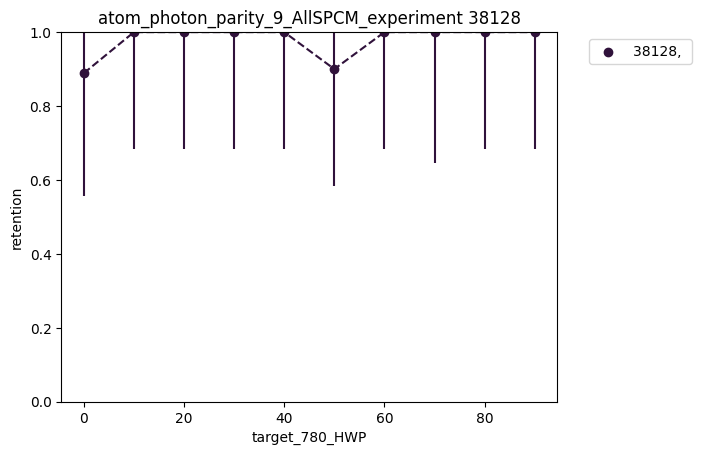

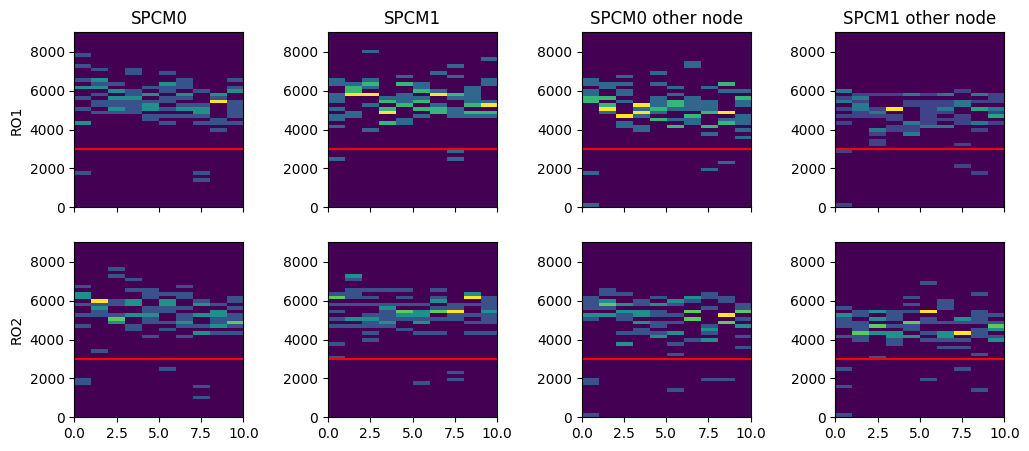

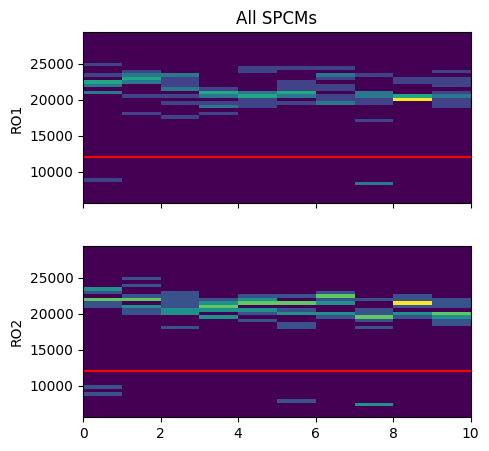

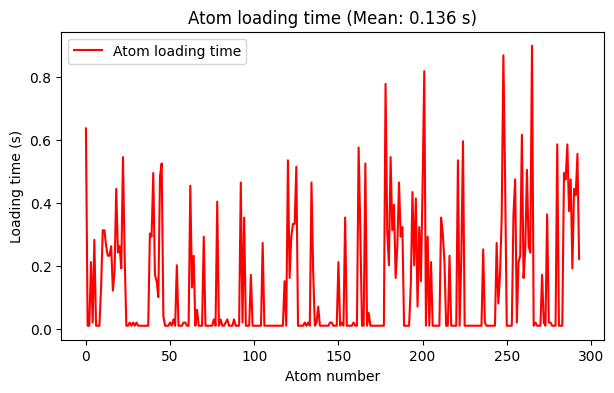

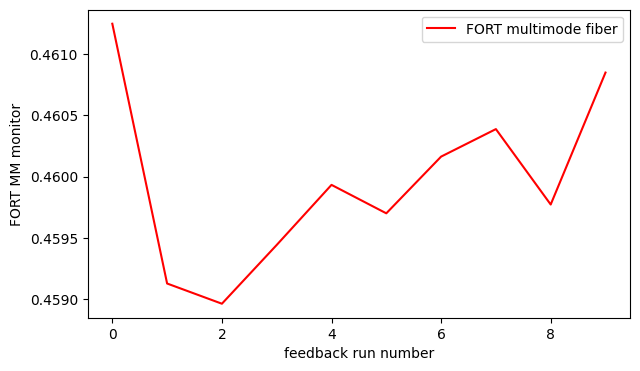

In [4]:
"""
Temporary monkey patch 2026/07/08
"""

# file_indices = {i: '' for i in range(0, 17, 2)}

compare = True # compare multiple files in the same retention and loading plots

otsu_threshold = False # compute threshold using Otsu method instead doing it by eye. only work when require atom loading = False

user_set_manual_threshold = 17000
manual_threshold = False


showhist = True
showloading = False
custom_xlabel = True
merge_data = False # if True, the datasets will be combined, and if fit=True, the new merged data will be fit. don't try this in 2D
fit = False

showhist_counts = False 

# for plotting
legend_vars =[]   #legend_vars = ['AY_volts_OP', 'f_microwaves_dds'] # will be included in the plot legend
xform_and_label = {}
loc='best'
ret_cmap = mpl.colormaps['turbo']
ldng_cmap = mpl.colormaps['winter']

if compare:
    if showloading:
        fig_ret,axes = plt.subplots(nrows=2, sharex=False, figsize=(10, 6))
        ax_ret, ax_ldng = axes
    else:
        fig_ret,ax_ret = plt.subplots()


SPCM0_RO1_hists = []
SPCM0_RO2_hists = []
SPCM1_RO1_hists = []
SPCM1_RO2_hists = []
SPCM0_OtherNode_RO1_hists = []
SPCM0_OtherNode_RO2_hists = []
SPCM1_OtherNode_RO1_hists = []
SPCM1_OtherNode_RO2_hists = []
BothSPCMs_RO1_hists = []
BothSPCMs_RO2_hists = []
AllSPCMs_RO1_hists = []
AllSPCMs_RO2_hists = []
mean1_by_iteration = []
mean2_by_iteration = []

merged_retention = np.array([])
merged_scan_sequence1 = np.array([])
merged_errs = np.array([])
rid_str = ''

all_atom_loading_times = []
all_atom_loading_wall_clocks = []

for idx,f_item in enumerate(file_indices.items()):
    f_idx,f_comment = f_item   # idx - f_item = {f_idx: f_comment}
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    print("experiment:",experiment_function)
    print("override:",override_ExperimentVariables)

    iterations = len(scan_sequence1) #int(len(SPCM0_RO1)/n_measurements)
    print("# of iterations: ", iterations)

    all_atom_loading_times.append(Atom_loading_time[1:])
    all_atom_loading_wall_clocks.append(atom_loading_wall_clock[1:])
    
    if otsu_threshold:
        # thresh = threshold_otsu(BothSPCMs_RO1)
        thresh = threshold_otsu(AllSPCMs_RO1)

        print("threshold_otsu: ", thresh)
    elif manual_threshold:
        cutoff1 = cutoff2 = user_set_manual_threshold * t_SPCM_first_shot
    else:
        # cutoff1 = cutoff2 = 15000 * t_SPCM_first_shot

        cutoff1 = cutoff2 = single_atom_threshold * t_SPCM_first_shot
        # cutoff1 = cutoff2 = two_atom_threshold * t_SPCM_first_shot

    
    ### for plotting 
    ### xsteps_xform is a function that can transform scan_sequence1 for plotting. Here it is equal to identity, i.e. no change in scan_sequence1.
    if scan_variable1_name in xform_and_label and custom_xlabel:
        xsteps_xform, xlabel = (xform_and_label[scan_variable1_name]['xsteps_xform'], xform_and_label[scan_variable1_name]['xlabel'])
    else:
        xsteps_xform, xlabel = (lambda x: x, scan_variable1_name)
        

    legend_string = ''
    for a in legend_vars:
        legend_string += f'{a}={locals()[a]}, '
    legend_string = legend_string[:-2]
    f_comment += legend_string

    
    ### get_loading_and_retention
    ### These array have length = iterations
    # retention_array, loading_rate_array, n_atoms_loaded_array = get_loading_and_retention(BothSPCMs_RO1, BothSPCMs_RO2, n_measurements, iterations, cutoff1, otsu=otsu_threshold)
    retention_array, loading_rate_array, n_atoms_loaded_array = get_loading_and_retention(AllSPCMs_RO1, AllSPCMs_RO2, n_measurements, iterations, cutoff1, otsu=otsu_threshold)


    ### Necessary to analyze data with 2 scan_sequences
    ### reshaping each array into a 2D array with shape = shape, with order = 'F' (Fortran-style) to sort column by column
    
    ncols = len(scan_sequence2)
    nrows = len(scan_sequence1)
    shape = (len(scan_sequence2),len(scan_sequence1))
    loading_rate_raveled = np.reshape(loading_rate_array,shape,order='F') # rows have constant variable2
    n_atoms_loaded_raveled = np.reshape(n_atoms_loaded_array,shape,order='F') # rows have constant variable2
    retention_raveled = np.reshape(retention_array,shape,order='F') # rows have constant variable2

    
    # ### show historam of first_shot and second_shot
    # histMin = np.min([SPCM0_RO1, SPCM0_RO2, SPCM1_RO1, SPCM1_RO2, SPCM0_OtherNode_RO1, SPCM0_OtherNode_RO2, SPCM1_OtherNode_RO1, SPCM1_OtherNode_RO2])/t_SPCM_first_shot ## boundary for the histogram plots
    # histMax = np.max([SPCM0_RO1, SPCM0_RO2, SPCM1_RO1, SPCM1_RO2, SPCM0_OtherNode_RO1, SPCM0_OtherNode_RO2, SPCM1_OtherNode_RO1, SPCM1_OtherNode_RO2])/t_SPCM_first_shot


    ### Histogram boundaries for individual SPCMs
    single_hist_sources = [
        np.asarray(SPCM0_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM1_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM0_OtherNode_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM1_OtherNode_RO1) / t_SPCM_first_shot,
    
        np.asarray(SPCM0_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM1_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM0_OtherNode_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM1_OtherNode_RO2) / t_SPCM_second_shot,
    ]
    
    single_hist_sources = [x.ravel() for x in single_hist_sources if x.size > 0]
    
    histMin_single = min(np.min(x) for x in single_hist_sources)
    histMax_single = max(np.max(x) for x in single_hist_sources)
    
    
    ### Histogram boundaries for AllSPCMs
    all_hist_sources = [
        np.asarray(AllSPCMs_RO1) / t_SPCM_first_shot,
        np.asarray(AllSPCMs_RO2) / t_SPCM_second_shot,
    ]
    
    all_hist_sources = [x.ravel() for x in all_hist_sources if x.size > 0]
    
    histMin_all = min(np.min(x) for x in all_hist_sources)
    histMax_all = max(np.max(x) for x in all_hist_sources)


    
    if showhist:
        bins_single = np.linspace(histMin_single, histMax_single, 50)
        bins_all = np.linspace(histMin_all, histMax_all, 50)
    
        SPCM0_RO1_hists.append(
            [np.histogram(SPCM0_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_RO2_hists.append(
            [np.histogram(SPCM0_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_RO1_hists.append(
            [np.histogram(SPCM1_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_RO2_hists.append(
            [np.histogram(SPCM1_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_OtherNode_RO1_hists.append(
            [np.histogram(SPCM0_OtherNode_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_OtherNode_RO2_hists.append(
            [np.histogram(SPCM0_OtherNode_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_OtherNode_RO1_hists.append(
            [np.histogram(SPCM1_OtherNode_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_OtherNode_RO2_hists.append(
            [np.histogram(SPCM1_OtherNode_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        AllSPCMs_RO1_hists.append(
            [np.histogram(AllSPCMs_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_all)[0]
             for i in range(iterations)]
        )
    
        AllSPCMs_RO2_hists.append(
            [np.histogram(AllSPCMs_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_all)[0]
             for i in range(iterations)]
        )

    
    ### plot a retention curve vs variable 1 for each variable 2 value
    for i, retention, loading, n_loaded, var2 in zip(range(len(scan_sequence2)), retention_raveled, loading_rate_raveled, n_atoms_loaded_raveled, scan_sequence2):
        
        errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
        if not compare:
            if showloading:
                    fig_ret,axes = plt.subplots(nrows=2, sharex=False)
                    ax_ret, ax_ldng = axes
            else:
                fig_ret,ax_ret = plt.subplots()
                
        if not merge_data:
            ax_ret.scatter(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], label=str(rid)+', '+f_comment, color=ret_cmap(idx/len(file_indices)))
            ax_ret.errorbar(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], errs[loading > 0], ls='none',color=ret_cmap(idx/len(file_indices)))
            ax_ret.set_ylim((0,1))

            ### for fitting
            ### Auto-detect rough center from minimum retention
            fit_dict = {}
            min_idx = np.argmin(retention_array)
            initial_center = scan_sequence1[min_idx]
            p0 = [initial_center, 10e3, 0.9] # [center, width, depth]
            
            ### using a  Gaussian function for now:
            fit_dict = {
                scan_variable1_name: {
                    'model': lambda x, center, sigma, depth: 0.80*(1 - depth * np.exp(-((x - center)**2/(2*sigma**2)))),
                    'p0': p0,
                    'bounds': ([min(scan_sequence1), 0, 0], [max(scan_sequence1), np.inf, 1]),
                    'params': ['center', 'sigma', 'depth']
                }
            }

            if not ncols > 1 and fit and scan_variable1_name in fit_dict:
                popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
                fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
                print(fit_str)
                hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
                hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
                ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color=ret_cmap(idx/len(file_indices)),label=fit_str)
            else:
                ax_ret.plot(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0],linestyle='--',color=ret_cmap(idx/len(file_indices)))
    
            if not showloading:
                ax_ret.set_xlabel(xlabel)
            ax_ret.set_ylabel("retention")
            #ax_ret.legend(loc=loc)
            ax_ret.legend(bbox_to_anchor=(1.05, 1), loc='upper left')      # This will show the legend outside the plot
            
        else:
            merged_retention = np.concatenate((merged_retention,retention[loading > 0]))
            merged_scan_sequence1 = np.concatenate((merged_scan_sequence1, scan_sequence1[loading > 0]))
            merged_errs = np.concatenate((merged_errs, errs[loading > 0]))
            rid_str += str(rid) + ', '
    
        if showloading:
            ax_ldng.plot(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], linestyle='--',color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.scatter(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], label=rid, color=ldng_cmap(idx/len(file_indices)))
            errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
            ax_ldng.errorbar(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], errs[loading > 0], ls='none', color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.set_ylim((0,1))
            ax_ldng.set_xlabel(xlabel)
            ax_ldng.set_ylabel("loading rate")


if merge_data:
    retention = merged_retention
    scan_sequence1 = merged_scan_sequence1
    errs = merged_errs

    ax_ret.scatter(xsteps_xform(scan_sequence1), retention, color='plum')
    ax_ret.errorbar(xsteps_xform(scan_sequence1), retention, errs, ls='none',color='plum')
    ax_ret.set_ylim((0,1))
    
    if not ncols > 1 and fit and scan_variable1_name in fit_dict:        
        popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
        hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
        hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
        fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
        print(fit_str)
        ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color='violet', label=fit_str)
        ax_ret.legend()
    else:
        ax_ret.plot(xsteps_xform(scan_sequence1), retention,linestyle='--',color='violet')


if not compare or len(file_indices)==1:
    ax_ret.set_title(experiment_function+' '+str(rid))
elif merge_data:
    ax_ret.set_title(experiment_function+' '+ rid_str[:-2])
else:
    ax_ret.set_title(experiment_function)

if showhist:
    ### Individual SPCM plots
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 5), sharex=True)
    ax, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.ravel()

    ### RO1: SPCM0
    cax = ax.imshow(np.array(SPCM0_RO1_hists[0]).transpose(), origin='lower',
                    extent=[0, iterations, histMin_single, histMax_single])
    ax.set_ylabel("RO1")
    ax.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax.set_aspect('auto')
    ax.set_title("SPCM0")

    ### RO1: SPCM1
    cax2 = ax2.imshow(np.array(SPCM1_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax2.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax2.set_aspect('auto')
    ax2.set_title("SPCM1")

    ### RO1: SPCM0 Other Node
    cax3 = ax3.imshow(np.array(SPCM0_OtherNode_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax3.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax3.set_aspect('auto')
    ax3.set_title("SPCM0 other node")

    ### RO1: SPCM1 Other Node
    cax4 = ax4.imshow(np.array(SPCM1_OtherNode_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax4.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax4.set_aspect('auto')
    ax4.set_title("SPCM1 other node")


    ### RO2: SPCM0
    cax5 = ax5.imshow(np.array(SPCM0_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax5.set_ylabel("RO2")
    ax5.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax5.set_aspect('auto')

    ### RO2: SPCM1
    cax6 = ax6.imshow(np.array(SPCM1_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax6.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax6.set_aspect('auto')

    ### RO2: SPCM0 Other Node
    cax7 = ax7.imshow(np.array(SPCM0_OtherNode_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax7.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax7.set_aspect('auto')

    ### RO2: SPCM1 Other Node
    cax8 = ax8.imshow(np.array(SPCM1_OtherNode_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax8.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax8.set_aspect('auto')

    plt.subplots_adjust(hspace=0.2, wspace=0.5)


    ### All SPCMs plotted separately
    fig_all, axes_all = plt.subplots(nrows=2, ncols=1, figsize=(5, 5), sharex=True)
    ax_all1, ax_all2 = axes_all.ravel()

    ### RO1: All SPCMs
    cax_all1 = ax_all1.imshow(np.array(AllSPCMs_RO1_hists[0]).transpose(), origin='lower',
                              extent=[0, iterations, histMin_all, histMax_all])
    ax_all1.set_ylabel("RO1")
    ax_all1.axhline(cutoff1 / t_SPCM_first_shot, color='red')
    ax_all1.set_aspect('auto')
    ax_all1.set_title("All SPCMs")

    ### RO2: All SPCMs
    cax_all2 = ax_all2.imshow(np.array(AllSPCMs_RO2_hists[0]).transpose(), origin='lower',
                              extent=[0, iterations, histMin_all, histMax_all])
    ax_all2.set_ylabel("RO2")
    ax_all2.axhline(cutoff2 / t_SPCM_second_shot, color='red')
    ax_all2.set_aspect('auto')

    plt.subplots_adjust(hspace=0.25)

plt.show()



#### Plot the combined Atom_loading_time values
## We can slice the array to separate iterations later, if we want.
combined_atom_loading_times = [t for loading_times in all_atom_loading_times for t in loading_times]
mean_loading_time = np.mean(combined_atom_loading_times)
plt.figure(figsize=(7, 4))
plt.plot(combined_atom_loading_times, 'r-', label='Atom loading time')
plt.xlabel("Atom number")
plt.ylabel("Loading time (s)")
plt.title(f"Atom loading time (Mean: {mean_loading_time:.3f} s)") 
# plt.title(f"Combined Atom Loading Time for All Files")
plt.legend(loc='best')
plt.show()


#### Plot FORT multimode fiber 
plt.figure(figsize=(7, 4))
plt.plot(FORT_MM_monitor, 'r-', label='FORT multimode fiber')
plt.xlabel("feedback run number")
plt.ylabel("FORT MM monitor")
# plt.title(f"FORT MM fiber")
plt.legend(loc='best')
plt.show()


# # Plot the histogram of combined Atom_loading_time
# plt.figure(figsize=(7, 4))
# plt.hist(combined_atom_loading_times, bins=50, edgecolor='black', alpha=0.7)
# plt.xlabel("Atom Loading Time (s)")
# plt.ylabel("Frequency")
# plt.title(f"Histogram of Combined Atom Loading Time")
# plt.show()



### SPCM efficiency analysis

RID: 38213, file index: 44
experiment: atom_photon_parity_9_AllSPCM_experiment
override: {'t_photon_collection_time':150*ns, 'target_780_QWP':25.0,'t_start_MW_mapping_mu':8500,'t_MW_RF_pulse':122*us,'n_excitation_attempts':1, 'monitor_magnetometer_in_end_measurement':False}
# of iterations: 10
RID: 38215, file index: 45
experiment: atom_photon_parity_9_AllSPCM_experiment
override: {'t_photon_collection_time':150*ns, 'target_780_QWP':20.0,'t_start_MW_mapping_mu':8500,'t_MW_RF_pulse':122*us,'n_excitation_attempts':1, 'monitor_magnetometer_in_end_measurement':False}
# of iterations: 10
RID: 38216, file index: 47
experiment: atom_photon_parity_9_AllSPCM_experiment
override: {'t_photon_collection_time':150*ns, 'target_780_QWP':15.0,'t_start_MW_mapping_mu':8500,'t_MW_RF_pulse':122*us,'n_excitation_attempts':1, 'monitor_magnetometer_in_end_measurement':False}
# of iterations: 10
RID: 38220, file index: 51
experiment: atom_photon_parity_9_AllSPCM_experiment
override: {'t_photon_collection_time

,RID,File index,SPCM,Cutoff (counts/s),RO1 values above cutoff,RO1 mean above cutoff (counts/s),RO2 values above cutoff,RO2 mean above cutoff (counts/s),Combined values above cutoff,Combined mean above cutoff (counts/s),Proportional mean above cutoff
0,38213,44,SPCM0,4000,55375,5412.2,54163,5441.9,109538,5426.9,1.0000
1,38213,44,SPCM1,3700,57439,5127.8,56226,5135.4,113665,5131.5,0.9456
2,38213,44,SPCM0_OtherNode,3900,54855,5237.5,53927,5268.1,108782,5252.7,0.9679
3,38213,44,SPCM1_OtherNode,3100,57607,4413.4,56363,4409.6,113970,4411.5,0.8129
4,38215,45,SPCM0,4000,68638,5417.1,67687,5453.2,136325,5435.0,1.0000
5,38215,45,SPCM1,3700,68476,5034.6,67104,5029.4,135580,5032.0,0.9259
6,38215,45,SPCM0_OtherNode,3900,68297,5246.5,67437,5286.3,135734,5266.3,0.9690
7,38215,45,SPCM1_OtherNode,3100,68912,4320.9,67578,4316.3,136490,4318.6,0.7946
8,38216,47,SPCM0,4000,52118,5310.7,51153,5329.8,103271,5320.2,1.0000
9,38216,47,SPCM1,3700,55593,5199.8,54594,5217.2,110187,5208.4,0.9790



RID: 38213, file index: 44
eta_SPCM0_channel = 1.0
eta_SPCM1_channel = 0.95
eta_SPCM0_OtherNode_channel = 0.97
eta_SPCM1_OtherNode_channel = 0.81

RID: 38215, file index: 45
eta_SPCM0_channel = 1.0
eta_SPCM1_channel = 0.93
eta_SPCM0_OtherNode_channel = 0.97
eta_SPCM1_OtherNode_channel = 0.79

RID: 38216, file index: 47
eta_SPCM0_channel = 1.0
eta_SPCM1_channel = 0.98
eta_SPCM0_OtherNode_channel = 0.97
eta_SPCM1_OtherNode_channel = 0.84

RID: 38220, file index: 51
eta_SPCM0_channel = 1.0
eta_SPCM1_channel = 0.95
eta_SPCM0_OtherNode_channel = 0.97
eta_SPCM1_OtherNode_channel = 0.82

RID: 38221, file index: 52
eta_SPCM0_channel = 1.0
eta_SPCM1_channel = 1.0
eta_SPCM0_OtherNode_channel = 0.96
eta_SPCM1_OtherNode_channel = 0.86

RID: 38222, file index: 53
eta_SPCM0_channel = 1.0
eta_SPCM1_channel = 0.97
eta_SPCM0_OtherNode_channel = 0.96
eta_SPCM1_OtherNode_channel = 0.84

RID: 38225, file index: 54
eta_SPCM0_channel = 1.0
eta_SPCM1_channel = 0.94
eta_SPCM0_OtherNode_channel = 0.97
eta_SPC

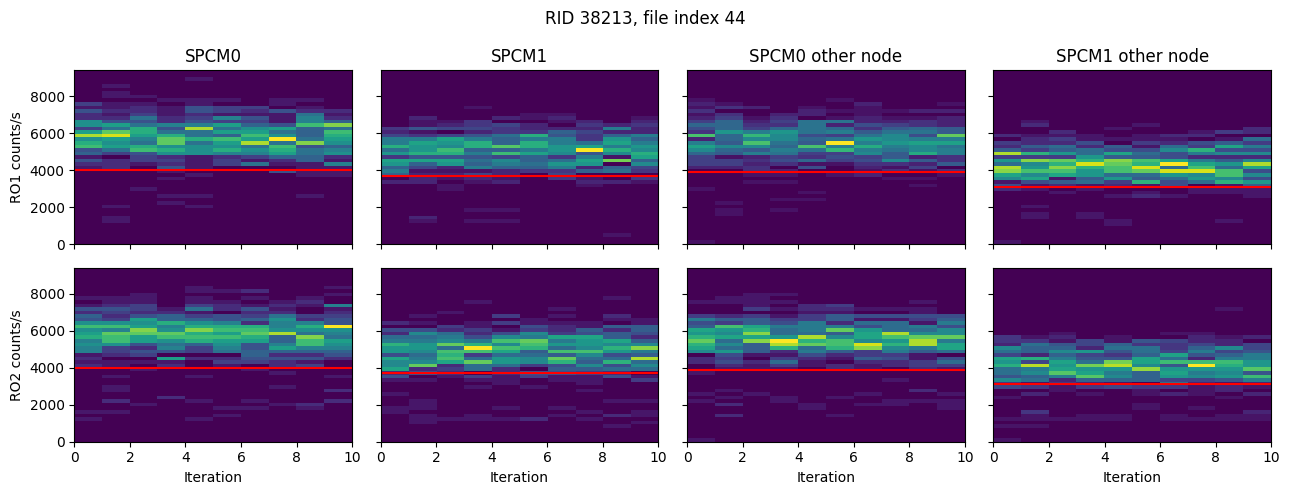

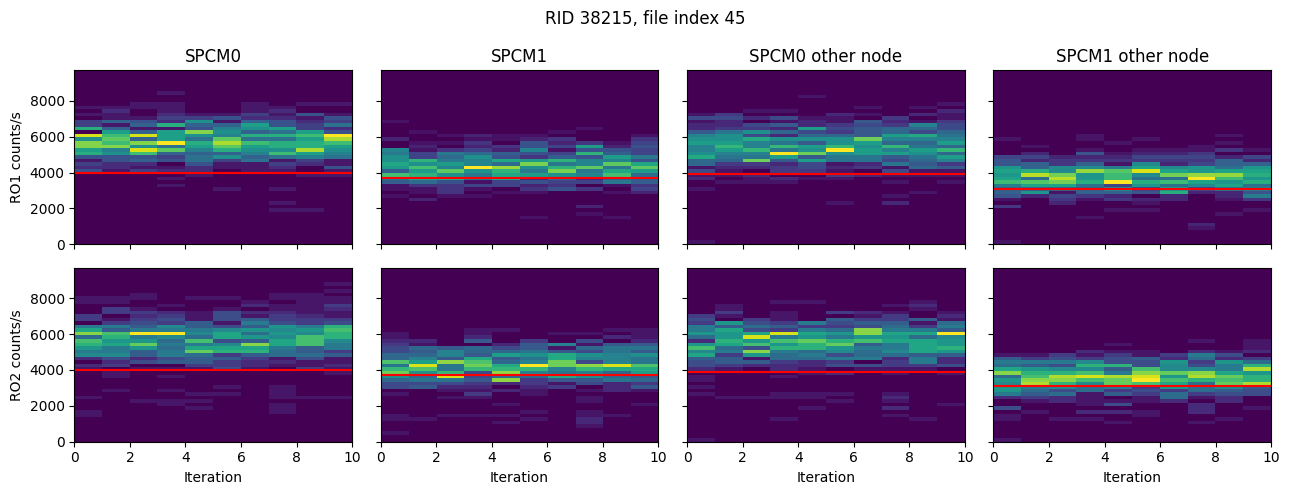

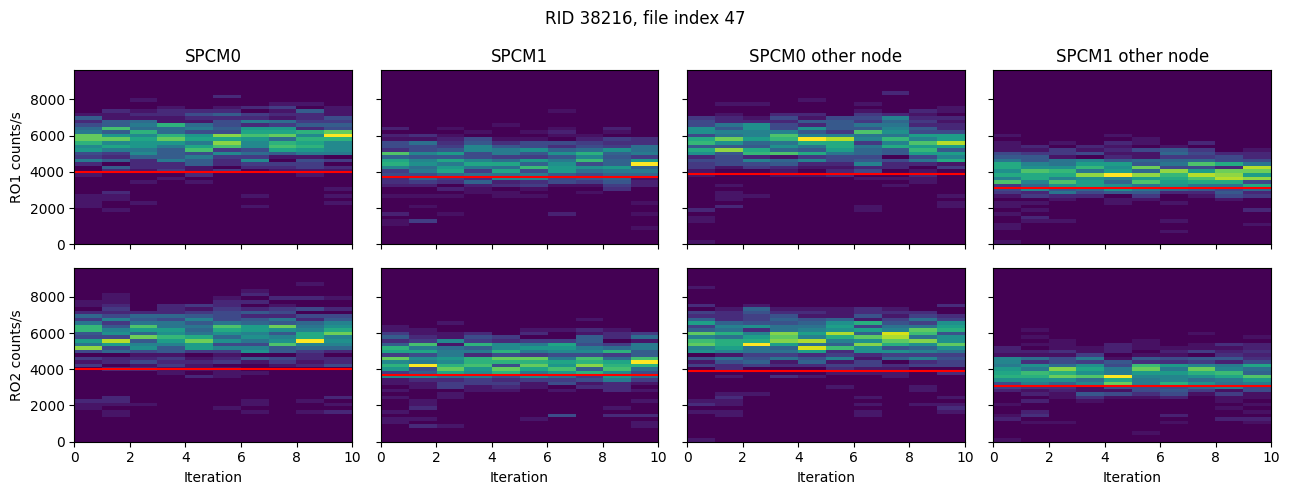

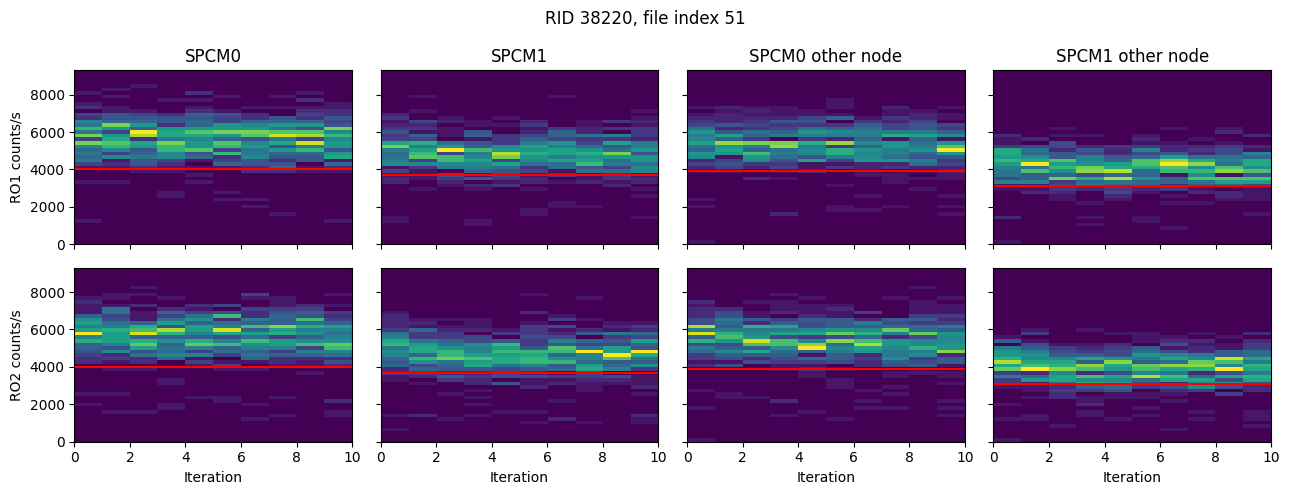

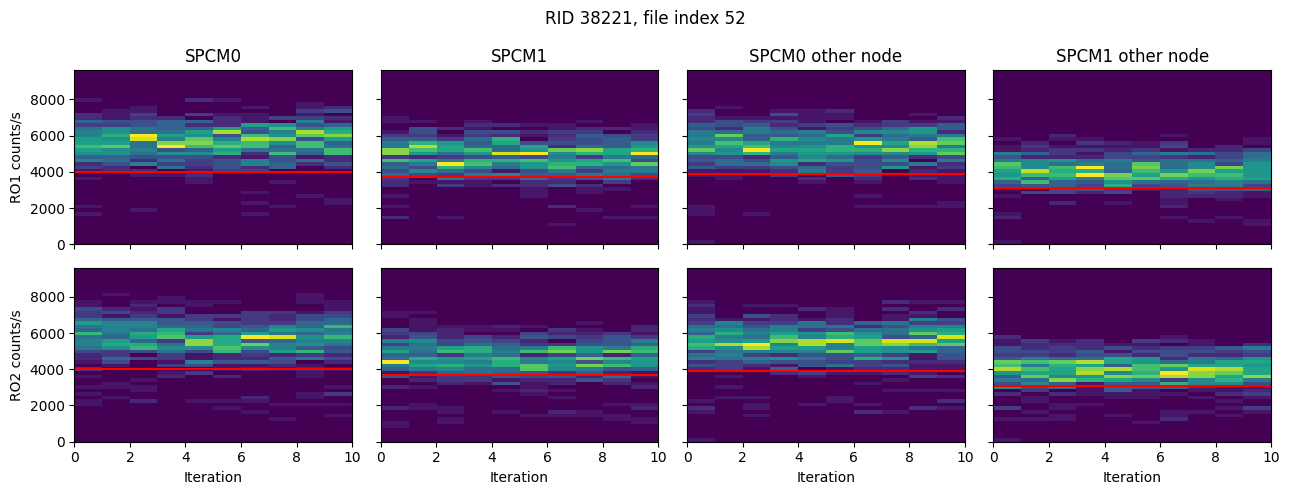

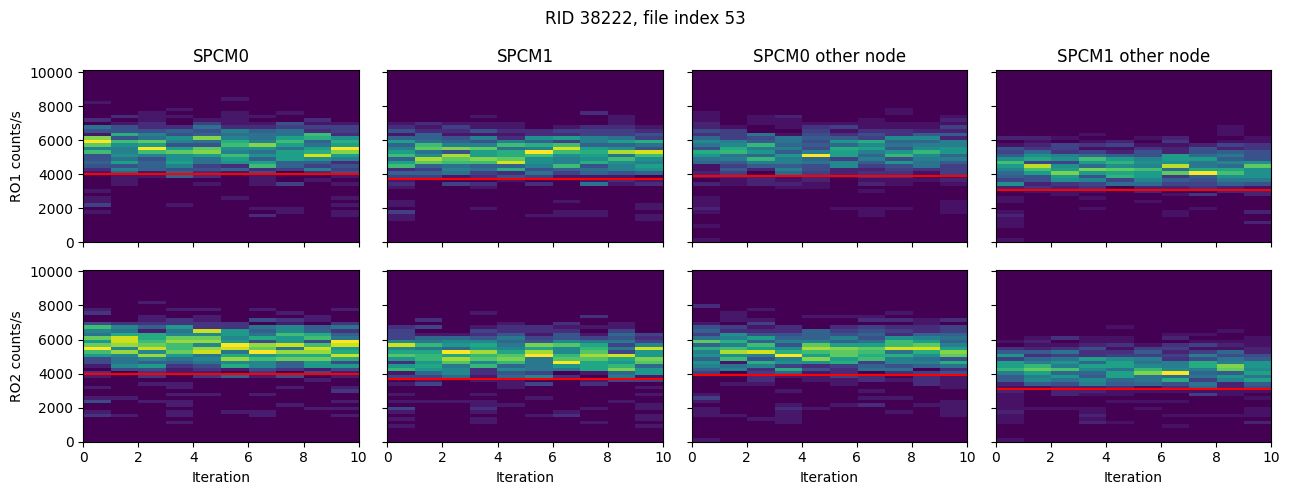

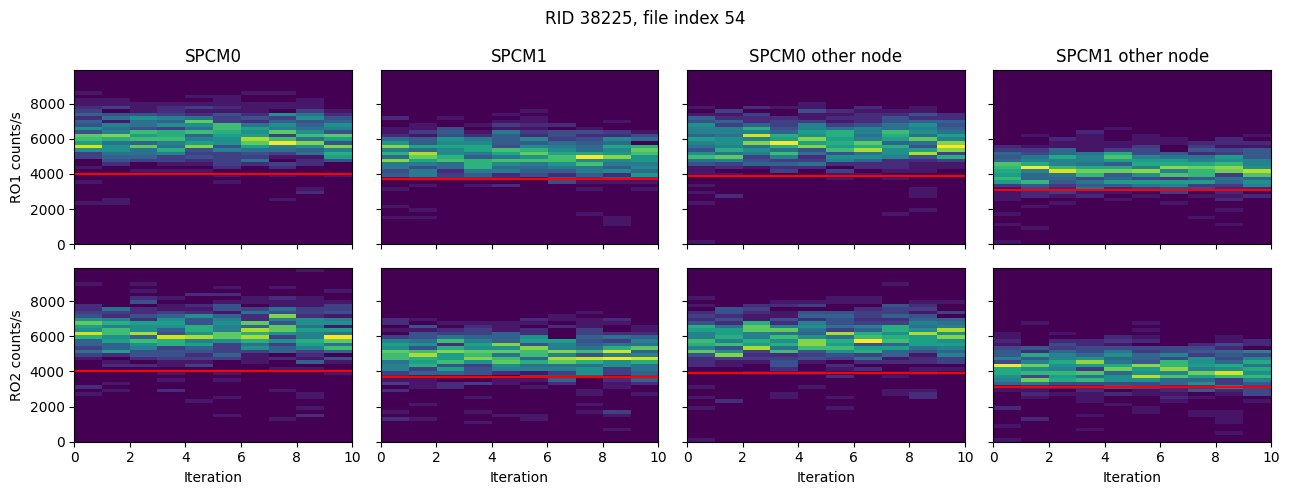

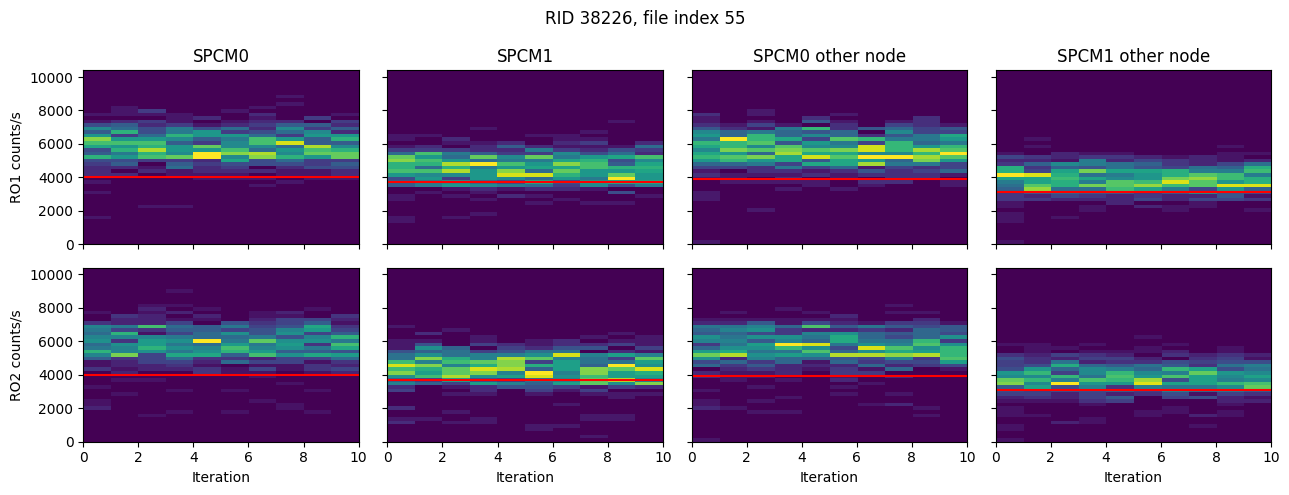

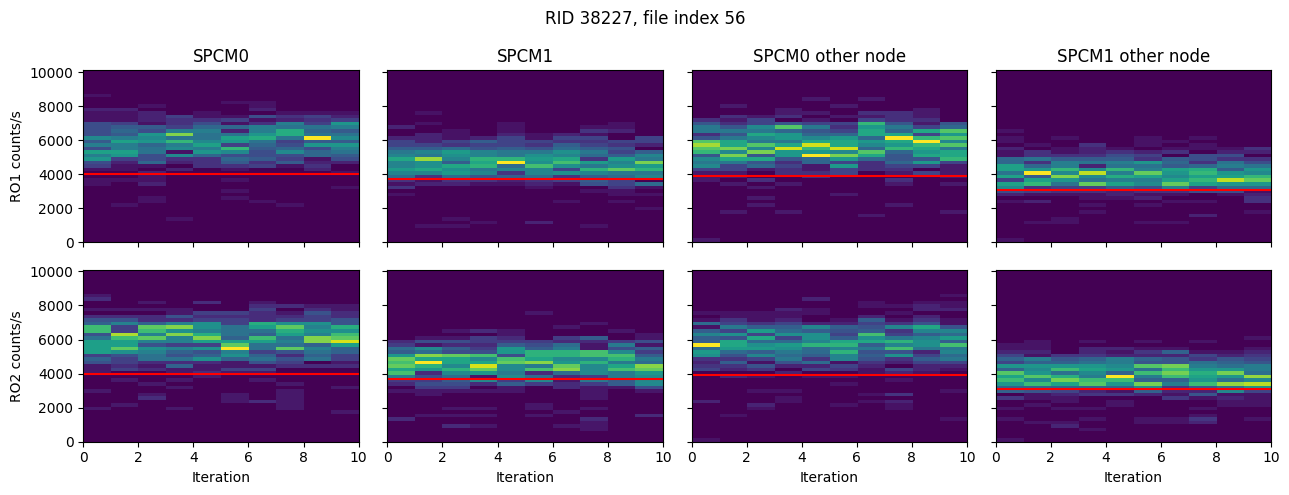

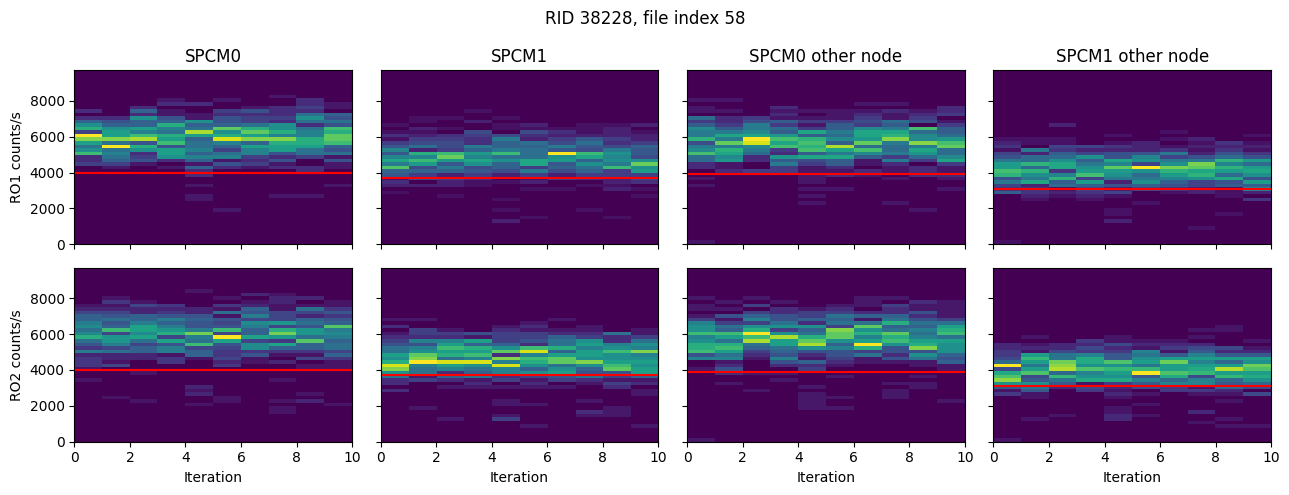

In [93]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# Individual SPCM cutoffs in counts/s
individual_SPCM_cutoffs = {
    "SPCM0_OtherNode": 3900,
    "SPCM1_OtherNode": 3100,
    "SPCM0": 4000,
    "SPCM1": 3700,
}

# # Individual SPCM cutoffs in counts/s - Node2 Analysis
# individual_SPCM_cutoffs = {
#     "SPCM0_OtherNode": 4000,
#     "SPCM1_OtherNode": 3400,
#     "SPCM0": 4100,
#     "SPCM1": 4000,
# }

n_histogram_bins = 50

SPCM_order = [
    "SPCM0",
    "SPCM1",
    "SPCM0_OtherNode",
    "SPCM1_OtherNode",
]

SPCM_titles = {
    "SPCM0": "SPCM0",
    "SPCM1": "SPCM1",
    "SPCM0_OtherNode": "SPCM0 other node",
    "SPCM1_OtherNode": "SPCM1 other node",
}


def get_rates(values, measurement_time):
    return np.asarray(values, dtype=float).ravel() / measurement_time


def get_above_cutoff(rates, cutoff):
    return rates[rates > cutoff]


def get_histograms(values, measurement_time, bins, n_measurements, iterations):
    return np.asarray([
        np.histogram(
            np.asarray(values[i * n_measurements:(i + 1) * n_measurements]) / measurement_time,
            bins=bins,
        )[0]
        for i in range(iterations)
    ])


SPCM_above_cutoff_results = []
SPCM_histogram_results = []

for f_idx, f_comment in file_indices.items():
    with h5py.File(os.path.join(results, fnames[f_idx]), "r") as f:
        rid = f["rid"][()]
        h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)

    iterations = len(scan_sequence1)

    print(f"RID: {rid}, file index: {f_idx}")
    print("experiment:", experiment_function)
    print("override:", override_ExperimentVariables)
    print("# of iterations:", iterations)

    individual_SPCM_data = {
        "SPCM0": (SPCM0_RO1, SPCM0_RO2),
        "SPCM1": (SPCM1_RO1, SPCM1_RO2),
        "SPCM0_OtherNode": (SPCM0_OtherNode_RO1, SPCM0_OtherNode_RO2),
        "SPCM1_OtherNode": (SPCM1_OtherNode_RO1, SPCM1_OtherNode_RO2),
    }

    normalized_SPCM_data = {}

    for SPCM_name, (RO1_data, RO2_data) in individual_SPCM_data.items():
        cutoff = individual_SPCM_cutoffs[SPCM_name]

        RO1_rates = get_rates(RO1_data, t_SPCM_first_shot)
        RO2_rates = get_rates(RO2_data, t_SPCM_second_shot)
        combined_rates = np.concatenate([RO1_rates, RO2_rates])

        RO1_above_cutoff = get_above_cutoff(RO1_rates, cutoff)
        RO2_above_cutoff = get_above_cutoff(RO2_rates, cutoff)
        combined_above_cutoff = get_above_cutoff(combined_rates, cutoff)

        normalized_SPCM_data[SPCM_name] = {
            "RO1": RO1_rates,
            "RO2": RO2_rates,
        }

        SPCM_above_cutoff_results.append({
            "RID": rid,
            "File index": f_idx,
            "SPCM": SPCM_name,
            "Cutoff (counts/s)": cutoff,
            "RO1 values above cutoff": len(RO1_above_cutoff),
            "RO1 mean above cutoff (counts/s)": np.mean(RO1_above_cutoff) if len(RO1_above_cutoff) else np.nan,
            "RO2 values above cutoff": len(RO2_above_cutoff),
            "RO2 mean above cutoff (counts/s)": np.mean(RO2_above_cutoff) if len(RO2_above_cutoff) else np.nan,
            "Combined values above cutoff": len(combined_above_cutoff),
            "Combined mean above cutoff (counts/s)": np.mean(combined_above_cutoff) if len(combined_above_cutoff) else np.nan,
        })

    all_histogram_sources = []

    for SPCM_name in SPCM_order:
        all_histogram_sources.append(normalized_SPCM_data[SPCM_name]["RO1"])
        all_histogram_sources.append(normalized_SPCM_data[SPCM_name]["RO2"])

    histMin = min(np.min(values) for values in all_histogram_sources)
    histMax = max(np.max(values) for values in all_histogram_sources)
    bins = np.linspace(histMin, histMax, n_histogram_bins)

    histograms = {}

    for SPCM_name, (RO1_data, RO2_data) in individual_SPCM_data.items():
        histograms[SPCM_name] = {
            "RO1": get_histograms(
                RO1_data,
                t_SPCM_first_shot,
                bins,
                n_measurements,
                iterations,
            ),
            "RO2": get_histograms(
                RO2_data,
                t_SPCM_second_shot,
                bins,
                n_measurements,
                iterations,
            ),
        }

    SPCM_histogram_results.append({
        "RID": rid,
        "File index": f_idx,
        "Comment": f_comment,
        "Iterations": iterations,
        "histMin": histMin,
        "histMax": histMax,
        "Histograms": histograms,
    })


# Create summary table
SPCM_above_cutoff_summary = pd.DataFrame(SPCM_above_cutoff_results)

combined_mean_column = "Combined mean above cutoff (counts/s)"

# Normalize the four SPCM means separately for each file
maximum_mean_for_each_file = SPCM_above_cutoff_summary.groupby(
    ["RID", "File index"]
)[combined_mean_column].transform("max")

SPCM_above_cutoff_summary["Proportional mean above cutoff"] = (
    SPCM_above_cutoff_summary[combined_mean_column]
    / maximum_mean_for_each_file
)

columns_to_round = [
    "Cutoff (counts/s)",
    "RO1 mean above cutoff (counts/s)",
    "RO2 mean above cutoff (counts/s)",
    "Combined mean above cutoff (counts/s)",
]

SPCM_above_cutoff_summary[columns_to_round] = (
    SPCM_above_cutoff_summary[columns_to_round].round(1)
)

SPCM_above_cutoff_summary["Proportional mean above cutoff"] = (
    SPCM_above_cutoff_summary["Proportional mean above cutoff"].round(4)
)

print("\nIndividual SPCM averages above cutoff:")
display(SPCM_above_cutoff_summary)


# Print proportional detector efficiencies for each file
for (rid, f_idx), file_summary in SPCM_above_cutoff_summary.groupby(
    ["RID", "File index"],
    sort=False,
):
    proportional_means = file_summary.set_index(
        "SPCM"
    )["Proportional mean above cutoff"]

    print(f"\nRID: {rid}, file index: {f_idx}")

    for SPCM_name in SPCM_order:
        eta = proportional_means.get(SPCM_name, np.nan)
        eta = round(float(eta), 2) if np.isfinite(eta) else np.nan
        print(f"eta_{SPCM_name}_channel = {eta}")

# Plot only the individual SPCM histograms
for histogram_result in SPCM_histogram_results:
    rid = histogram_result["RID"]
    f_idx = histogram_result["File index"]
    f_comment = histogram_result["Comment"]
    iterations = histogram_result["Iterations"]
    histMin = histogram_result["histMin"]
    histMax = histogram_result["histMax"]
    histograms = histogram_result["Histograms"]

    fig, axes = plt.subplots(
        nrows=2,
        ncols=4,
        figsize=(13, 5),
        sharex=True,
        sharey=True,
    )

    for column, SPCM_name in enumerate(SPCM_order):
        cutoff = individual_SPCM_cutoffs[SPCM_name]

        axes[0, column].imshow(
            histograms[SPCM_name]["RO1"].T,
            origin="lower",
            extent=[0, iterations, histMin, histMax],
            aspect="auto",
        )

        axes[1, column].imshow(
            histograms[SPCM_name]["RO2"].T,
            origin="lower",
            extent=[0, iterations, histMin, histMax],
            aspect="auto",
        )

        axes[0, column].axhline(cutoff, color="red")
        axes[1, column].axhline(cutoff, color="red")

        axes[0, column].set_title(SPCM_titles[SPCM_name])
        axes[1, column].set_xlabel("Iteration")

    axes[0, 0].set_ylabel("RO1 counts/s")
    axes[1, 0].set_ylabel("RO2 counts/s")

    title = f"RID {rid}, file index {f_idx}"

    if str(f_comment).strip():
        title += f": {f_comment}"

    fig.suptitle(title)
    fig.tight_layout()

plt.show()


### Atom Loading time - All selected files

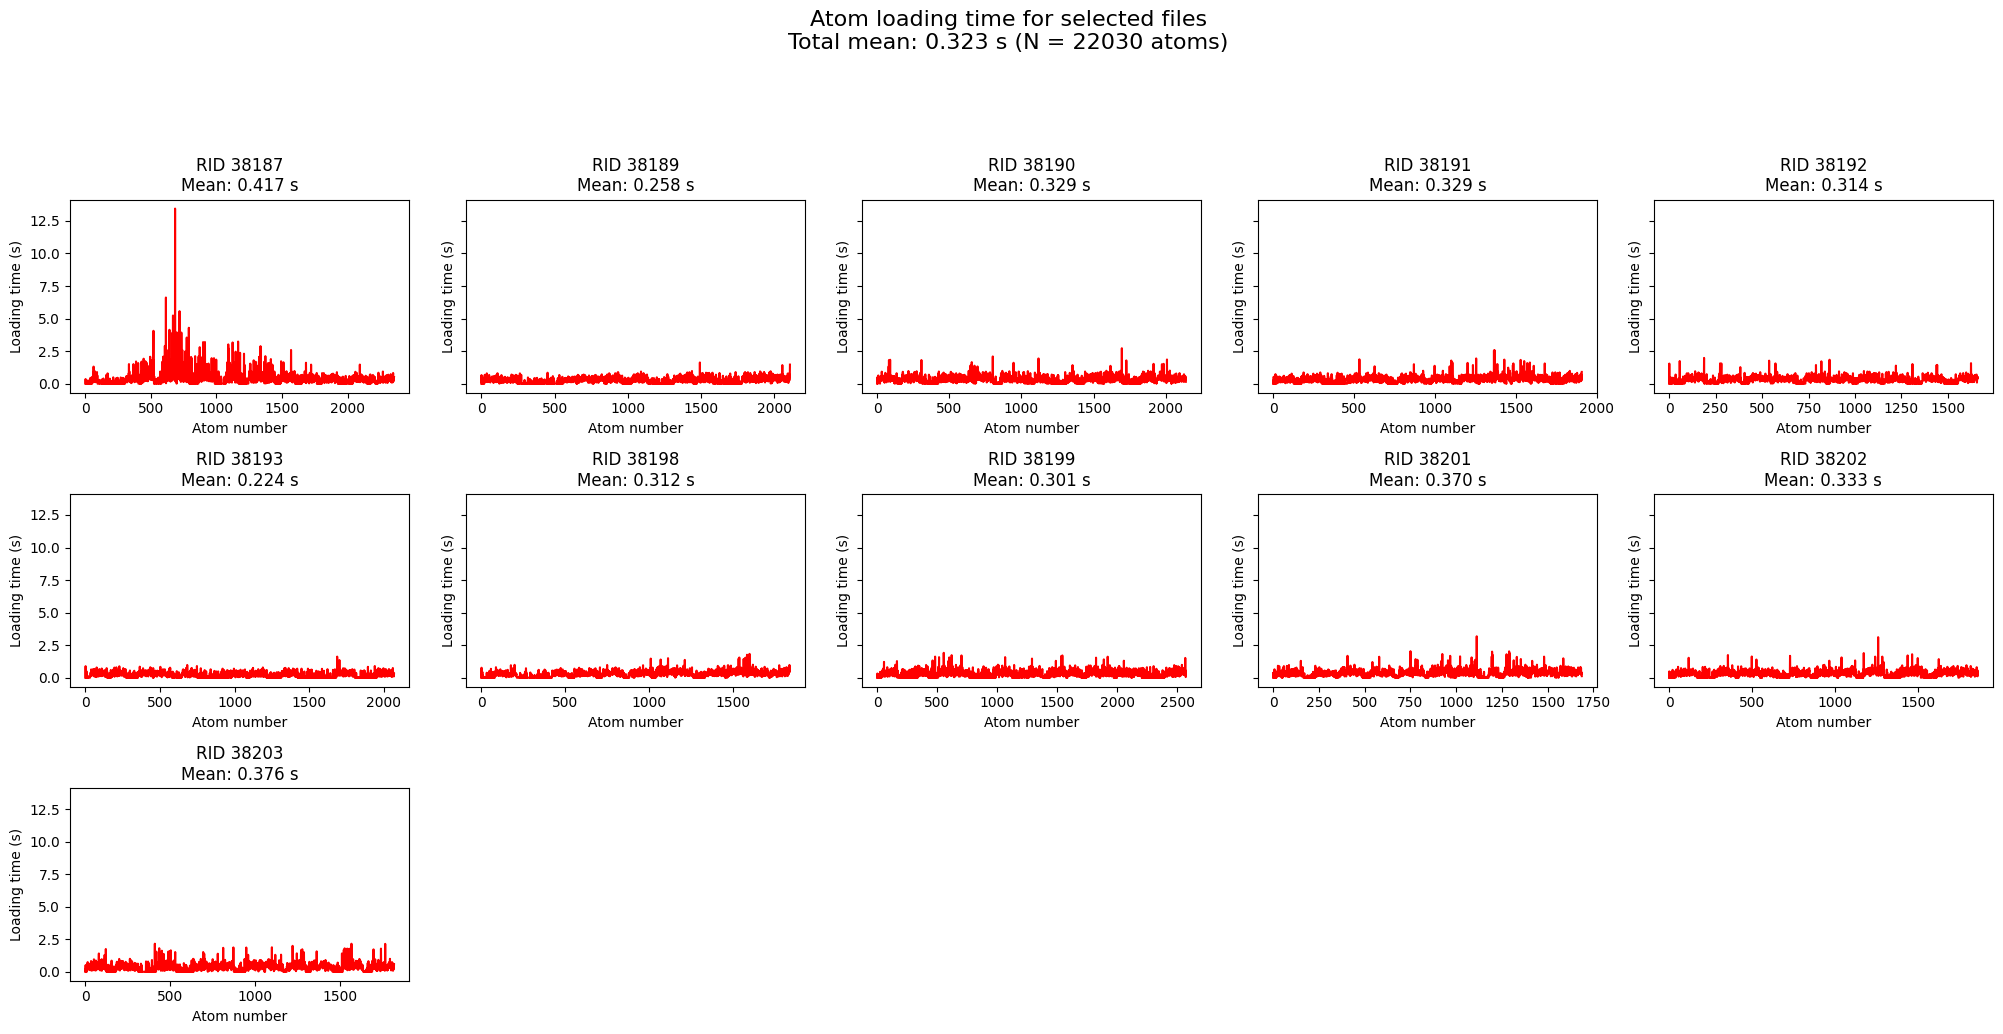

In [41]:
import os
import math
import h5py
import numpy as np
import matplotlib.pyplot as plt

n_files = len(file_indices)
n_cols = 5
n_rows = math.ceil(n_files / n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), sharey=True)
axs = np.atleast_1d(axs).ravel()

all_atom_loading_times = []

for idx, (f_idx, f_comment) in enumerate(file_indices.items()):

    # Reload file
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f["rid"][()]

    # Load datasets into a temporary dictionary
    d = {}
    h5_archive_and_datasets_to_locals(f, parent_locals=d, quiet=True)
    f.close()

    atom_loading_times = np.asarray(d["Atom_loading_time"], dtype=float).ravel()
    all_atom_loading_times.extend(atom_loading_times)

    mean_loading_time = np.mean(atom_loading_times)

    ax = axs[idx]
    ax.plot(atom_loading_times, "r-")
    ax.set_xlabel("Atom number")
    ax.set_ylabel("Loading time (s)")

    title = f"RID {rid}\nMean: {mean_loading_time:.3f} s"
    if f_comment:
        title += f"\n{f_comment}"

    ax.set_title(title)


# Hide unused subplots
for idx in range(n_files, len(axs)):
    axs[idx].set_visible(False)

# Mean over every atom-loading measurement from all selected files
all_atom_loading_times = np.asarray(all_atom_loading_times)
total_mean_loading_time = np.mean(all_atom_loading_times)

fig.suptitle(
    f"Atom loading time for selected files\n"
    f"Total mean: {total_mean_loading_time:.3f} s "
    f"(N = {len(all_atom_loading_times)} atoms)",
    fontsize=16,
)

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

### Normalized FORT monitor for all selected files

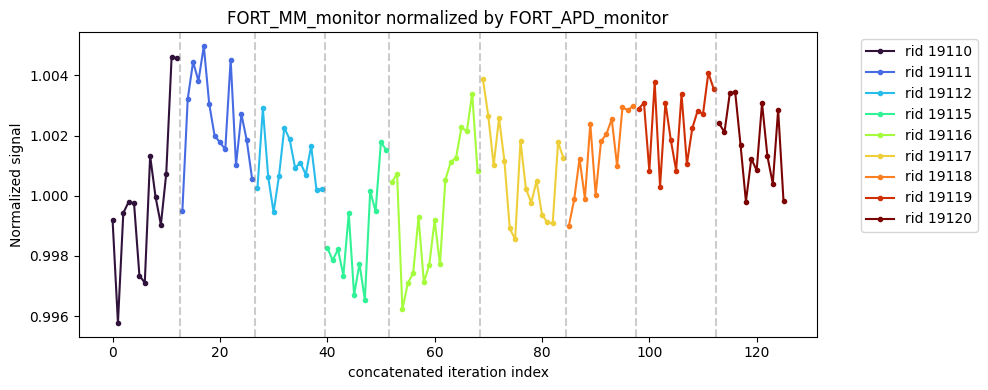

In [511]:
# --------------------------
# Plot normalized FORT monitor for all selected files
# with concatenated iteration index
# --------------------------

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py

cmap = mpl.colormaps['turbo']
fig, ax = plt.subplots(figsize=(10, 4))

x_offset = 0   # change to 1 if you want the first point to start at 1

for idx, (f_idx, f_comment) in enumerate(file_indices.items()):

    # reload file
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]

    # load datasets into a temporary dictionary
    d = {}
    h5_archive_and_datasets_to_locals(f, parent_locals=d, quiet=True)
    f.close()

    # get datasets
    FORT_MM = np.asarray(d["FORT_MM_monitor"]).ravel()
    FORT_APD = np.asarray(d["FORT_APD_monitor"]).ravel()

    best_ref = np.asarray(d["best_852_power_ref"]).squeeze()
    setpoint = np.asarray(d["set_point_FORT_APD_loading"]).squeeze()

    # normalized FORT MM signal
    norm_signal = FORT_MM / best_ref / (FORT_APD / setpoint)

    # x-axis: continue from previous experiment
    n_pts = len(norm_signal)
    x = np.arange(x_offset, x_offset + n_pts)

    color = cmap(idx / max(len(file_indices) - 1, 1))

    label = f"rid {rid}"
    if f_comment:
        label += f", {f_comment}"

    ax.plot(
        x,
        norm_signal,
        '.-',
        color=color,
        label=label
    )

    # optional vertical line showing file boundary
    if idx > 0:
        ax.axvline(
            x_offset - 0.5,
            color='gray',
            linestyle='--',
            alpha=0.4
        )

    # update offset so next file starts at last + 1
    x_offset += n_pts

ax.set_xlabel("concatenated iteration index")
ax.set_ylabel("Normalized signal")
ax.set_title("FORT_MM_monitor normalized by FORT_APD_monitor")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Magnetometer analysis - by measurement

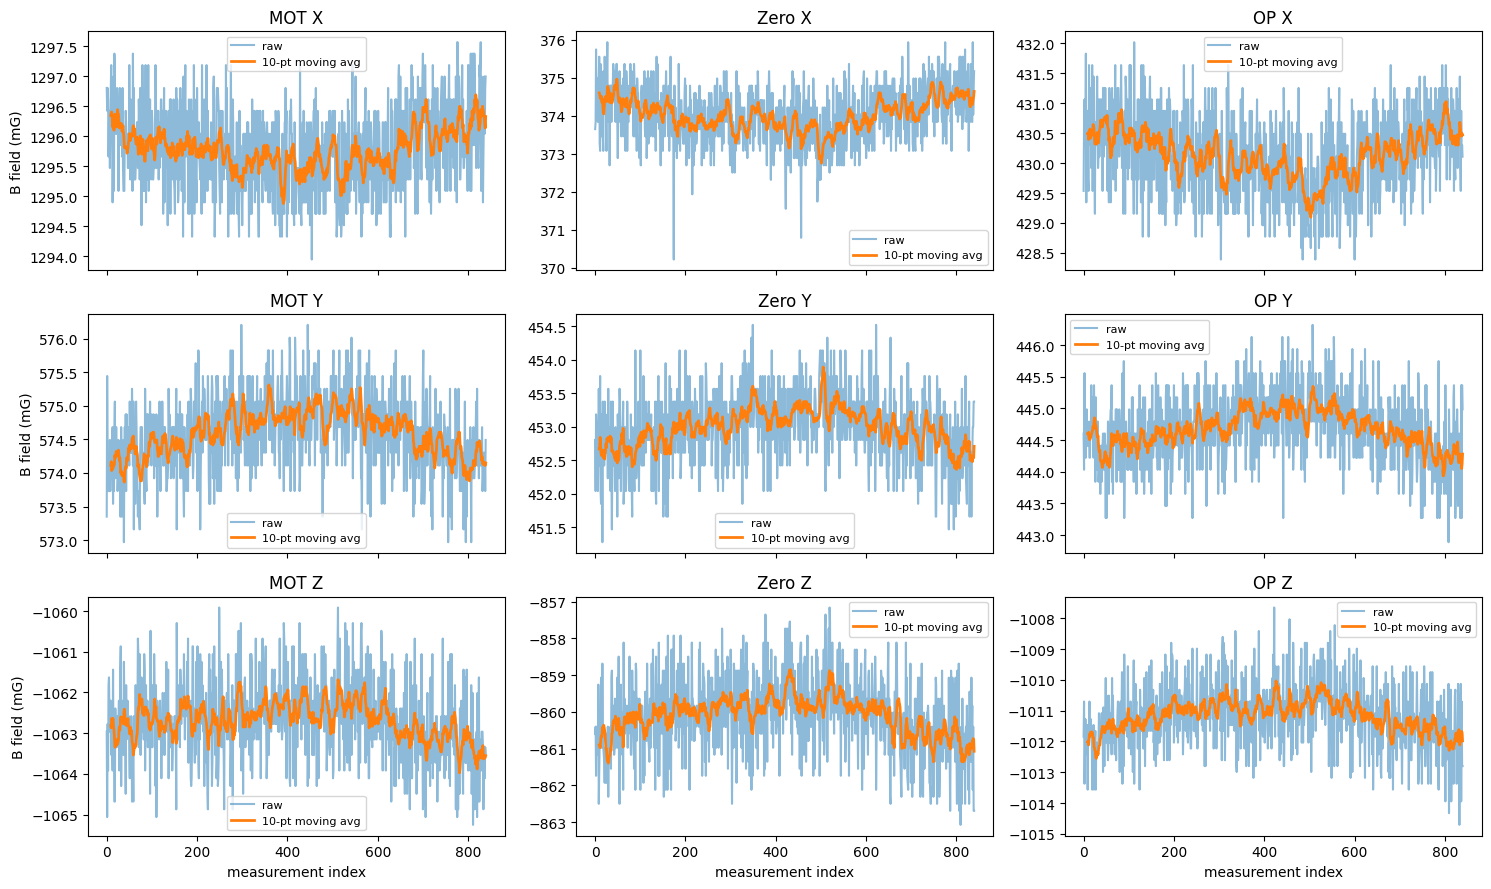

In [98]:
"""
Plot raw magnetometer data with a moving average on top.
Layout:
Row 1: MOT X, Zero X, OP X
Row 2: MOT Y, Zero Y, OP Y
Row 3: MOT Z, Zero Z, OP Z
"""

import numpy as np
import matplotlib.pyplot as plt

# Conversion factor: V -> mG
V_to_mG = 625

# Moving average window
window = 10

# Reordered raw magnetometer data converted to mG
Magnetometer_data = [
    Magnetometer_MOT_X[1:] * V_to_mG,
    Magnetometer_Zero_X[1:] * V_to_mG,
    Magnetometer_OP_X[1:] * V_to_mG,

    Magnetometer_MOT_Y[1:] * V_to_mG,
    Magnetometer_Zero_Y[1:] * V_to_mG,
    Magnetometer_OP_Y[1:] * V_to_mG,

    Magnetometer_MOT_Z[1:] * V_to_mG,
    Magnetometer_Zero_Z[1:] * V_to_mG,
    Magnetometer_OP_Z[1:] * V_to_mG
]


display(HTML(f"""<b style='font-size:18px;'> RID {rid} - {experiment_function}</b>"""))

fig, axs = plt.subplots(3, 3, figsize=(15, 9), sharex=True, sharey=False)

titles = [
    "MOT X", "Zero X", "OP X",
    "MOT Y", "Zero Y", "OP Y",
    "MOT Z", "Zero Z", "OP Z",
]

ylabels = ["B field (mG)"] + [""]*2 + ["B field (mG)"] + [""]*2 + ["B field (mG)"] + [""]*2
xlabels = [""] * 6 + ["measurement index"] * 3

for idx, raw_data in enumerate(Magnetometer_data):
    row = idx // 3
    col = idx % 3
    ax = axs[row, col]

    # raw data
    ax.plot(raw_data, '-', alpha=0.5, label='raw')

    # moving average
    if len(raw_data) >= window:
        smooth_data = np.convolve(raw_data, np.ones(window) / window, mode='valid')
        x_smooth = np.arange(window - 1, len(raw_data))
        ax.plot(x_smooth, smooth_data, linewidth=2, label=f'{window}-pt moving avg')

    ax.set_title(titles[idx])

    if ylabels[idx]:
        ax.set_ylabel(ylabels[idx])
    if xlabels[idx]:
        ax.set_xlabel(xlabels[idx])

    ax.legend(fontsize=8)

# ax.set_title(f"{locals().get('experiment_function', '')} {rid}")

plt.tight_layout()
plt.show()

# Magnetometer_MOT_X

### measure_Magnetometer_X_Y_Z

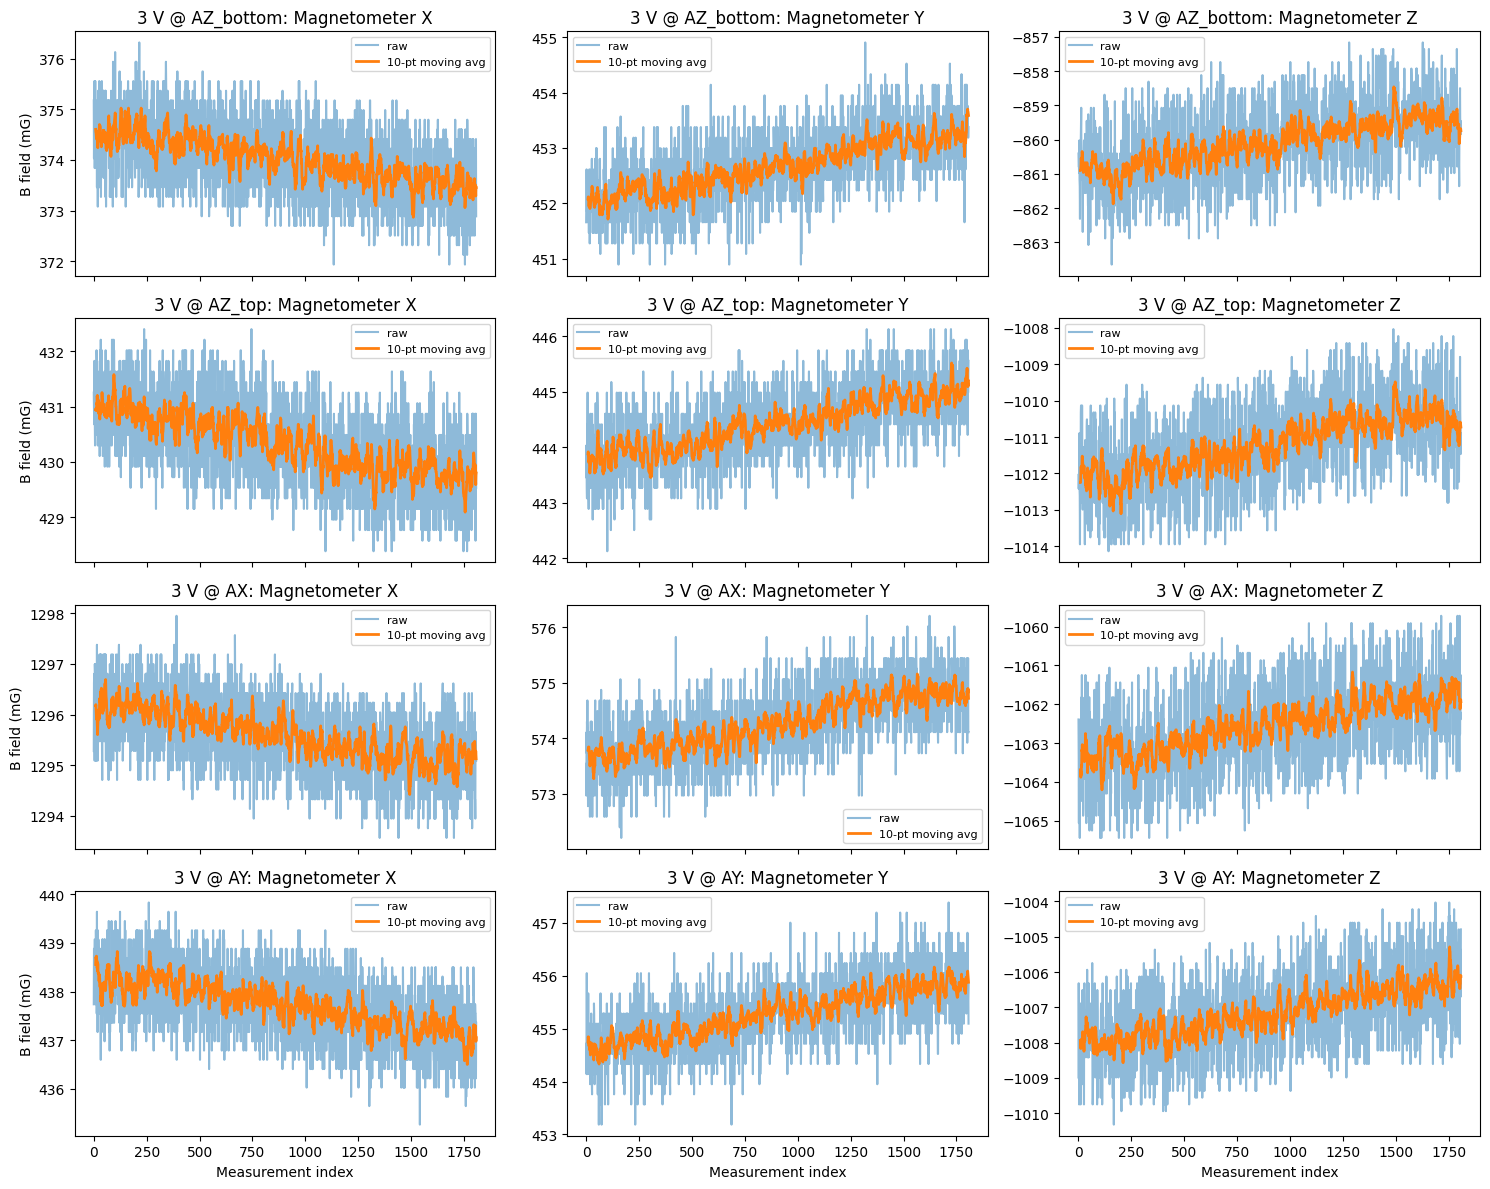

In [119]:
"""
Plot the magnetic field produced by each coil channel separately.

Layout:
Row 1: 3 V @ AZ_bottom → Magnetometer X, Y, Z
Row 2: 3 V @ AZ_top    → Magnetometer X, Y, Z
Row 3: 3 V @ AX        → Magnetometer X, Y, Z
Row 4: 3 V @ AY        → Magnetometer X, Y, Z
"""

import numpy as np
import matplotlib.pyplot as plt

V_to_mG = 625
window = 10

# Dataset mapping:
# Zero -> AZ_bottom
# OP   -> AZ_top
# MOT  -> AX
# TEST -> AY
Magnetometer_data = [
    [Magnetometer_Zero_X[1:] * V_to_mG, Magnetometer_Zero_Y[1:] * V_to_mG, Magnetometer_Zero_Z[1:] * V_to_mG],
    [Magnetometer_OP_X[1:] * V_to_mG, Magnetometer_OP_Y[1:] * V_to_mG, Magnetometer_OP_Z[1:] * V_to_mG],
    [Magnetometer_MOT_X[1:] * V_to_mG, Magnetometer_MOT_Y[1:] * V_to_mG, Magnetometer_MOT_Z[1:] * V_to_mG],
    [Magnetometer_TEST_X[1:] * V_to_mG, Magnetometer_TEST_Y[1:] * V_to_mG, Magnetometer_TEST_Z[1:] * V_to_mG],
]

coil_names = ["3 V @ AZ_bottom", "3 V @ AZ_top", "3 V @ AX", "3 V @ AY"]
magnetometer_axes = ["X", "Y", "Z"]

display(HTML(f"<b style='font-size:18px;'>RID {rid} - {experiment_function}</b>"))

fig, axs = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=False)

for row in range(4):
    for col in range(3):
        ax = axs[row, col]
        raw_data = np.asarray(Magnetometer_data[row][col])

        ax.plot(raw_data, "-", alpha=0.5, label="raw")

        if len(raw_data) >= window:
            smooth_data = np.convolve(raw_data, np.ones(window) / window, mode="valid")
            x_smooth = np.arange(window - 1, len(raw_data))
            ax.plot(x_smooth, smooth_data, linewidth=2, label=f"{window}-pt moving avg")

        ax.set_title(f"{coil_names[row]}: Magnetometer {magnetometer_axes[col]}")

        if col == 0:
            ax.set_ylabel("B field (mG)")

        if row == 3:
            ax.set_xlabel("Measurement index")

        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Joint Probabilities and Fidelity with AllSPCMs - In 3x2 plot all selected files in table

#### Helper functions

In [3]:
# ============================================================
# Global fidelity functions
# ============================================================

def sqrt_prod_sigma2(b, db, c, dc):
    if b <= 0 or c <= 0:
        return 0.0

    dy_db = 0.5*np.sqrt(c/b)
    dy_dc = 0.5*np.sqrt(b/c)

    return (dy_db*db)**2 + (dy_dc*dc)**2


def fidelity_lower_bound(values_Z, errors_Z, values_X=None, errors_X=None):
    """
    Probability order:
        values_Z = [P_SPCM0_Z1, P_SPCM1_Z1, P_SPCM0_Zm1, P_SPCM1_Zm1]
        values_X = [P_SPCM0_X1, P_SPCM1_X1, P_SPCM0_Xm1, P_SPCM1_Xm1]

    If values_X and errors_X are not provided, the Z probability
    values are also used for the X-basis terms.
    """

    values_X = values_Z if values_X is None else values_X
    errors_X = errors_Z if errors_X is None else errors_X

    a, b, c, d = map(float, values_Z)
    da, db, dc, dd = map(float, errors_Z)

    e, f, g, h = map(float, values_X)
    de, df, dg, dh = map(float, errors_X)

    sqrt_bc = np.sqrt(max(b*c, 0.0))
    F_low = 0.5*(a + d - 2.0*sqrt_bc + e + h - f - g)

    var_sqrt = sqrt_prod_sigma2(b, db, c, dc)
    var_F = 0.25*(da**2 + dd**2 + 4.0*var_sqrt + de**2 + dh**2 + df**2 + dg**2)
    F_low_err = np.sqrt(max(var_F, 0.0))

    return F_low, F_low_err
    

# ========================================================
# Analysis helper functions
# ========================================================

def bin_counts_for_state(angles, spcm0_combined, spcm1_combined, atom_mask):
    x, c0, c1 = [], [], []

    for angle in unique_angles:
        selected = (angles == angle) & atom_mask
        x.append(angle)
        c0.append(int(np.sum(spcm0_combined[selected])))
        c1.append(int(np.sum(spcm1_combined[selected])))

    return np.asarray(x), np.asarray(c0, dtype=int), np.asarray(c1, dtype=int)


def corrected_joint_prob_and_err(
    counts_SPCM0_Z1,
    counts_SPCM1_Z1,
    counts_SPCM0_Zm1,
    counts_SPCM1_Zm1,
    group_mask,
):
    counts = np.vstack([
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
    ]).astype(float)

    weights = np.array([
        w_SPCM0,
        w_SPCM1,
        w_SPCM0_OtherNode,
        w_SPCM1_OtherNode,
    ], dtype=float)[:, None]

    mask = np.asarray(group_mask, dtype=bool)[:, None]

    weighted_counts = weights*counts
    denominator = np.sum(weighted_counts, axis=0)
    numerator = np.sum(weighted_counts*mask, axis=0)

    probability = np.full_like(denominator, np.nan, dtype=float)
    np.divide(numerator, denominator, out=probability, where=denominator > 0)

    gradient = np.zeros_like(counts, dtype=float)
    valid = denominator > 0

    gradient[:, valid] = (
        weights*(mask.astype(float) - probability[None, valid])
        / denominator[None, valid]
    )

    variance = np.sum(gradient**2*counts, axis=0)
    probability_error = np.sqrt(np.maximum(variance, 0.0))

    return probability, probability_error


def sinusoid_varf(theta_deg, amplitude, frequency, phase, offset):
    return amplitude*np.cos(np.deg2rad(frequency*theta_deg) + phase) + offset


def fit_sinusoid_prob(x, probability, probability_error, f0=4.0):
    x = np.asarray(x, dtype=float)
    probability = np.asarray(probability, dtype=float)
    sigma = np.clip(np.asarray(probability_error, dtype=float), 1e-6, None)

    if np.isfinite(probability).all():
        amplitude_guess = (np.nanmax(probability) - np.nanmin(probability))/2.0
        offset_guess = np.nanmean(probability)
    else:
        amplitude_guess = 0.2
        offset_guess = 0.5

    bounds = (
        [-1.0, 3.5, -2*np.pi, 0.0],
        [1.0, 4.5, 2*np.pi, 1.0],
    )

    initial_parameters = [
        np.clip(amplitude_guess, 0.0, 0.9),
        f0,
        0.0,
        np.clip(offset_guess, 0.0, 1.0),
    ]

    popt, pcov = curve_fit(
        sinusoid_varf,
        x,
        probability,
        p0=initial_parameters,
        sigma=sigma,
        absolute_sigma=True,
        bounds=bounds,
        maxfev=20000,
    )

    perr = np.sqrt(np.diag(pcov))

    amplitude, frequency, phase, offset = popt
    amplitude_error, offset_error = perr[0], perr[3]
    covariance_amplitude_offset = pcov[0, 3]

    if offset <= 0:
        visibility = np.nan
        visibility_error = np.nan
    else:
        visibility = np.abs(amplitude)/offset
        sign_amplitude = 1.0 if amplitude >= 0 else -1.0
        dV_dA = sign_amplitude/offset
        dV_dOffset = -np.abs(amplitude)/offset**2

        visibility_variance = (
            dV_dA**2*amplitude_error**2
            + dV_dOffset**2*offset_error**2
            + 2*dV_dA*dV_dOffset*covariance_amplitude_offset
        )

        visibility_error = np.sqrt(max(visibility_variance, 0.0))

    x_fit = np.linspace(x.min(), x.max(), 400)
    y_fit = sinusoid_varf(x_fit, *popt)

    return popt, perr, (x_fit, y_fit), (visibility, visibility_error), pcov


def fit_eval(theta_deg, popt):
    return np.clip(
        sinusoid_varf(np.asarray(theta_deg, dtype=float), *popt),
        0.0,
        1.0,
    )


def prob_sigma_at_theta(theta_deg, popt, pcov):
    amplitude, frequency, phase, offset = popt
    argument = np.deg2rad(frequency*theta_deg) + phase

    jacobian = np.array([
        np.cos(argument),
        -amplitude*np.sin(argument)*np.pi/180.0*theta_deg,
        -amplitude*np.sin(argument),
        1.0,
    ])

    return np.sqrt(max(float(jacobian@pcov@jacobian), 0.0))


# ========================================================
# Plotting helper functions
# ========================================================

def probability_ylim(*arrays):
    finite_values = []

    for array in arrays:
        array = np.asarray(array, dtype=float).ravel()
        finite_values.extend(array[np.isfinite(array)])

    if len(finite_values) == 0:
        return 1.0

    y_max = np.max(finite_values)

    return max(0.1, min(1.0, np.ceil((y_max - 1e-12)*10)/10))


def count_ylim(*arrays):
    finite_values = []

    for array in arrays:
        array = np.asarray(array, dtype=float).ravel()
        finite_values.extend(array[np.isfinite(array)])

    if len(finite_values) == 0:
        return 1.0

    y_max = np.max(finite_values)

    if y_max <= 10:
        step = 1
    elif y_max <= 100:
        step = 10
    elif y_max <= 1000:
        step = 100
    else:
        step = 10**np.floor(np.log10(y_max))

    return np.ceil((y_max - 1e-12)/step)*step


def plot_probability_subplot(
    ax,
    x,
    y0,
    err0,
    y1,
    err1,
    fit0,
    fit1,
    title,
    labels,
    colors,
):
    ax.errorbar(
        x,
        y0,
        yerr=err0,
        fmt="o",
        markersize=5,
        capsize=3,
        color=colors[0],
        label=labels[0],
    )

    ax.errorbar(
        x,
        y1,
        yerr=err1,
        fmt="o",
        markersize=5,
        capsize=3,
        color=colors[1],
        label=labels[1],
    )

    ax.plot(fit0[0], fit0[1], "-", linewidth=2, color=colors[0])
    ax.plot(fit1[0], fit1[1], "-", linewidth=2, color=colors[1])

    ax.set_xlabel("780 HWP angle (degrees)")
    ax.set_ylabel("Joint probability")
    ax.set_title(title)
    ax.set_ylim(
        0,
        probability_ylim(y0 + err0, y1 + err1, fit0[1], fit1[1]),
    )
    ax.legend(fontsize=9)
    ax.grid(False)


def plot_bar_subplot(ax, labels, values, errors, title):
    x_positions = np.arange(len(labels))
    values = np.asarray(values, dtype=float)
    errors = np.asarray(errors, dtype=float)

    colors = [
        (*color1[:3], 1.0),
        (*color2[:3], 1.0),
        (*color1[:3], 0.6),
        (*color2[:3], 0.6),
    ]

    bars = ax.bar(
        x_positions,
        values,
        yerr=errors,
        capsize=5,
        color=colors,
        edgecolor="none",
        linewidth=0,
    )

    y_max = probability_ylim(values + errors)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("Probability")
    ax.set_title(title)
    ax.set_ylim(0, y_max)
    ax.grid(False)

    for bar, value, error in zip(bars, values, errors):
        text_y = min(value + error + 0.015, y_max - 0.02)

        ax.text(
            bar.get_x() + bar.get_width()/2,
            text_y,
            f"{value:.3f} ± {error:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

#### Summary only

In [121]:
import os
import h5py
import numpy as np
import pandas as pd
from IPython.display import display


# ============================================================
# Analyze all selected files
# ============================================================

summary_rows = []
best_fitted = None
best_data_selected = None

for idx, (f_idx, f_comment) in enumerate(file_indices.items()):
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f["rid"][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    f.close()

    # ========================================================
    # Identify Z- or X-parity experiment
    # ========================================================

    t_MW_RF_pulse_value = float(np.asarray(t_MW_RF_pulse).reshape(-1)[0])
    parity_basis = "Z parity" if np.isclose(t_MW_RF_pulse_value, 0.0) else "X parity"

    # ========================================================
    # Prepare data
    # ========================================================

    angles = angle_780_HWP

    spcm0 = SPCM0_SinglePhoton[1:] > 0
    spcm1 = SPCM1_SinglePhoton[1:] > 0
    spcm0_OtherNode = SPCM0_OtherNode_SinglePhoton[1:] > 0
    spcm1_OtherNode = SPCM1_OtherNode_SinglePhoton[1:] > 0

    # Alternative detector assignment:
    # spcm0 = spcm0_OtherNode
    # spcm1 = spcm1_OtherNode
    # spcm0_OtherNode = SPCM0_SinglePhoton[1:] > 0
    # spcm1_OtherNode = SPCM1_SinglePhoton[1:] > 0

    # Alternative datasets:
    # spcm0 = SPCM0_SinglePhoton_parity[1:] > 0
    # spcm1 = SPCM1_SinglePhoton_parity[1:] > 0
    # spcm0_OtherNode = SPCM0_OtherNode_SinglePhoton_parity[1:] > 0
    # spcm1_OtherNode = SPCM1_OtherNode_SinglePhoton_parity[1:] > 0

    spcm0_combined = spcm0.astype(np.int8) + spcm0_OtherNode.astype(np.int8)
    spcm1_combined = spcm1.astype(np.int8) + spcm1_OtherNode.astype(np.int8)

    atom_signal = AllSPCMs_parity_RO[1:] / t_SPCM_second_shot
    atom_Z1_mask = atom_signal <= single_atom_threshold
    atom_Zm1_mask = ~atom_Z1_mask

    event_lengths = {
        "angles": len(angles),
        "spcm0": len(spcm0),
        "spcm1": len(spcm1),
        "spcm0_OtherNode": len(spcm0_OtherNode),
        "spcm1_OtherNode": len(spcm1_OtherNode),
        "atom_signal": len(atom_signal),
    }

    if len(set(event_lengths.values())) != 1:
        raise ValueError(f"Per-event array length mismatch: {event_lengths}")

    unique_angles = np.unique(angles)

    # ========================================================
    # Channel-efficiency correction
    # ========================================================

    # eta_SPCM0_channel = 1.0
    # eta_SPCM1_channel = 0.8
    # eta_SPCM0_OtherNode_channel = 1.0
    # eta_SPCM1_OtherNode_channel = 0.96

    # eta_SPCM0_channel = 0.98
    # eta_SPCM1_channel = 0.84
    # eta_SPCM0_OtherNode_channel = 1.0
    # eta_SPCM1_OtherNode_channel = 0.97
    
    # eta_SPCM0_channel = 1.0
    # eta_SPCM1_channel = 1.0
    # eta_SPCM0_OtherNode_channel = 1.0
    # eta_SPCM1_OtherNode_channel = 1.0

    w_SPCM0 = 1.0/float(eta_SPCM0_channel)
    w_SPCM1 = 1.0/float(eta_SPCM1_channel)
    w_SPCM0_OtherNode = 1.0/float(eta_SPCM0_OtherNode_channel)
    w_SPCM1_OtherNode = 1.0/float(eta_SPCM1_OtherNode_channel)

    # ========================================================
    # Bin counts
    # ========================================================

    angles_Z1, counts_SPCM0_Z1, counts_SPCM1_Z1 = bin_counts_for_state(
        angles,
        spcm0_combined,
        spcm1_combined,
        atom_Z1_mask,
    )

    angles_Zm1, counts_SPCM0_Zm1, counts_SPCM1_Zm1 = bin_counts_for_state(
        angles,
        spcm0_combined,
        spcm1_combined,
        atom_Zm1_mask,
    )

    total_counts = (
        counts_SPCM0_Z1
        + counts_SPCM1_Z1
        + counts_SPCM0_Zm1
        + counts_SPCM1_Zm1
    )

    # ========================================================
    # Four joint probabilities
    # ========================================================

    prob_SPCM0_Z1, prob_err_SPCM0_Z1 = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [True, False, False, False],
    )

    prob_SPCM1_Z1, prob_err_SPCM1_Z1 = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [False, True, False, False],
    )

    prob_SPCM0_Zm1, prob_err_SPCM0_Zm1 = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [False, False, True, False],
    )

    prob_SPCM1_Zm1, prob_err_SPCM1_Zm1 = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [False, False, False, True],
    )

    # ========================================================
    # Fit four joint probabilities
    # ========================================================

    popt0_Z1, _, (angles_fit_SPCM0_Z1, y_fit_SPCM0_Z1), (
        vis_SPCM0_Z1,
        vis_err_SPCM0_Z1,
    ), pcov0_Z1 = fit_sinusoid_prob(
        angles_Z1,
        prob_SPCM0_Z1,
        prob_err_SPCM0_Z1,
    )

    popt1_Z1, _, (angles_fit_SPCM1_Z1, y_fit_SPCM1_Z1), (
        vis_SPCM1_Z1,
        vis_err_SPCM1_Z1,
    ), pcov1_Z1 = fit_sinusoid_prob(
        angles_Z1,
        prob_SPCM1_Z1,
        prob_err_SPCM1_Z1,
    )

    popt0_Zm1, _, (angles_fit_SPCM0_Zm1, y_fit_SPCM0_Zm1), (
        vis_SPCM0_Zm1,
        vis_err_SPCM0_Zm1,
    ), pcov0_Zm1 = fit_sinusoid_prob(
        angles_Zm1,
        prob_SPCM0_Zm1,
        prob_err_SPCM0_Zm1,
    )

    popt1_Zm1, _, (angles_fit_SPCM1_Zm1, y_fit_SPCM1_Zm1), (
        vis_SPCM1_Zm1,
        vis_err_SPCM1_Zm1,
    ), pcov1_Zm1 = fit_sinusoid_prob(
        angles_Zm1,
        prob_SPCM1_Zm1,
        prob_err_SPCM1_Zm1,
    )

    # ========================================================
    # Even and odd parity
    # ========================================================

    prob_sum_A, err_sum_A = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [True, False, False, True],
    )

    prob_sum_B, err_sum_B = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [False, True, True, False],
    )

    popt_sumA, _, (xfit_sumA, yfit_sumA), (
        vis_sumA,
        viserr_sumA,
    ), _ = fit_sinusoid_prob(
        unique_angles,
        prob_sum_A,
        err_sum_A,
    )

    popt_sumB, _, (xfit_sumB, yfit_sumB), (
        vis_sumB,
        viserr_sumB,
    ), _ = fit_sinusoid_prob(
        unique_angles,
        prob_sum_B,
        err_sum_B,
    )

    # ========================================================
    # Best angle from fitted curves
    # ========================================================

    theta_grid = np.linspace(
        float(unique_angles.min()),
        float(unique_angles.max()),
        5001,
    )

    y0_Z1_grid = fit_eval(theta_grid, popt0_Z1)
    y1_Z1_grid = fit_eval(theta_grid, popt1_Z1)
    y0_Zm1_grid = fit_eval(theta_grid, popt0_Zm1)
    y1_Zm1_grid = fit_eval(theta_grid, popt1_Zm1)

    separation_grid = (
        np.abs(y0_Z1_grid - y1_Z1_grid)
        + np.abs(y0_Zm1_grid - y1_Zm1_grid)
    )

    i_star = int(np.argmax(separation_grid))
    theta_star = float(theta_grid[i_star])

    P_SPCM0_mFplus = float(fit_eval(theta_star, popt0_Z1))
    P_SPCM1_mFplus = float(fit_eval(theta_star, popt1_Z1))
    P_SPCM0_mFminus = float(fit_eval(theta_star, popt0_Zm1))
    P_SPCM1_mFminus = float(fit_eval(theta_star, popt1_Zm1))

    # ========================================================
    # Fitted probabilities and uncertainties
    # ========================================================

    values = [
        P_SPCM0_mFplus,
        P_SPCM1_mFplus,
        P_SPCM0_mFminus,
        P_SPCM1_mFminus,
    ]

    errors = [
        prob_sigma_at_theta(theta_star, popt0_Z1, pcov0_Z1),
        prob_sigma_at_theta(theta_star, popt1_Z1, pcov1_Z1),
        prob_sigma_at_theta(theta_star, popt0_Zm1, pcov0_Zm1),
        prob_sigma_at_theta(theta_star, popt1_Zm1, pcov1_Zm1),
    ]

    # ========================================================
    # Best angle from measured data
    # ========================================================

    p11 = prob_SPCM0_Z1
    p22 = prob_SPCM1_Z1
    p33 = prob_SPCM0_Zm1
    p44 = prob_SPCM1_Zm1

    separation_data_1 = p11 + p44 - 2*np.sqrt(p22*p33)
    separation_data_2 = p22 + p33 - 2*np.sqrt(p11*p44)

    if np.nanmax(separation_data_1) > np.nanmax(separation_data_2):
        separation_data = separation_data_1
    else:
        separation_data = separation_data_2

    idx_data_star = int(np.nanargmax(separation_data))
    theta_data_star = float(unique_angles[idx_data_star])

    values_data = [
        float(prob_SPCM0_Z1[idx_data_star]),
        float(prob_SPCM1_Z1[idx_data_star]),
        float(prob_SPCM0_Zm1[idx_data_star]),
        float(prob_SPCM1_Zm1[idx_data_star]),
    ]

    errors_data = [
        float(prob_err_SPCM0_Z1[idx_data_star]),
        float(prob_err_SPCM1_Z1[idx_data_star]),
        float(prob_err_SPCM0_Zm1[idx_data_star]),
        float(prob_err_SPCM1_Zm1[idx_data_star]),
    ]

    # ========================================================
    # Fidelity at fitted and data-selected HWP angles
    # ========================================================

    # The same probabilities are currently used for the Z and X terms.
    F_fit, F_fit_err = fidelity_lower_bound(values, errors)
    F_data, F_data_err = fidelity_lower_bound(values_data, errors_data)

    result_info = {
        "Parity": parity_basis,
        "RID": int(rid),
        "File index": int(f_idx),
        "Comment": str(f_comment),
        "QWP angle": float(angle_780_QWP[0]),
        "t_MW_RF_pulse": t_MW_RF_pulse_value,
        "Fitted HWP angle": float(theta_star),
        "Fitted fidelity": float(F_fit),
        "Fitted fidelity error": float(F_fit_err),
        "Data-selected HWP angle": float(theta_data_star),
        "Data-selected fidelity": float(F_data),
        "Data-selected fidelity error": float(F_data_err),
    }

    if np.isfinite(F_fit) and (
        best_fitted is None
        or F_fit > best_fitted["Fitted fidelity"]
    ):
        best_fitted = result_info.copy()

    if np.isfinite(F_data) and (
        best_data_selected is None
        or F_data > best_data_selected["Data-selected fidelity"]
    ):
        best_data_selected = result_info.copy()

    # ========================================================
    # Save results for final summary table
    # ========================================================

    summary_rows.append([
        parity_basis,
        float(angle_780_QWP[0]),
        t_MW_RF_pulse_value,
        int(rid),
        int(f_idx),
        f"{vis_sumA:.3f} ± {viserr_sumA:.3f}",
        f"{vis_sumB:.3f} ± {viserr_sumB:.3f}",
        f"{theta_star:.3f}°",
        f"{F_fit:.3f} ± {F_fit_err:.3f}",
        f"{theta_data_star:.3f}°",
        f"{F_data:.3f} ± {F_data_err:.3f}",
    ])


# ============================================================
# Summary table for all selected files
# ============================================================

summary_columns = [
    "Parity",
    "QWP angle",
    "t_MW_RF_pulse",
    "RID no.",
    "File index no.",
    "Visibility sum A",
    "Visibility sum B",
    "Optimal HWP angle",
    "Fidelity at optimal HWP",
    "Data-selected HWP",
    "Fidelity at data-selected HWP",
]

summary_df = pd.DataFrame(summary_rows, columns=summary_columns)

# Sort Z parity first, X parity second, and then sort by QWP angle.
summary_df["_parity_order"] = pd.Categorical(
    summary_df["Parity"],
    categories=["Z parity", "X parity"],
    ordered=True,
)

summary_df = (
    summary_df
    .sort_values(
        ["_parity_order", "QWP angle", "RID no."],
        kind="stable",
    )
    .drop(columns="_parity_order")
    .reset_index(drop=True)
)

display(
    summary_df.style.format({
        "QWP angle": "{:.3f}°",
        "t_MW_RF_pulse": "{:.6g}",
    })
)


# ============================================================
# Best results
# ============================================================

if best_fitted is not None:
    print(
        f"\nBest fitted fidelity: "
        f"{best_fitted['Parity']}, "
        f"RID {best_fitted['RID']}, "
        f"file index {best_fitted['File index']}, "
        f"QWP = {best_fitted['QWP angle']:.3f}°, "
        f"t_MW_RF_pulse = {best_fitted['t_MW_RF_pulse']:.6g}, "
        f"HWP = {best_fitted['Fitted HWP angle']:.3f}°, "
        f"F = {best_fitted['Fitted fidelity']:.3f} "
        f"± {best_fitted['Fitted fidelity error']:.3f}"
    )

if best_data_selected is not None:
    print(
        f"Best data-selected fidelity: "
        f"{best_data_selected['Parity']}, "
        f"RID {best_data_selected['RID']}, "
        f"file index {best_data_selected['File index']}, "
        f"QWP = {best_data_selected['QWP angle']:.3f}°, "
        f"t_MW_RF_pulse = {best_data_selected['t_MW_RF_pulse']:.6g}, "
        f"HWP = {best_data_selected['Data-selected HWP angle']:.3f}°, "
        f"F = {best_data_selected['Data-selected fidelity']:.3f} "
        f"± {best_data_selected['Data-selected fidelity error']:.3f}"
    )

,Parity,QWP angle,t_MW_RF_pulse,RID no.,File index no.,Visibility sum A,Visibility sum B,Optimal HWP angle,Fidelity at optimal HWP,Data-selected HWP,Fidelity at data-selected HWP
0,X parity,135.000°,0.000122,38257,78,0.643 ± 0.042,0.605 ± 0.044,77.904°,-0.647 ± 0.031,80.000°,-0.719 ± 0.056
1,X parity,140.000°,0.000122,38258,80,0.580 ± 0.042,0.572 ± 0.044,73.494°,-0.567 ± 0.031,30.000°,0.660 ± 0.056
2,X parity,145.000°,0.000122,38259,82,0.494 ± 0.045,0.521 ± 0.045,36.882°,0.536 ± 0.035,30.000°,0.546 ± 0.058
3,X parity,150.000°,0.000122,38260,84,0.541 ± 0.039,0.585 ± 0.045,39.528°,0.620 ± 0.035,40.000°,0.608 ± 0.058
4,X parity,155.000°,0.000122,38261,86,0.436 ± 0.041,0.435 ± 0.046,0.000°,-0.459 ± 0.037,40.000°,0.466 ± 0.059
5,X parity,160.000°,0.000122,38262,88,0.493 ± 0.038,0.524 ± 0.047,44.424°,0.526 ± 0.037,50.000°,0.524 ± 0.058
6,X parity,165.000°,0.000122,38264,90,0.568 ± 0.037,0.577 ± 0.047,46.998°,0.565 ± 0.036,10.000°,-0.639 ± 0.057
7,X parity,170.000°,0.000122,38265,92,0.668 ± 0.065,0.618 ± 0.041,0.144°,-0.660 ± 0.045,90.000°,-0.661 ± 0.057
8,X parity,175.000°,0.000122,38266,94,0.500 ± 0.040,0.557 ± 0.046,51.066°,0.599 ± 0.035,50.000°,0.652 ± 0.056
9,X parity,180.000°,0.000122,38267,96,0.547 ± 0.041,0.592 ± 0.047,54.576°,0.606 ± 0.035,10.000°,-0.595 ± 0.058



Best fitted fidelity: X parity, RID 38268, file index 98, QWP = 185.000°, t_MW_RF_pulse = 0.000122, HWP = 57.384°, F = 0.641 ± 0.033
Best data-selected fidelity: X parity, RID 38258, file index 80, QWP = 140.000°, t_MW_RF_pulse = 0.000122, HWP = 30.000°, F = 0.660 ± 0.056


#### Sorted in the order of best fidelity

In [117]:
import os
import h5py
import numpy as np
import pandas as pd
from IPython.display import display


# ============================================================
# Analyze all selected files
# ============================================================

summary_rows = []
best_optimal_hwp = None
best_data_selected_hwp = None

for idx, (f_idx, f_comment) in enumerate(file_indices.items()):
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f["rid"][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    f.close()

    # ========================================================
    # Identify Z- or X-parity experiment
    # ========================================================

    t_MW_RF_pulse_value = float(np.asarray(t_MW_RF_pulse).reshape(-1)[0])
    parity_basis = "Z parity" if np.isclose(t_MW_RF_pulse_value, 0.0) else "X parity"

    # ========================================================
    # Prepare data
    # ========================================================

    angles = angle_780_HWP

    spcm0 = SPCM0_SinglePhoton[1:] > 0
    spcm1 = SPCM1_SinglePhoton[1:] > 0
    spcm0_OtherNode = SPCM0_OtherNode_SinglePhoton[1:] > 0
    spcm1_OtherNode = SPCM1_OtherNode_SinglePhoton[1:] > 0

    # Alternative detector assignment:
    # spcm0 = spcm0_OtherNode
    # spcm1 = spcm1_OtherNode
    # spcm0_OtherNode = SPCM0_SinglePhoton[1:] > 0
    # spcm1_OtherNode = SPCM1_SinglePhoton[1:] > 0

    # Alternative datasets:
    # spcm0 = SPCM0_SinglePhoton_parity[1:] > 0
    # spcm1 = SPCM1_SinglePhoton_parity[1:] > 0
    # spcm0_OtherNode = SPCM0_OtherNode_SinglePhoton_parity[1:] > 0
    # spcm1_OtherNode = SPCM1_OtherNode_SinglePhoton_parity[1:] > 0

    spcm0_combined = spcm0.astype(np.int8) + spcm0_OtherNode.astype(np.int8)
    spcm1_combined = spcm1.astype(np.int8) + spcm1_OtherNode.astype(np.int8)

    atom_signal = AllSPCMs_parity_RO[1:] / t_SPCM_second_shot
    atom_Z1_mask = atom_signal <= single_atom_threshold
    atom_Zm1_mask = ~atom_Z1_mask

    event_lengths = {
        "angles": len(angles),
        "spcm0": len(spcm0),
        "spcm1": len(spcm1),
        "spcm0_OtherNode": len(spcm0_OtherNode),
        "spcm1_OtherNode": len(spcm1_OtherNode),
        "atom_signal": len(atom_signal),
    }

    if len(set(event_lengths.values())) != 1:
        raise ValueError(f"Per-event array length mismatch: {event_lengths}")

    unique_angles = np.unique(angles)

    # ========================================================
    # Channel-efficiency correction
    # ========================================================

    # eta_SPCM0_channel = 0.98
    # eta_SPCM1_channel = 0.84
    # eta_SPCM0_OtherNode_channel = 1.0
    # eta_SPCM1_OtherNode_channel = 0.97

    # eta_SPCM0_channel = 1.0
    # eta_SPCM1_channel = 0.82
    # eta_SPCM0_OtherNode_channel = 1.0
    # eta_SPCM1_OtherNode_channel = 0.97

    # eta_SPCM0_channel = 1.0
    # eta_SPCM1_channel = 1.0
    # eta_SPCM0_OtherNode_channel = 1.0
    # eta_SPCM1_OtherNode_channel = 1.0

    w_SPCM0 = 1.0/float(eta_SPCM0_channel)
    w_SPCM1 = 1.0/float(eta_SPCM1_channel)
    w_SPCM0_OtherNode = 1.0/float(eta_SPCM0_OtherNode_channel)
    w_SPCM1_OtherNode = 1.0/float(eta_SPCM1_OtherNode_channel)

    # ========================================================
    # Bin counts
    # ========================================================

    angles_Z1, counts_SPCM0_Z1, counts_SPCM1_Z1 = bin_counts_for_state(
        angles,
        spcm0_combined,
        spcm1_combined,
        atom_Z1_mask,
    )

    angles_Zm1, counts_SPCM0_Zm1, counts_SPCM1_Zm1 = bin_counts_for_state(
        angles,
        spcm0_combined,
        spcm1_combined,
        atom_Zm1_mask,
    )

    total_counts = (
        counts_SPCM0_Z1
        + counts_SPCM1_Z1
        + counts_SPCM0_Zm1
        + counts_SPCM1_Zm1
    )

    # ========================================================
    # Four joint probabilities
    # ========================================================

    prob_SPCM0_Z1, prob_err_SPCM0_Z1 = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [True, False, False, False],
    )

    prob_SPCM1_Z1, prob_err_SPCM1_Z1 = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [False, True, False, False],
    )

    prob_SPCM0_Zm1, prob_err_SPCM0_Zm1 = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [False, False, True, False],
    )

    prob_SPCM1_Zm1, prob_err_SPCM1_Zm1 = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [False, False, False, True],
    )

    # ========================================================
    # Fit four joint probabilities
    # ========================================================

    popt0_Z1, _, (angles_fit_SPCM0_Z1, y_fit_SPCM0_Z1), (
        vis_SPCM0_Z1,
        vis_err_SPCM0_Z1,
    ), pcov0_Z1 = fit_sinusoid_prob(
        angles_Z1,
        prob_SPCM0_Z1,
        prob_err_SPCM0_Z1,
    )

    popt1_Z1, _, (angles_fit_SPCM1_Z1, y_fit_SPCM1_Z1), (
        vis_SPCM1_Z1,
        vis_err_SPCM1_Z1,
    ), pcov1_Z1 = fit_sinusoid_prob(
        angles_Z1,
        prob_SPCM1_Z1,
        prob_err_SPCM1_Z1,
    )

    popt0_Zm1, _, (angles_fit_SPCM0_Zm1, y_fit_SPCM0_Zm1), (
        vis_SPCM0_Zm1,
        vis_err_SPCM0_Zm1,
    ), pcov0_Zm1 = fit_sinusoid_prob(
        angles_Zm1,
        prob_SPCM0_Zm1,
        prob_err_SPCM0_Zm1,
    )

    popt1_Zm1, _, (angles_fit_SPCM1_Zm1, y_fit_SPCM1_Zm1), (
        vis_SPCM1_Zm1,
        vis_err_SPCM1_Zm1,
    ), pcov1_Zm1 = fit_sinusoid_prob(
        angles_Zm1,
        prob_SPCM1_Zm1,
        prob_err_SPCM1_Zm1,
    )

    # ========================================================
    # Even and odd parity
    # ========================================================

    prob_sum_A, err_sum_A = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [True, False, False, True],
    )

    prob_sum_B, err_sum_B = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [False, True, True, False],
    )

    popt_sumA, _, (xfit_sumA, yfit_sumA), (
        vis_sumA,
        viserr_sumA,
    ), _ = fit_sinusoid_prob(
        unique_angles,
        prob_sum_A,
        err_sum_A,
    )

    popt_sumB, _, (xfit_sumB, yfit_sumB), (
        vis_sumB,
        viserr_sumB,
    ), _ = fit_sinusoid_prob(
        unique_angles,
        prob_sum_B,
        err_sum_B,
    )

    # ========================================================
    # Best angle from fitted curves
    # ========================================================

    theta_grid = np.linspace(
        float(unique_angles.min()),
        float(unique_angles.max()),
        5001,
    )

    y0_Z1_grid = fit_eval(theta_grid, popt0_Z1)
    y1_Z1_grid = fit_eval(theta_grid, popt1_Z1)
    y0_Zm1_grid = fit_eval(theta_grid, popt0_Zm1)
    y1_Zm1_grid = fit_eval(theta_grid, popt1_Zm1)

    separation_grid = (
        np.abs(y0_Z1_grid - y1_Z1_grid)
        + np.abs(y0_Zm1_grid - y1_Zm1_grid)
    )

    i_star = int(np.argmax(separation_grid))
    theta_star = float(theta_grid[i_star])

    P_SPCM0_mFplus = float(fit_eval(theta_star, popt0_Z1))
    P_SPCM1_mFplus = float(fit_eval(theta_star, popt1_Z1))
    P_SPCM0_mFminus = float(fit_eval(theta_star, popt0_Zm1))
    P_SPCM1_mFminus = float(fit_eval(theta_star, popt1_Zm1))

    # ========================================================
    # Fitted probabilities and uncertainties
    # ========================================================

    values = [
        P_SPCM0_mFplus,
        P_SPCM1_mFplus,
        P_SPCM0_mFminus,
        P_SPCM1_mFminus,
    ]

    errors = [
        prob_sigma_at_theta(theta_star, popt0_Z1, pcov0_Z1),
        prob_sigma_at_theta(theta_star, popt1_Z1, pcov1_Z1),
        prob_sigma_at_theta(theta_star, popt0_Zm1, pcov0_Zm1),
        prob_sigma_at_theta(theta_star, popt1_Zm1, pcov1_Zm1),
    ]

    # ========================================================
    # Best angle from measured data
    # ========================================================

    p11 = prob_SPCM0_Z1
    p22 = prob_SPCM1_Z1
    p33 = prob_SPCM0_Zm1
    p44 = prob_SPCM1_Zm1

    separation_data_1 = p11 + p44 - 2*np.sqrt(p22*p33)
    separation_data_2 = p22 + p33 - 2*np.sqrt(p11*p44)

    if np.nanmax(separation_data_1) > np.nanmax(separation_data_2):
        separation_data = separation_data_1
    else:
        separation_data = separation_data_2

    idx_data_star = int(np.nanargmax(separation_data))
    theta_data_star = float(unique_angles[idx_data_star])

    values_data = [
        float(prob_SPCM0_Z1[idx_data_star]),
        float(prob_SPCM1_Z1[idx_data_star]),
        float(prob_SPCM0_Zm1[idx_data_star]),
        float(prob_SPCM1_Zm1[idx_data_star]),
    ]

    errors_data = [
        float(prob_err_SPCM0_Z1[idx_data_star]),
        float(prob_err_SPCM1_Z1[idx_data_star]),
        float(prob_err_SPCM0_Zm1[idx_data_star]),
        float(prob_err_SPCM1_Zm1[idx_data_star]),
    ]

    # ========================================================
    # Fidelity at optimal and data-selected HWP angles
    # ========================================================

    F_fit, F_fit_err = fidelity_lower_bound(values, errors)
    F_data, F_data_err = fidelity_lower_bound(values_data, errors_data)
    
    F_fit = abs(float(F_fit))
    F_data = abs(float(F_data))
    F_fit_err = abs(float(F_fit_err))
    F_data_err = abs(float(F_data_err))

    result_info = {
        "Parity": parity_basis,
        "RID": int(rid),
        "File index": int(f_idx),
        "QWP angle": float(angle_780_QWP[0]),
        "t_MW_RF_pulse": t_MW_RF_pulse_value,
        "Optimal HWP angle": float(theta_star),
        "Fidelity at optimal HWP": float(F_fit),
        "Fidelity at optimal HWP error": float(F_fit_err),
        "Data-selected HWP angle": float(theta_data_star),
        "Fidelity at data-selected HWP": float(F_data),
        "Fidelity at data-selected HWP error": float(F_data_err),
    }

    if np.isfinite(F_fit) and (
        best_optimal_hwp is None
        or F_fit > best_optimal_hwp["Fidelity at optimal HWP"]
    ):
        best_optimal_hwp = result_info.copy()

    if np.isfinite(F_data) and (
        best_data_selected_hwp is None
        or F_data > best_data_selected_hwp["Fidelity at data-selected HWP"]
    ):
        best_data_selected_hwp = result_info.copy()

    # ========================================================
    # Save results for final summary table
    # ========================================================

    summary_rows.append([
        parity_basis,
        float(angle_780_QWP[0]),
        t_MW_RF_pulse_value,
        int(rid),
        int(f_idx),
        f"{vis_sumA:.3f} ± {viserr_sumA:.3f}",
        f"{vis_sumB:.3f} ± {viserr_sumB:.3f}",
        f"{theta_star:.3f}°",
        f"{F_fit:.3f} ± {F_fit_err:.3f}",
        f"{theta_data_star:.3f}°",
        f"{F_data:.3f} ± {F_data_err:.3f}",
        float(F_data),
    ])


# ============================================================
# Summary table
# ============================================================

summary_columns = [
    "Parity",
    "QWP angle",
    "t_MW_RF_pulse",
    "RID no.",
    "File index no.",
    "Visibility sum A",
    "Visibility sum B",
    "Optimal HWP angle",
    "Fidelity at optimal HWP",
    "Data-selected HWP",
    "Fidelity at data-selected HWP",
    "_F_data_sort",
]

summary_df = pd.DataFrame(summary_rows, columns=summary_columns)

summary_df["_parity_order"] = pd.Categorical(
    summary_df["Parity"],
    categories=["Z parity", "X parity"],
    ordered=True,
)

# Z parity first, X parity second, and highest data-selected
# fidelity first within each parity group.
summary_df = (
    summary_df
    .sort_values(
        ["_parity_order", "_F_data_sort", "RID no."],
        ascending=[True, False, True],
        kind="stable",
    )
    .drop(columns=["_parity_order", "_F_data_sort"])
    .reset_index(drop=True)
)

display(
    summary_df.style.format({
        "QWP angle": "{:.3f}°",
        "t_MW_RF_pulse": "{:.6g}",
    })
)


# ============================================================
# Best fidelities
# ============================================================

if best_optimal_hwp is not None:
    print(
        f"\nBest fidelity at optimal HWP: "
        f"{best_optimal_hwp['Parity']}, "
        f"RID {best_optimal_hwp['RID']}, "
        f"file index {best_optimal_hwp['File index']}, "
        f"QWP = {best_optimal_hwp['QWP angle']:.3f}°, "
        f"t_MW_RF_pulse = {best_optimal_hwp['t_MW_RF_pulse']:.6g}, "
        f"HWP = {best_optimal_hwp['Optimal HWP angle']:.3f}°, "
        f"F = {best_optimal_hwp['Fidelity at optimal HWP']:.3f} "
        f"± {best_optimal_hwp['Fidelity at optimal HWP error']:.3f}"
    )

if best_data_selected_hwp is not None:
    print(
        f"Best fidelity at data-selected HWP: "
        f"{best_data_selected_hwp['Parity']}, "
        f"RID {best_data_selected_hwp['RID']}, "
        f"file index {best_data_selected_hwp['File index']}, "
        f"QWP = {best_data_selected_hwp['QWP angle']:.3f}°, "
        f"t_MW_RF_pulse = {best_data_selected_hwp['t_MW_RF_pulse']:.6g}, "
        f"HWP = {best_data_selected_hwp['Data-selected HWP angle']:.3f}°, "
        f"F = {best_data_selected_hwp['Fidelity at data-selected HWP']:.3f} "
        f"± {best_data_selected_hwp['Fidelity at data-selected HWP error']:.3f}"
    )

,Parity,QWP angle,t_MW_RF_pulse,RID no.,File index no.,Visibility sum A,Visibility sum B,Optimal HWP angle,Fidelity at optimal HWP,Data-selected HWP,Fidelity at data-selected HWP
0,X parity,135.000°,0.000122,38257,78,0.643 ± 0.042,0.605 ± 0.044,77.904°,0.647 ± 0.031,80.000°,0.719 ± 0.056
1,X parity,170.000°,0.000122,38265,92,0.668 ± 0.065,0.618 ± 0.041,0.144°,0.660 ± 0.045,90.000°,0.661 ± 0.057
2,X parity,140.000°,0.000122,38258,80,0.580 ± 0.042,0.572 ± 0.044,73.494°,0.567 ± 0.031,30.000°,0.660 ± 0.056
3,X parity,175.000°,0.000122,38266,94,0.500 ± 0.040,0.557 ± 0.046,51.066°,0.599 ± 0.035,50.000°,0.652 ± 0.056
4,X parity,165.000°,0.000122,38264,90,0.568 ± 0.037,0.577 ± 0.047,46.998°,0.565 ± 0.036,10.000°,0.639 ± 0.057
5,X parity,150.000°,0.000122,38260,84,0.541 ± 0.039,0.585 ± 0.045,39.528°,0.620 ± 0.035,40.000°,0.608 ± 0.058
6,X parity,145.000°,0.000122,38259,82,0.494 ± 0.045,0.521 ± 0.045,36.882°,0.536 ± 0.035,30.000°,0.546 ± 0.058
7,X parity,160.000°,0.000122,38262,88,0.493 ± 0.038,0.524 ± 0.047,44.424°,0.526 ± 0.037,50.000°,0.524 ± 0.058
8,X parity,155.000°,0.000122,38261,86,0.436 ± 0.041,0.435 ± 0.046,0.000°,0.459 ± 0.037,40.000°,0.466 ± 0.059



Best fidelity at optimal HWP: X parity, RID 38265, file index 92, QWP = 170.000°, t_MW_RF_pulse = 0.000122, HWP = 0.144°, F = 0.660 ± 0.045
Best fidelity at data-selected HWP: X parity, RID 38257, file index 78, QWP = 135.000°, t_MW_RF_pulse = 0.000122, HWP = 80.000°, F = 0.719 ± 0.056


#### Figures and analysis

File index: 61, RID: 38246
experiment: atom_photon_parity_9_AllSPCM_experiment
override: {'t_photon_collection_time':100*ns, 'target_780_QWP':25.0,'t_start_MW_mapping_mu':8500,'t_MW_RF_pulse':122*us,'n_excitation_attempts':1, 'monitor_magnetometer_in_end_measurement':False}
Photon clicks included: original BS output = 536, other BS output = 464, combined = 1000
Visibility (H | mF=+1): 0.084 ± 0.073
Visibility (V | mF=+1): 0.234 ± 0.088
Visibility (H | mF=-1): 0.232 ± 0.082
Visibility (V | mF=-1): 0.140 ± 0.076

RID: 38246, n_measurements: 100, 780_QWP: 25.0, t_start_MW_mapping_mu: 8500, t_MW_RF_pulse: 0.000122
Visibility (sum A): 0.015 ± 0.040
Visibility (sum B): 0.019 ± 0.051

Optimal HWP angle θ* = 7.578° (maximum separation = 0.186)
Data-selected HWP angle θ† = 60.000° (maximum separation = 0.238; N=100)
Fidelity at optimal HWP θ* = 0.102 ± 0.036
Fidelity at data-selected HWP θ† = 0.236 ± 0.060

Probabilities at fitted optimal HWP angle:
P_SPCM1_Z1 = [0.162, 0.021]
P_SPCM0_Z1 = [0.3

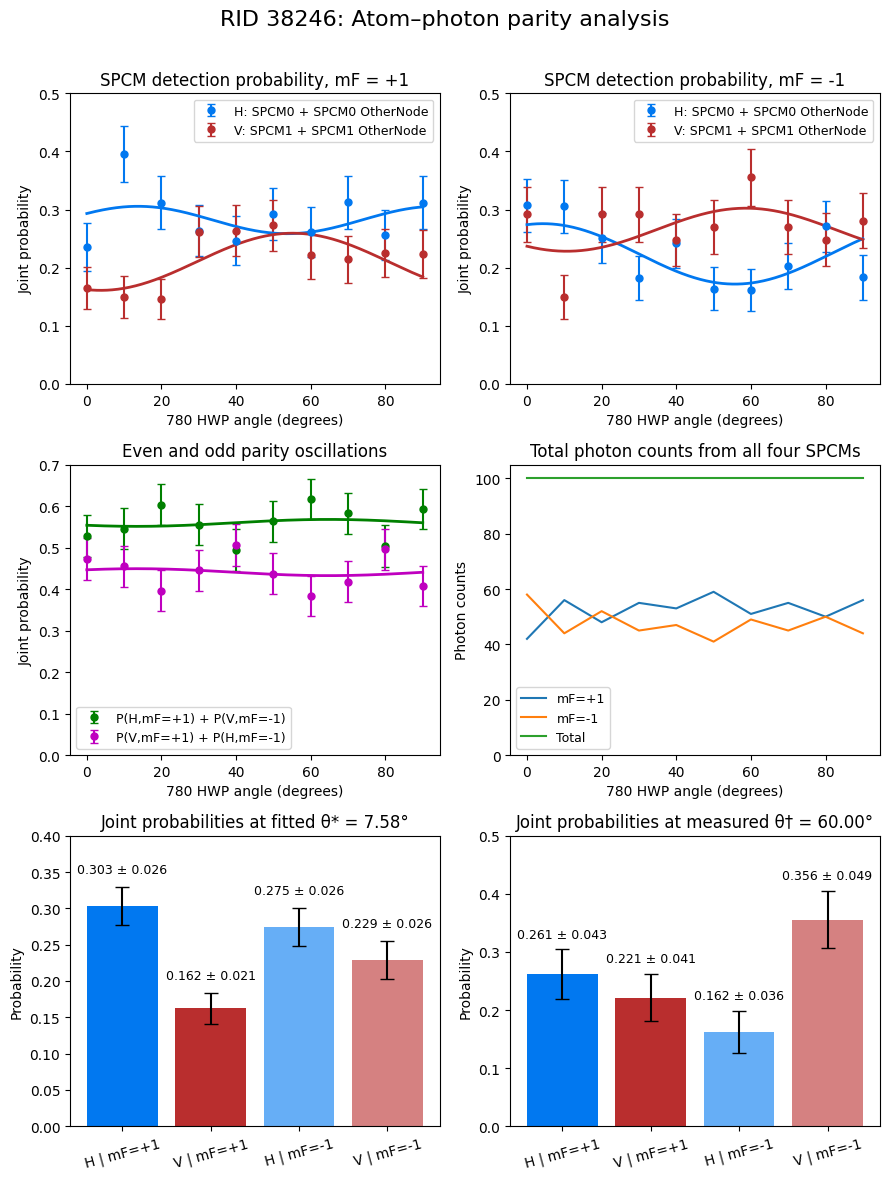

File index: 63, RID: 38247
experiment: atom_photon_parity_9_AllSPCM_experiment
override: {'t_photon_collection_time':100*ns, 'target_780_QWP':23.0,'t_start_MW_mapping_mu':8500,'t_MW_RF_pulse':122*us,'n_excitation_attempts':1, 'monitor_magnetometer_in_end_measurement':False}
Photon clicks included: original BS output = 545, other BS output = 455, combined = 1000
Visibility (H | mF=+1): 0.257 ± 0.078
Visibility (V | mF=+1): 0.336 ± 0.080
Visibility (H | mF=-1): 0.429 ± 0.082
Visibility (V | mF=-1): 0.411 ± 0.077

RID: 38247, n_measurements: 100, 780_QWP: 23.0, t_start_MW_mapping_mu: 8500, t_MW_RF_pulse: 0.000122
Visibility (sum A): 0.302 ± 0.046
Visibility (sum B): 0.319 ± 0.049

Optimal HWP angle θ* = 62.010° (maximum separation = 0.333)
Data-selected HWP angle θ† = 50.000° (maximum separation = 0.368; N=100)
Fidelity at optimal HWP θ* = 0.334 ± 0.036
Fidelity at data-selected HWP θ† = 0.357 ± 0.060

Probabilities at fitted optimal HWP angle:
P_SPCM1_Z1 = [0.184, 0.024]
P_SPCM0_Z1 = [0.

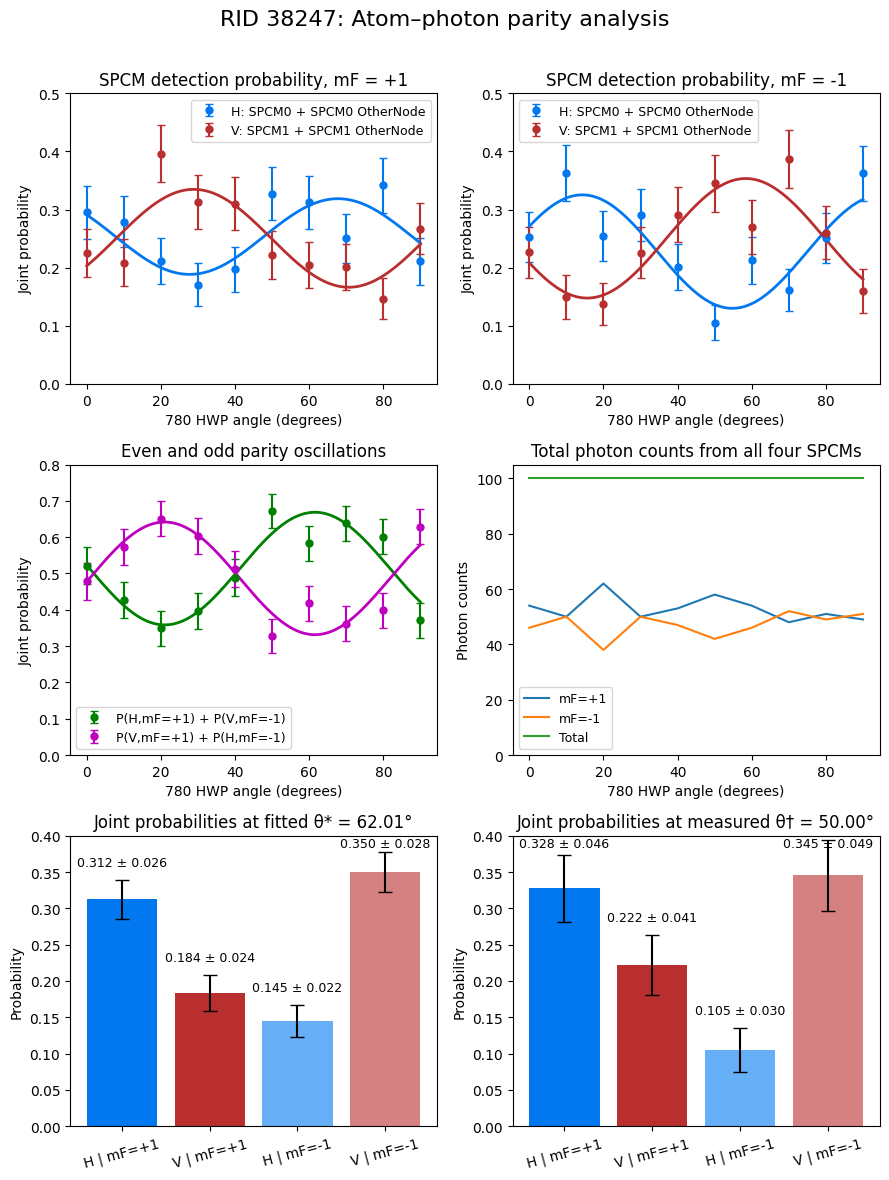



SUMMARY OF ALL SELECTED FILES


,RID no.,File index no.,QWP angle,Visibility sum A,Visibility sum B,Optimal HWP angle,Fidelity at optimal HWP,Data-selected HWP,Fidelity at data-selected HWP
0,38246,61,25.000°,0.015 ± 0.040,0.019 ± 0.051,7.578°,0.102 ± 0.036,60.000°,0.236 ± 0.060
1,38247,63,23.000°,0.302 ± 0.046,0.319 ± 0.049,62.010°,0.334 ± 0.036,50.000°,0.357 ± 0.060



Plain-text table:

 RID no.  File index no. QWP angle Visibility sum A Visibility sum B Optimal HWP angle Fidelity at optimal HWP Data-selected HWP Fidelity at data-selected HWP
   38246              61   25.000°    0.015 ± 0.040    0.019 ± 0.051            7.578°           0.102 ± 0.036           60.000°                 0.236 ± 0.060
   38247              63   23.000°    0.302 ± 0.046    0.319 ± 0.049           62.010°           0.334 ± 0.036           50.000°                 0.357 ± 0.060


In [108]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from IPython.display import display


# file_indices = {
# 16:''}


# ============================================================
# Analyze all selected files
# ============================================================

summary_rows = []

for idx, (f_idx, f_comment) in enumerate(file_indices.items()):
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f["rid"][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    f.close()

    print("="*80)
    print(f"File index: {f_idx}, RID: {rid}")
    print("experiment:", experiment_function)
    print("override:", override_ExperimentVariables)


    # ========================================================
    # Prepare data
    # ========================================================

    angles = angle_780_HWP

    spcm0 = SPCM0_SinglePhoton[1:] > 0
    spcm1 = SPCM1_SinglePhoton[1:] > 0
    spcm0_OtherNode = SPCM0_OtherNode_SinglePhoton[1:] > 0
    spcm1_OtherNode = SPCM1_OtherNode_SinglePhoton[1:] > 0

    # Alternative detector assignment:
    # spcm0 = spcm0_OtherNode
    # spcm1 = spcm1_OtherNode
    # spcm0_OtherNode = SPCM0_SinglePhoton[1:] > 0
    # spcm1_OtherNode = SPCM1_SinglePhoton[1:] > 0

    # Alternative datasets:
    # spcm0 = SPCM0_SinglePhoton_parity[1:] > 0
    # spcm1 = SPCM1_SinglePhoton_parity[1:] > 0
    # spcm0_OtherNode = SPCM0_OtherNode_SinglePhoton_parity[1:] > 0
    # spcm1_OtherNode = SPCM1_OtherNode_SinglePhoton_parity[1:] > 0

    spcm0_combined = spcm0.astype(np.int8) + spcm0_OtherNode.astype(np.int8)
    spcm1_combined = spcm1.astype(np.int8) + spcm1_OtherNode.astype(np.int8)

    atom_signal = AllSPCMs_parity_RO[1:] / t_SPCM_second_shot
    atom_Z1_mask = atom_signal <= single_atom_threshold
    atom_Zm1_mask = ~atom_Z1_mask

    event_lengths = {
        "angles": len(angles),
        "spcm0": len(spcm0),
        "spcm1": len(spcm1),
        "spcm0_OtherNode": len(spcm0_OtherNode),
        "spcm1_OtherNode": len(spcm1_OtherNode),
        "atom_signal": len(atom_signal),
    }

    if len(set(event_lengths.values())) != 1:
        raise ValueError(f"Per-event array length mismatch: {event_lengths}")

    unique_angles = np.unique(angles)

    clicks_original_arm = int(np.sum(spcm0) + np.sum(spcm1))
    clicks_other_arm = int(np.sum(spcm0_OtherNode) + np.sum(spcm1_OtherNode))
    clicks_combined = clicks_original_arm + clicks_other_arm

    print(
        f"Photon clicks included: original BS output = {clicks_original_arm}, "
        f"other BS output = {clicks_other_arm}, combined = {clicks_combined}"
    )


    # ========================================================
    # Channel-efficiency correction
    # ========================================================

    # eta_SPCM0_channel = 1.0
    # eta_SPCM1_channel = 0.8
    # eta_SPCM0_OtherNode_channel = 1.0
    # eta_SPCM1_OtherNode_channel = 0.96

    # eta_SPCM0_OtherNode_channel = 0.98
    # eta_SPCM1_OtherNode_channel = 0.84
    # eta_SPCM0_channel = 1.0
    # eta_SPCM1_channel = 0.97


    # eta_SPCM0_channel = 1.0
    # eta_SPCM1_channel = 1.0
    # eta_SPCM0_OtherNode_channel = 1.0
    # eta_SPCM1_OtherNode_channel = 1.0

    w_SPCM0 = 1.0/float(eta_SPCM0_channel)
    w_SPCM1 = 1.0/float(eta_SPCM1_channel)
    w_SPCM0_OtherNode = 1.0/float(eta_SPCM0_OtherNode_channel)
    w_SPCM1_OtherNode = 1.0/float(eta_SPCM1_OtherNode_channel)


    # ========================================================
    # Bin counts
    # ========================================================

    angles_Z1, counts_SPCM0_Z1, counts_SPCM1_Z1 = bin_counts_for_state(
        angles,
        spcm0_combined,
        spcm1_combined,
        atom_Z1_mask,
    )

    angles_Zm1, counts_SPCM0_Zm1, counts_SPCM1_Zm1 = bin_counts_for_state(
        angles,
        spcm0_combined,
        spcm1_combined,
        atom_Zm1_mask,
    )

    total_counts = (
        counts_SPCM0_Z1
        + counts_SPCM1_Z1
        + counts_SPCM0_Zm1
        + counts_SPCM1_Zm1
    )


    # ========================================================
    # Four joint probabilities
    # ========================================================

    prob_SPCM0_Z1, prob_err_SPCM0_Z1 = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [True, False, False, False],
    )

    prob_SPCM1_Z1, prob_err_SPCM1_Z1 = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [False, True, False, False],
    )

    prob_SPCM0_Zm1, prob_err_SPCM0_Zm1 = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [False, False, True, False],
    )

    prob_SPCM1_Zm1, prob_err_SPCM1_Zm1 = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [False, False, False, True],
    )


    # ========================================================
    # Fit four joint probabilities
    # ========================================================

    popt0_Z1, _, (angles_fit_SPCM0_Z1, y_fit_SPCM0_Z1), (
        vis_SPCM0_Z1,
        vis_err_SPCM0_Z1,
    ), pcov0_Z1 = fit_sinusoid_prob(
        angles_Z1,
        prob_SPCM0_Z1,
        prob_err_SPCM0_Z1,
    )

    popt1_Z1, _, (angles_fit_SPCM1_Z1, y_fit_SPCM1_Z1), (
        vis_SPCM1_Z1,
        vis_err_SPCM1_Z1,
    ), pcov1_Z1 = fit_sinusoid_prob(
        angles_Z1,
        prob_SPCM1_Z1,
        prob_err_SPCM1_Z1,
    )

    popt0_Zm1, _, (angles_fit_SPCM0_Zm1, y_fit_SPCM0_Zm1), (
        vis_SPCM0_Zm1,
        vis_err_SPCM0_Zm1,
    ), pcov0_Zm1 = fit_sinusoid_prob(
        angles_Zm1,
        prob_SPCM0_Zm1,
        prob_err_SPCM0_Zm1,
    )

    popt1_Zm1, _, (angles_fit_SPCM1_Zm1, y_fit_SPCM1_Zm1), (
        vis_SPCM1_Zm1,
        vis_err_SPCM1_Zm1,
    ), pcov1_Zm1 = fit_sinusoid_prob(
        angles_Zm1,
        prob_SPCM1_Zm1,
        prob_err_SPCM1_Zm1,
    )

    print(
        f"Visibility (H | mF=+1): "
        f"{vis_SPCM0_Z1:.3f} ± {vis_err_SPCM0_Z1:.3f}"
    )
    print(
        f"Visibility (V | mF=+1): "
        f"{vis_SPCM1_Z1:.3f} ± {vis_err_SPCM1_Z1:.3f}"
    )
    print(
        f"Visibility (H | mF=-1): "
        f"{vis_SPCM0_Zm1:.3f} ± {vis_err_SPCM0_Zm1:.3f}"
    )
    print(
        f"Visibility (V | mF=-1): "
        f"{vis_SPCM1_Zm1:.3f} ± {vis_err_SPCM1_Zm1:.3f}"
    )


    # ========================================================
    # Even and odd parity
    # ========================================================

    prob_sum_A, err_sum_A = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [True, False, False, True],
    )

    prob_sum_B, err_sum_B = corrected_joint_prob_and_err(
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1,
        [False, True, True, False],
    )

    popt_sumA, _, (xfit_sumA, yfit_sumA), (
        vis_sumA,
        viserr_sumA,
    ), _ = fit_sinusoid_prob(
        unique_angles,
        prob_sum_A,
        err_sum_A,
    )

    popt_sumB, _, (xfit_sumB, yfit_sumB), (
        vis_sumB,
        viserr_sumB,
    ), _ = fit_sinusoid_prob(
        unique_angles,
        prob_sum_B,
        err_sum_B,
    )

    print()
    print(
        f"RID: {rid}, n_measurements: {n_measurements}, "
        f"780_QWP: {angle_780_QWP[0]}, "
        f"t_start_MW_mapping_mu: {t_start_MW_mapping_mu}, "
        f"t_MW_RF_pulse: {t_MW_RF_pulse}"
    )
    print(f"Visibility (sum A): {vis_sumA:.3f} ± {viserr_sumA:.3f}")
    print(f"Visibility (sum B): {vis_sumB:.3f} ± {viserr_sumB:.3f}")


    # ========================================================
    # Best angle from fitted curves
    # ========================================================

    theta_grid = np.linspace(
        float(unique_angles.min()),
        float(unique_angles.max()),
        5001,
    )

    y0_Z1_grid = fit_eval(theta_grid, popt0_Z1)
    y1_Z1_grid = fit_eval(theta_grid, popt1_Z1)
    y0_Zm1_grid = fit_eval(theta_grid, popt0_Zm1)
    y1_Zm1_grid = fit_eval(theta_grid, popt1_Zm1)

    separation_grid = (
        np.abs(y0_Z1_grid - y1_Z1_grid)
        + np.abs(y0_Zm1_grid - y1_Zm1_grid)
    )

    i_star = int(np.argmax(separation_grid))
    theta_star = float(theta_grid[i_star])

    P_SPCM0_mFplus = float(fit_eval(theta_star, popt0_Z1))
    P_SPCM1_mFplus = float(fit_eval(theta_star, popt1_Z1))
    P_SPCM0_mFminus = float(fit_eval(theta_star, popt0_Zm1))
    P_SPCM1_mFminus = float(fit_eval(theta_star, popt1_Zm1))

    print()
    print(
        f"Optimal HWP angle θ* = {theta_star:.3f}° "
        f"(maximum separation = {separation_grid[i_star]:.3f})"
    )


    # ========================================================
    # Fitted probabilities and uncertainties
    # ========================================================

    labels = [
        "H | mF=+1",
        "V | mF=+1",
        "H | mF=-1",
        "V | mF=-1",
    ]

    values = [
        P_SPCM0_mFplus,
        P_SPCM1_mFplus,
        P_SPCM0_mFminus,
        P_SPCM1_mFminus,
    ]

    errors = [
        prob_sigma_at_theta(theta_star, popt0_Z1, pcov0_Z1),
        prob_sigma_at_theta(theta_star, popt1_Z1, pcov1_Z1),
        prob_sigma_at_theta(theta_star, popt0_Zm1, pcov0_Zm1),
        prob_sigma_at_theta(theta_star, popt1_Zm1, pcov1_Zm1),
    ]


    # ========================================================
    # Best angle from measured data
    # ========================================================

    p11 = prob_SPCM0_Z1
    p22 = prob_SPCM1_Z1
    p33 = prob_SPCM0_Zm1
    p44 = prob_SPCM1_Zm1

    separation_data_1 = p11 + p44 - 2*np.sqrt(p22*p33)
    separation_data_2 = p22 + p33 - 2*np.sqrt(p11*p44)

    if np.nanmax(separation_data_1) > np.nanmax(separation_data_2):
        separation_data = separation_data_1
    else:
        separation_data = separation_data_2

    idx_data_star = int(np.nanargmax(separation_data))
    theta_data_star = float(unique_angles[idx_data_star])
    Nstar = int(total_counts[idx_data_star])

    values_data = [
        float(prob_SPCM0_Z1[idx_data_star]),
        float(prob_SPCM1_Z1[idx_data_star]),
        float(prob_SPCM0_Zm1[idx_data_star]),
        float(prob_SPCM1_Zm1[idx_data_star]),
    ]

    errors_data = [
        float(prob_err_SPCM0_Z1[idx_data_star]),
        float(prob_err_SPCM1_Z1[idx_data_star]),
        float(prob_err_SPCM0_Zm1[idx_data_star]),
        float(prob_err_SPCM1_Zm1[idx_data_star]),
    ]

    print(
        f"Data-selected HWP angle θ† = {theta_data_star:.3f}° "
        f"(maximum separation = {separation_data[idx_data_star]:.3f}; "
        f"N={Nstar})"
    )


    # ========================================================
    # Fidelity at fitted and data-selected HWP angles
    # ========================================================

    # The same probabilities are currently used for the Z and X terms.
    F_fit, F_fit_err = fidelity_lower_bound(values, errors)
    F_data, F_data_err = fidelity_lower_bound(values_data, errors_data)

    print(f"Fidelity at optimal HWP θ* = {F_fit:.3f} ± {F_fit_err:.3f}")
    print(
        f"Fidelity at data-selected HWP θ† = "
        f"{F_data:.3f} ± {F_data_err:.3f}"
    )


    # ========================================================
    # Print probability values
    # ========================================================

    fitted_probabilities = {
        "P_SPCM0_Z1": (values[0], errors[0]),
        "P_SPCM1_Z1": (values[1], errors[1]),
        "P_SPCM0_Zm1": (values[2], errors[2]),
        "P_SPCM1_Zm1": (values[3], errors[3]),
        "P_SPCM0_X1": (values[0], errors[0]),
        "P_SPCM1_X1": (values[1], errors[1]),
        "P_SPCM0_Xm1": (values[2], errors[2]),
        "P_SPCM1_Xm1": (values[3], errors[3]),
    }

    data_probabilities = {
        "P_SPCM0_Z1": (values_data[0], errors_data[0]),
        "P_SPCM1_Z1": (values_data[1], errors_data[1]),
        "P_SPCM0_Zm1": (values_data[2], errors_data[2]),
        "P_SPCM1_Zm1": (values_data[3], errors_data[3]),
        "P_SPCM0_X1": (values_data[0], errors_data[0]),
        "P_SPCM1_X1": (values_data[1], errors_data[1]),
        "P_SPCM0_Xm1": (values_data[2], errors_data[2]),
        "P_SPCM1_Xm1": (values_data[3], errors_data[3]),
    }

    probability_print_order = [
        "P_SPCM1_Z1",
        "P_SPCM0_Z1",
        "P_SPCM1_Zm1",
        "P_SPCM0_Zm1",
        "P_SPCM1_X1",
        "P_SPCM0_X1",
        "P_SPCM1_Xm1",
        "P_SPCM0_Xm1",
    ]

    print("\nProbabilities at fitted optimal HWP angle:")
    for name in probability_print_order:
        value, error = fitted_probabilities[name]
        print(f"{name} = [{value:.3f}, {error:.3f}]")

    print("\nProbabilities at data-selected HWP angle:")
    for name in probability_print_order:
        value, error = data_probabilities[name]
        print(f"{name} = [{value:.3f}, {error:.3f}]")


    # ========================================================
    # Save results for final summary table
    # ========================================================

    summary_rows.append([
        int(rid),
        int(f_idx),
        f"{float(angle_780_QWP[0]):.3f}°",
        f"{vis_sumA:.3f} ± {viserr_sumA:.3f}",
        f"{vis_sumB:.3f} ± {viserr_sumB:.3f}",
        f"{theta_star:.3f}°",
        f"{F_fit:.3f} ± {F_fit_err:.3f}",
        f"{theta_data_star:.3f}°",
        f"{F_data:.3f} ± {F_data_err:.3f}",
    ])


    # ========================================================
    # Combined 3-row × 2-column figure
    # ========================================================

    fig, axes = plt.subplots(3, 2, figsize=(9, 12))
    axes = axes.ravel()

    plot_probability_subplot(
        axes[0],
        angles_Z1,
        prob_SPCM0_Z1,
        prob_err_SPCM0_Z1,
        prob_SPCM1_Z1,
        prob_err_SPCM1_Z1,
        (angles_fit_SPCM0_Z1, y_fit_SPCM0_Z1),
        (angles_fit_SPCM1_Z1, y_fit_SPCM1_Z1),
        "SPCM detection probability, mF = +1",
        [
            "H: SPCM0 + SPCM0 OtherNode",
            "V: SPCM1 + SPCM1 OtherNode",
        ],
        [color1, color2],
    )

    plot_probability_subplot(
        axes[1],
        angles_Zm1,
        prob_SPCM0_Zm1,
        prob_err_SPCM0_Zm1,
        prob_SPCM1_Zm1,
        prob_err_SPCM1_Zm1,
        (angles_fit_SPCM0_Zm1, y_fit_SPCM0_Zm1),
        (angles_fit_SPCM1_Zm1, y_fit_SPCM1_Zm1),
        "SPCM detection probability, mF = -1",
        [
            "H: SPCM0 + SPCM0 OtherNode",
            "V: SPCM1 + SPCM1 OtherNode",
        ],
        [color1, color2],
    )

    plot_probability_subplot(
        axes[2],
        unique_angles,
        prob_sum_A,
        err_sum_A,
        prob_sum_B,
        err_sum_B,
        (xfit_sumA, yfit_sumA),
        (xfit_sumB, yfit_sumB),
        "Even and odd parity oscillations",
        [
            "P(H,mF=+1) + P(V,mF=-1)",
            "P(V,mF=+1) + P(H,mF=-1)",
        ],
        ["g", "m"],
    )

    axes[3].plot(
        angles_Z1,
        counts_SPCM0_Z1 + counts_SPCM1_Z1,
        label="mF=+1",
    )
    axes[3].plot(
        angles_Zm1,
        counts_SPCM0_Zm1 + counts_SPCM1_Zm1,
        label="mF=-1",
    )
    axes[3].plot(
        angles_Zm1,
        total_counts,
        label="Total",
    )

    axes[3].set_xlabel("780 HWP angle (degrees)")
    axes[3].set_ylabel("Photon counts")
    axes[3].set_title("Total photon counts from all four SPCMs")
    axes[3].set_ylim(0, count_ylim(total_counts) + 5)
    axes[3].legend(fontsize=9)
    axes[3].grid(False)

    plot_bar_subplot(
        axes[4],
        labels,
        values,
        errors,
        f"Joint probabilities at fitted θ* = {theta_star:.2f}°",
    )

    plot_bar_subplot(
        axes[5],
        labels,
        values_data,
        errors_data,
        f"Joint probabilities at measured θ† = {theta_data_star:.2f}°",
    )

    fig.suptitle(
        f"RID {rid}: Atom–photon parity analysis",
        fontsize=16,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    # fig.savefig(
    #     f"Parity_analysis_3x2_RID_{rid}.pdf",
    #     bbox_inches="tight",
    # )

    plt.show()
    plt.close(fig)


# ============================================================
# Summary table for all selected files
# ============================================================

summary_columns = [
    "RID no.",
    "File index no.",
    "QWP angle",
    "Visibility sum A",
    "Visibility sum B",
    "Optimal HWP angle",
    "Fidelity at optimal HWP",
    "Data-selected HWP",
    "Fidelity at data-selected HWP",
]

summary_df = pd.DataFrame(summary_rows, columns=summary_columns)

print("\n")
print("="*80)
print("SUMMARY OF ALL SELECTED FILES")
print("="*80)

display(summary_df)

print("\nPlain-text table:\n")
print(summary_df.to_string(index=False))

### Joint Probabilities

Visibility (SPCM0 | mF=+1): 0.967 ± 0.075  | f=4.145 rad/deg
Visibility (SPCM1 | mF=+1): 0.959 ± 0.188  | f=3.760 rad/deg


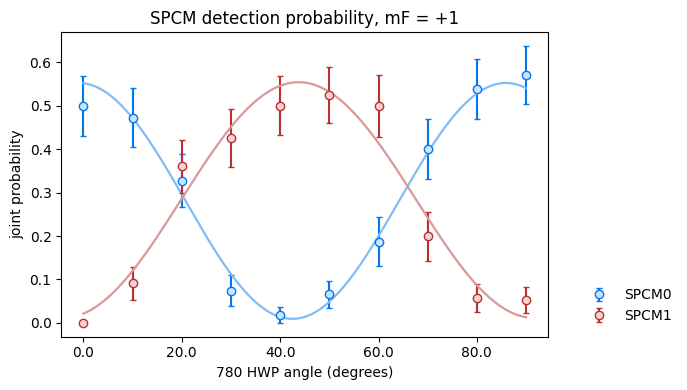

Visibility (SPCM0 | mF=−1): 0.835 ± 0.186  | f=4.072 rad/deg
Visibility (SPCM1 | mF=−1): 0.857 ± 0.161  | f=3.500 rad/deg


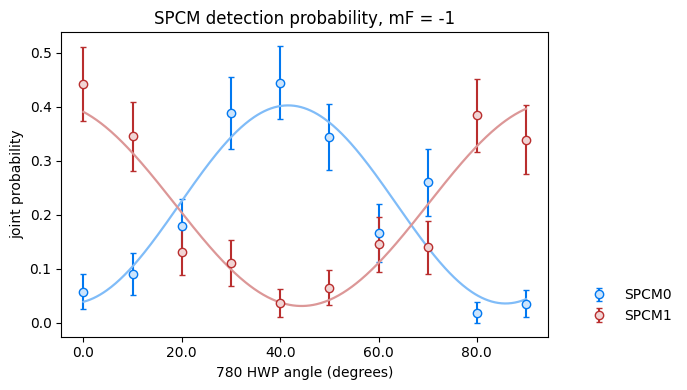

RID: 18790, n_measurements: 100, 780_QWP: 40.0, t_start_MW_mapping_mu: 10000, t_MW_RF_pulse: 0.0
Visibility (sum A): 0.911 ± 0.062  | f=3.901 rad/deg
Visibility (sum B): 0.894 ± 0.070  | f=3.901 rad/deg


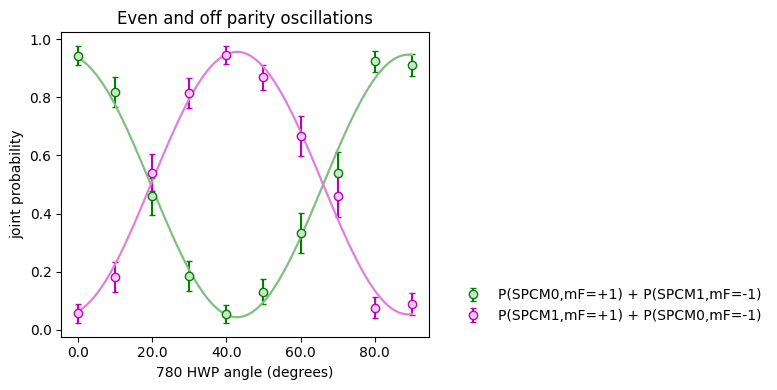

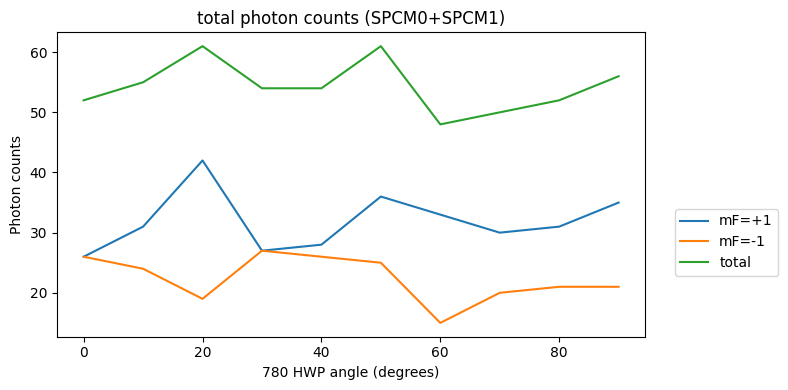


Optimal HWP angle θ* = 42.948° (max total separation 0.914)


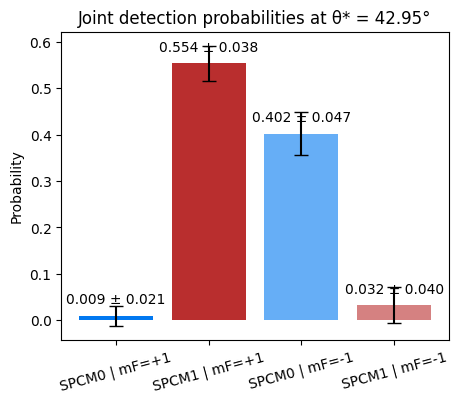

P_SPCM1_Z1 = [0.009, 0.021]
P_SPCM0_Z1 = [0.554, 0.038]
P_SPCM1_Zm1 = [0.402, 0.047]
P_SPCM0_Zm1 = [0.032, 0.040]
P_SPCM1_X1 = [0.009, 0.021]
P_SPCM0_X1 = [0.554, 0.038]
P_SPCM1_Xm1 = [0.402, 0.047]
P_SPCM0_Xm1 = [0.032, 0.040]
Data-selected HWP angle θ† = 0.000° max total separation among measured points = -0.779; N=100)
P_SPCM1_Z1 = [0.009, 0.021]
P_SPCM0_Z1 = [0.554, 0.038]
P_SPCM1_Zm1 = [0.402, 0.047]
P_SPCM0_Zm1 = [0.032, 0.040]
P_SPCM1_X1 = [0.009, 0.021]
P_SPCM0_X1 = [0.554, 0.038]
P_SPCM1_Xm1 = [0.402, 0.047]
P_SPCM0_Xm1 = [0.032, 0.040]


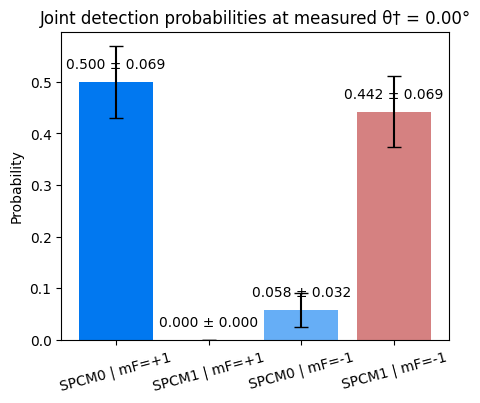

In [315]:
"""
Joint probabilities P(SPCM, mF).


The experiment (e.g. atom_photon_parity_2_experiment) scans the 780_HWP, for example, for a specific 780_QWP. Conditioned on detecting a photon (either from SPCM0 or 1), 
it saves the following datasets: 
BothSPCMs_parity_RO = array([  0, 106, 275, ..., 295, 283, 102]): Showing if atom is in F=1 or in F=2 level.
SPCM0_SinglePhoton = array([0, 0, 1, ..., 1, 0, 0])
SPCM1_SinglePhoton = array([0, 1, 0, ..., 0, 1, 1])
angle_780_HWP = array([  0,   0,   0, ..., 180, 180, 180])
angle_780_QWP = array([20., 20., 20., ..., 20., 20., 20.])

The following arrays will be used in the analysis:
atom_Z1_mask: [True, True, False, ...] is True when the atom is in state mF=+1 (i.e. atom_signal<=single_atom_threshold) in Z-basis.
atom_Zm1_mask: [False, False, True, ...] is True when the atom is in state mF=-1 (i.e. atom_signal>single_atom_threshold) in Z-basis.
unique_angles: [  0,  10,  20,  30, ..., 180] the list of HWP angles

angles_Z1: [  0,  10,  20,  30, ..., 180]
counts_SPCM0_Z1: [ 7, 12, 11, 17, 14, ...] list of counts from SPCM0 conditioned on atom in mF=+1
counts_SPCM1_Z1: [15, 22, 13,  9, 15, ...] list of counts from SPCM1 conditioned on atom in mF=+1


"""

angles = angle_780_HWP             # no [1:]
spcm0  = (SPCM0_SinglePhoton[1:] > 0)
spcm1  = (SPCM1_SinglePhoton[1:] > 0)
spcm0_OtherNode  = (SPCM0_OtherNode_SinglePhoton[1:] > 0)
spcm1_OtherNode  = (SPCM1_OtherNode_SinglePhoton[1:] > 0)


# ### testing
spcm0  = (SPCM0_OtherNode_SinglePhoton[1:] > 0)
spcm1  = (SPCM1_OtherNode_SinglePhoton[1:] > 0)


atom_signal   = AllSPCMs_parity_RO[1:] / t_SPCM_second_shot
atom_Z1_mask  = (atom_signal <= single_atom_threshold)   # mF = +1
atom_Zm1_mask = ~atom_Z1_mask                            # mF = −1

unique_angles = np.unique(angles)

# print(angles)

################################# Channel efficiency correction
eta_SPCM0_channel = 1.0
eta_SPCM1_channel = 1.0

# eta_SPCM1_channel = 0.673 ### Found from Rabi_2 experiment by scanning the HWP anngle and summing all the counts in GVS_Analsis  

w_SPCM0 = 1.0 / float(eta_SPCM0_channel)
w_SPCM1 = 1.0 / float(eta_SPCM1_channel)




#################################   Helper functions
def bin_counts_for_state(angles, spcm0, spcm1, atom_mask):
    """Per angle: counts on SPCM0 and SPCM1 within the selected atom state."""
    x, c0, c1 = [], [], []
    for ang in unique_angles:
        sel = (angles == ang) & atom_mask
        n0 = int(np.sum(spcm0 & sel))
        n1 = int(np.sum(spcm1 & sel))
        x.append(ang); c0.append(n0); c1.append(n1)
    return np.array(x), np.array(c0, int), np.array(c1, int)

def binom_err(p, N):
    """Binomial standard error (normal approximation)."""
    N = np.clip(np.asarray(N, int), 1, None)
    p = np.asarray(p, float)
    return np.sqrt(p*(1.0 - p)/N)

def corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1,
                                 counts_SPCM0_Zm1, counts_SPCM1_Zm1,
                                 group_mask):
    """
    Efficiency-corrected joint probability and statistical error.

    The four raw count arrays are ordered as:
        [SPCM0,mF=+1], [SPCM1,mF=+1], [SPCM0,mF=-1], [SPCM1,mF=-1]

    group_mask selects which of these four outcomes enter the numerator.
    The denominator is the sum of all four inverse-efficiency-weighted counts
    at the same HWP angle, so the corrected joint probabilities sum to 1.
    """
    counts = np.vstack([
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1
    ]).astype(float)

    weights = np.array([w_SPCM0, w_SPCM1, w_SPCM0, w_SPCM1], dtype=float)[:, None]
    mask = np.asarray(group_mask, dtype=bool)[:, None]

    weighted_counts = weights * counts
    den = np.sum(weighted_counts, axis=0)
    num = np.sum(weighted_counts * mask, axis=0)

    p = np.full_like(den, np.nan, dtype=float)
    np.divide(num, den, out=p, where=den > 0)

    ### Error propagation from raw counting statistics.
    ### When w_SPCM0 = w_SPCM1 = 1 this reduces to the usual binomial error.
    grad = np.zeros_like(counts, dtype=float)
    valid = den > 0
    grad[:, valid] = weights * (mask.astype(float) - p[None, valid]) / den[None, valid]
    var_p = np.sum((grad**2) * counts, axis=0)
    p_err = np.sqrt(np.maximum(var_p, 0.0))

    return p, p_err

def sinusoid_varf(theta_deg, A, f, phi, offset):
    """A * cos(f*theta + phi) + offset  (theta in degrees; f in rad/deg)"""
    return A * np.cos(np.deg2rad(f * theta_deg) + phi) + offset

def fit_sinusoid_prob(x, p, dp, f0=4.0):
    """
    LSQ fit of A*cos(f*theta + phi) + offset (theta in deg; f in rad/deg).
    Returns: popt, perr, (x_fit, y_fit), (V, V_err), pcov
    """
    x = np.asarray(x, float)
    p = np.asarray(p, float)
    sigma = np.clip(np.asarray(dp, float), 1e-6, None)

    ### Initial guesses
    A0   = (np.nanmax(p) - np.nanmin(p)) / 2.0 if np.isfinite(p).all() else 0.2
    off0 = np.nanmean(p) if np.isfinite(p).all() else 0.5
    phi0 = 0.0

    ### Gentle bounds to keep things physical (simple sinusoid, no logistic):
    ###   0 ≤ offset ≤ 1,  -1 ≤ A ≤ 1,  -2π ≤ phi ≤ 2π,  3.5 ≤ f ≤ 4.5 (expect ~4)
    bounds = ([-1.0,   3.5, -2*np.pi, 0.0],   # A, f, phi, offset
              [ 1.0,  4.5,  2*np.pi, 1.0])  # A, f, phi, offset

    p0 = [np.clip(A0, 0, 0.9), f0, phi0, np.clip(off0, 0.0, 1.0)]

    popt, pcov = curve_fit(
        sinusoid_varf, x, p, p0=p0,
        bounds=bounds, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))

    ### Visibility and its uncertainty (delta method on A, offset only)
    A, f, phi, off = popt
    sA, sOff = perr[0], perr[3]
    cov_A_off = pcov[0,3]
    V = np.abs(A) / off
    signA = 1.0 if A >= 0 else -1.0
    if off <= 0:
        V_err = np.nan
    else:
        dV_dA = signA / off
        dV_dOff = -np.abs(A) / (off**2)
        V_var = (dV_dA**2) * (sA**2) + (dV_dOff**2) * (sOff**2) + 2*dV_dA*dV_dOff*cov_A_off
        V_err = np.sqrt(max(V_var, 0.0))

    ### Smooth curve
    x_fit = np.linspace(x.min(), x.max(), 400)
    y_fit = sinusoid_varf(x_fit, *popt)
    return popt, perr, (x_fit, y_fit), (V, V_err), pcov
######################################################



#################################### mF = +1  (condition on atom_Z1_mask)
angles_Z1, counts_SPCM0_Z1, counts_SPCM1_Z1 = bin_counts_for_state(angles, spcm0, spcm1, atom_Z1_mask)
angles_Zm1, counts_SPCM0_Zm1, counts_SPCM1_Zm1 = bin_counts_for_state(angles, spcm0, spcm1, atom_Zm1_mask)

total_counts = np.full_like(counts_SPCM0_Z1, int(n_measurements), dtype=int) ### total counts from both SPCMs which should be equal to n_measurements

prob_SPCM0_Z1, prob_err_SPCM0_Z1 = corrected_joint_prob_and_err(
    counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1,
    [True, False, False, False]
)
prob_SPCM1_Z1, prob_err_SPCM1_Z1 = corrected_joint_prob_and_err(
    counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1,
    [False, True, False, False]
)

(popt0_Z1, perr0_Z1, (angles_fit_SPCM0_Z1, y_fit_SPCM0_Z1),
 (vis_SPCM0_Z1, vis_err_SPCM0_Z1), pcov0_Z1) = fit_sinusoid_prob(angles_Z1, prob_SPCM0_Z1, prob_err_SPCM0_Z1, f0=4.0)

(popt1_Z1, perr1_Z1, (angles_fit_SPCM1_Z1, y_fit_SPCM1_Z1),
 (vis_SPCM1_Z1, vis_err_SPCM1_Z1), pcov1_Z1) = fit_sinusoid_prob(angles_Z1, prob_SPCM1_Z1, prob_err_SPCM1_Z1, f0=4.0)

print(f"Visibility (SPCM0 | mF=+1): {vis_SPCM0_Z1:.3f} ± {vis_err_SPCM0_Z1:.3f}  | f={popt0_Z1[1]:.3f} rad/deg")
print(f"Visibility (SPCM1 | mF=+1): {vis_SPCM1_Z1:.3f} ± {vis_err_SPCM1_Z1:.3f}  | f={popt1_Z1[1]:.3f} rad/deg")


###########Prepare data and plot 
series = [{
    "x": angles_Z1,
    "y": prob_SPCM0_Z1,
    "yerr": prob_err_SPCM0_Z1,                        
    "label": "SPCM0",
    "color": color1,   
    "fit": (angles_fit_SPCM0_Z1, y_fit_SPCM0_Z1),      
    # "fit_style": {"linestyle": "--"}      # optional
},
         {
    "x": angles_Z1,
    "y": prob_SPCM1_Z1,
    "yerr": prob_err_SPCM1_Z1,                        
    "label": "SPCM1",
    "color": color2,   
    "fit": (angles_fit_SPCM1_Z1, y_fit_SPCM1_Z1),           
    # "fit_style": {"linestyle": "--"}      # optional
}]

plot_series_with_fit(
    series,
    title="SPCM detection probability, mF = +1",
    xlabel="780 HWP angle (degrees)",
    ylabel="joint probability",
    figsize=(7,4),
    # ylim=(0, 1),            
    legend_out=True,
    # save="prob_SPCM0_Z1.pdf",
    grid=False
)
########### plot end



######################################## mF = −1  (condition on atom_Zm1_mask)

prob_SPCM0_Zm1, prob_err_SPCM0_Zm1 = corrected_joint_prob_and_err(
    counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1,
    [False, False, True, False]
)
prob_SPCM1_Zm1, prob_err_SPCM1_Zm1 = corrected_joint_prob_and_err(
    counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1,
    [False, False, False, True]
)

(popt0_Zm1, perr0_Zm1, (xfit0_Zm1, yfit0_Zm1),
 (vis_SPCM0_Zm1, vis_err_SPCM0_Zm1), pcov0_Zm1) = fit_sinusoid_prob(angles_Zm1, prob_SPCM0_Zm1, prob_err_SPCM0_Zm1, f0=4.0)

(popt1_Zm1, perr1_Zm1, (xfit1_Zm1, yfit1_Zm1),
 (vis_SPCM1_Zm1, vis_err_SPCM1_Zm1), pcov1_Zm1) = fit_sinusoid_prob(angles_Zm1, prob_SPCM1_Zm1, prob_err_SPCM1_Zm1, f0=4.0)

print(f"Visibility (SPCM0 | mF=−1): {vis_SPCM0_Zm1:.3f} ± {vis_err_SPCM0_Zm1:.3f}  | f={popt0_Zm1[1]:.3f} rad/deg")
print(f"Visibility (SPCM1 | mF=−1): {vis_SPCM1_Zm1:.3f} ± {vis_err_SPCM1_Zm1:.3f}  | f={popt1_Zm1[1]:.3f} rad/deg")

##### Prepare data and plot 
series = [{
    "x": angles_Zm1,
    "y": prob_SPCM0_Zm1,
    "yerr": prob_err_SPCM0_Zm1,                        
    "label": "SPCM0",
    "color": color1,   
    "fit": (xfit0_Zm1, yfit0_Zm1),            
    # "fit_style": {"linestyle": "--"}      # optional
},
         {
    "x": angles_Zm1,
    "y": prob_SPCM1_Zm1,
    "yerr": prob_err_SPCM1_Zm1,                        
    "label": "SPCM1",
    "color": color2,   
    "fit": (xfit1_Zm1, yfit1_Zm1),            
    # "fit_style": {"linestyle": "--"}      # optional
}]

plot_series_with_fit(
    series,
    title="SPCM detection probability, mF = -1",
    xlabel="780 HWP angle (degrees)",
    ylabel="joint probability",
    figsize=(7,4),
    # ylim=(0, 1),            
    legend_out=True,
    # save="prob_SPCM0_Zm1.pdf",
    grid=False
)
########### plot end


######################################### Even and Odd parity oscillations
#### prob_sum_A = P(SPCM0 & mF=+1) + P(SPCM1 & mF=-1)
sum_counts_A = w_SPCM0*counts_SPCM0_Z1 + w_SPCM1*counts_SPCM1_Zm1     # efficiency-corrected joint counts 
prob_sum_A, err_sum_A = corrected_joint_prob_and_err(
    counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1,
    [True, False, False, True]
)

### Fit the sinusoid 
(popt_sumA, perr_sumA, (xfit_sumA, yfit_sumA),
 (vis_sumA, viserr_sumA), pcov_sumA) = fit_sinusoid_prob(unique_angles, prob_sum_A, err_sum_A, f0=4.0)

print(f"RID: {str(rid)}, n_measurements: {n_measurements}, 780_QWP: {angle_780_QWP[0]}, t_start_MW_mapping_mu: {t_start_MW_mapping_mu}, t_MW_RF_pulse: {t_MW_RF_pulse}")
print(f"Visibility (sum A): {vis_sumA:.3f} ± {viserr_sumA:.3f}  | f={popt_sumA[1]:.3f} rad/deg")


#### prob_sum_B = P(SPCM1 & mF=+1) + P(SPCM0 & mF=-1)
sum_counts_B = w_SPCM1*counts_SPCM1_Z1 + w_SPCM0*counts_SPCM0_Zm1     # efficiency-corrected joint counts
prob_sum_B, err_sum_B = corrected_joint_prob_and_err(
    counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1,
    [False, True, True, False]
)

### Fit the sinusoid 
(popt_sumB, perr_sumB, (xfit_sumB, yfit_sumB),
 (vis_sumB, viserr_sumB), pcov_sumB) = fit_sinusoid_prob(unique_angles, prob_sum_B, err_sum_B, f0=4.0)

print(f"Visibility (sum B): {vis_sumB:.3f} ± {viserr_sumB:.3f}  | f={popt_sumB[1]:.3f} rad/deg")


##### Prepare data and plot 
series = [{
    "x": unique_angles,
    "y": prob_sum_A,
    "yerr": err_sum_A,                        
    "label": "P(SPCM0,mF=+1) + P(SPCM1,mF=-1)",
    "color": 'g',   
    "fit": (xfit_sumA, yfit_sumA),            
    # "fit_style": {"linestyle": "--"}      # optional
},
         {
    "x": unique_angles,
    "y": prob_sum_B,
    "yerr": err_sum_B,                        
    "label": "P(SPCM1,mF=+1) + P(SPCM0,mF=-1)",
    "color": 'm',   
    "fit": (xfit_sumB, yfit_sumB),            
    # "fit_style": {"linestyle": "--"}      # optional
}]

plot_series_with_fit(
    series,
    title="Even and off parity oscillations",
    xlabel="780 HWP angle (degrees)",
    ylabel="joint probability",
    figsize=(8,4),
    # ylim=(0, 1),            
    legend_out=True,
    # save="prob_sum_A.pdf",
    grid=False
)
########### plot end



######################################################
### plotting the sum of all data for checking 
plt.figure(figsize=(8, 4))
plt.plot(angles_Z1, counts_SPCM0_Z1+counts_SPCM1_Z1, label="mF=+1")
plt.plot(angles_Zm1, counts_SPCM0_Zm1+counts_SPCM1_Zm1, label="mF=-1")
plt.plot(angles_Zm1, counts_SPCM0_Z1+counts_SPCM1_Z1+counts_SPCM0_Zm1+counts_SPCM1_Zm1, label="total")

plt.xlabel('780 HWP angle (degrees)')
plt.ylabel('Photon counts')
plt.title('total photon counts (SPCM0+SPCM1)')
plt.legend(loc=(1.05,0.2))
plt.tight_layout()
plt.show()


######################################################
#### Pick best HWP angle and calculate Joint probabilies
### theta_star maximizes |SPCM0−SPCM1| summed over mF=+1 and mF=−1
def _fit_eval(theta_deg, popt):
    """Evaluate fitted P(theta) with clipping to [0,1]."""
    val = sinusoid_varf(np.asarray(theta_deg, float), *popt)
    return np.clip(val, 0.0, 1.0)

# Dense scan over your angle range (use the same min/max range you fit over)
theta_grid = np.linspace(float(unique_angles.min()),
                         float(unique_angles.max()), 5001)

# Fitted curves for both SPCM channels and both atom states
y0_Z1_grid  = _fit_eval(theta_grid, popt0_Z1)   # P(SPCM0 | mF=+1)
y1_Z1_grid  = _fit_eval(theta_grid, popt1_Z1)   # P(SPCM1 | mF=+1)
y0_Zm1_grid = _fit_eval(theta_grid, popt0_Zm1)  # P(SPCM0 | mF=-1)
y1_Zm1_grid = _fit_eval(theta_grid, popt1_Zm1)  # P(SPCM1 | mF=-1)

# Choose a single angle that maximizes the overall separation between SPCM0 and SPCM1
# across both atom states (sum of absolute separations).
sep_grid = np.abs(y0_Z1_grid - y1_Z1_grid) + np.abs(y0_Zm1_grid - y1_Zm1_grid)
i_star = int(np.argmax(sep_grid))
theta_star = float(theta_grid[i_star])
# theta_star = 72

# Evaluate the four Joint probabilities at theta_star
P_SPCM0_mFplus  = _fit_eval(theta_star, popt0_Z1)   # P(SPCM0 | mF=+1)
P_SPCM1_mFplus  = _fit_eval(theta_star, popt1_Z1)   # P(SPCM1 | mF=+1)
P_SPCM0_mFminus = _fit_eval(theta_star, popt0_Zm1)  # P(SPCM0 | mF=-1)
P_SPCM1_mFminus = _fit_eval(theta_star, popt1_Zm1)  # P(SPCM1 | mF=-1)

print(f"\nOptimal HWP angle θ* = {theta_star:.3f}° "
      f"(max total separation {sep_grid[i_star]:.3f})")


##################################################### Bar chart the Joint probabilies
#### Uncertainty at theta_star via Jacobian and pcov 
def prob_sigma_at_theta(theta_deg, popt, pcov):
    A, f, phi, off = popt
    g = np.deg2rad(f * theta_deg) + phi
    cosg, sing = np.cos(g), np.sin(g)
    dA   = cosg
    df   = -A * sing * (np.pi/180.0) * theta_deg
    dphi = -A * sing
    doff = 1.0
    J = np.array([dA, df, dphi, doff], dtype=float)
    var = float(J @ pcov @ J)
    return np.sqrt(max(var, 0.0))

err_SPCM0_mFplus  = prob_sigma_at_theta(theta_star, popt0_Z1,  pcov0_Z1)
err_SPCM1_mFplus  = prob_sigma_at_theta(theta_star, popt1_Z1,  pcov1_Z1)
err_SPCM0_mFminus = prob_sigma_at_theta(theta_star, popt0_Zm1, pcov0_Zm1)
err_SPCM1_mFminus = prob_sigma_at_theta(theta_star, popt1_Zm1, pcov1_Zm1)

errors = [err_SPCM0_mFplus, err_SPCM1_mFplus, err_SPCM0_mFminus, err_SPCM1_mFminus]

#### bar chart with error bars
labels = ["SPCM0 | mF=+1", "SPCM1 | mF=+1", "SPCM0 | mF=-1", "SPCM1 | mF=-1"]
values = [P_SPCM0_mFplus, P_SPCM1_mFplus, P_SPCM0_mFminus, P_SPCM1_mFminus]

bar_colors = [color1, color2, color1, color2]
bar_alphas = [1.0, 1.0, 0.6, 0.6]
xpos = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(xpos, values, yerr=errors, capsize=5,
              color=[(*c, a) if len(c)==3 else c for c,a in zip(bar_colors, bar_alphas)],
              edgecolor="none", linewidth=0)

ax.set_xticks(xpos)
ax.set_xticklabels(labels, rotation=15)
# ax.set_ylim(0, 1.05)
ax.set_ylabel("Probability")
ax.set_title(f"Joint detection probabilities at θ* = {theta_star:.2f}°")


### Annotate bar heights with value ± error
for i, rect in enumerate(bars):
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 0.02,
            f"{values[i]:.3f} ± {errors[i]:.3f}",
            ha='center', va='bottom', fontsize=10)

fig.savefig("Joint_probs_bar_chart_with_errors.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)




###################################################### Best angle from MEASURED data (not fit), and its bar chart
### finding the angle that maximizes the fidelity
p11 = prob_SPCM0_Z1
p44 = prob_SPCM1_Zm1
p22 = prob_SPCM1_Z1
p33 = prob_SPCM0_Zm1

sep_data1 = p11 + p44 - 2*np.sqrt(p22*p33)
sep_data2 = p22 + p33 - 2*np.sqrt(p11*p22)
sep_data = sep_data1 if sep_data1.max() > sep_data2.max() else sep_data2

### Pick the angle with maximum separation among the measured points
idx_data_star = int(np.argmax(sep_data))
theta_data_star = float(unique_angles[idx_data_star])

# (Optional) if there is a tie and you want the one closest to the fit-based theta_star, uncomment:
# tied = np.where(np.isclose(sep_data, sep_data.max(), rtol=0, atol=1e-12))[0]
# if len(tied) > 1:
#     idx_data_star = tied[np.argmin(np.abs(unique_angles[tied] - theta_star))]
#     theta_data_star = float(unique_angles[idx_data_star])

### Extract the four probabilities at this measured angle
P0p_data = float(prob_SPCM0_Z1[idx_data_star])   # "SPCM0 | mF=+1" (joint, normalized by n_measurements)
P1p_data = float(prob_SPCM1_Z1[idx_data_star])   # "SPCM1 | mF=+1"
P0m_data = float(prob_SPCM0_Zm1[idx_data_star])  # "SPCM0 | mF=-1"
P1m_data = float(prob_SPCM1_Zm1[idx_data_star])  # "SPCM1 | mF=-1"

### Statistical SE at that angle, including the inverse-efficiency weighting
Nstar = int(total_counts[idx_data_star])
err0p_data = float(prob_err_SPCM0_Z1[idx_data_star])
err1p_data = float(prob_err_SPCM1_Z1[idx_data_star])
err0m_data = float(prob_err_SPCM0_Zm1[idx_data_star])
err1m_data = float(prob_err_SPCM1_Zm1[idx_data_star])

# print(f"Data-chosen at HWP angle θ† = {theta_data_star:.3f}° "
#       f"(max total separation among measured points = {sep_data[idx_data_star]:.3f}; N={Nstar})")


##

bar_names_Z = ["P_SPCM1_Z1", "P_SPCM0_Z1", "P_SPCM1_Zm1", "P_SPCM0_Zm1"]
bar_names_X = ["P_SPCM1_X1", "P_SPCM0_X1", "P_SPCM1_Xm1", "P_SPCM0_Xm1"]

### printing out for convenience
for name, value, error in zip(bar_names_Z, values, errors):
    print(f"{name} = [{value:.3f}, {error:.3f}]")
for name, value, error in zip(bar_names_X, values, errors):
    print(f"{name} = [{value:.3f}, {error:.3f}]")
    
print(f"Data-selected HWP angle θ† = {theta_data_star:.3f}° max total separation among measured points = {separation_data[idx_data_star]:.3f}; N={Nstar})")

### printing out for convenience
for name, value, error in zip(bar_names_Z, values, errors):
    print(f"{name} = [{value:.3f}, {error:.3f}]")
for name, value, error in zip(bar_names_X, values, errors):
    print(f"{name} = [{value:.3f}, {error:.3f}]")


######################################### Bar chart
labels_data = ["SPCM0 | mF=+1", "SPCM1 | mF=+1", "SPCM0 | mF=-1", "SPCM1 | mF=-1"]
values_data = [P0p_data, P1p_data, P0m_data, P1m_data]
errors_data = [err0p_data, err1p_data, err0m_data, err1m_data]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    np.arange(len(labels_data)),
    values_data,
    yerr=errors_data,
    capsize=5,
    color=[(*color1, 1.0), (*color2, 1.0), (*color1, 0.6), (*color2, 0.6)],
    edgecolor="none",
    linewidth=0
)

ax.set_xticks(np.arange(len(labels_data)))
ax.set_xticklabels(labels_data, rotation=15)
ax.set_ylabel("Probability")
ax.set_title(f"Joint detection probabilities at measured θ† = {theta_data_star:.2f}°")

for i, rect in enumerate(bars):
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 0.02,
            f"{values_data[i]:.3f} ± {errors_data[i]:.3f}",
            ha='center', va='bottom', fontsize=10)

fig.savefig("Joint_probs_bar_chart_measured_angle.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)
######################################################################

### Joint Probabilities with different SPCM efficiencies

In [234]:
"""
Joint probabilities P(SPCM, mF).


The experiment (e.g. atom_photon_parity_2_experiment) scans the 780_HWP, for example, for a specific 780_QWP. Conditioned on detecting a photon (either from SPCM0 or 1), 
it saves the following datasets: 
BothSPCMs_parity_RO = array([  0, 106, 275, ..., 295, 283, 102]): Showing if atom is in F=1 or in F=2 level.
SPCM0_SinglePhoton = array([0, 0, 1, ..., 1, 0, 0])
SPCM1_SinglePhoton = array([0, 1, 0, ..., 0, 1, 1])
angle_780_HWP = array([  0,   0,   0, ..., 180, 180, 180])
angle_780_QWP = array([20., 20., 20., ..., 20., 20., 20.])

The following arrays will be used in the analysis:
atom_Z1_mask: [True, True, False, ...] is True when the atom is in state mF=+1 (i.e. atom_signal<=single_atom_threshold) in Z-basis.
atom_Zm1_mask: [False, False, True, ...] is True when the atom is in state mF=-1 (i.e. atom_signal>single_atom_threshold) in Z-basis.
unique_angles: [  0,  10,  20,  30, ..., 180] the list of HWP angles

angles_Z1: [  0,  10,  20,  30, ..., 180]
counts_SPCM0_Z1: [ 7, 12, 11, 17, 14, ...] list of counts from SPCM0 conditioned on atom in mF=+1
counts_SPCM1_Z1: [15, 22, 13,  9, 15, ...] list of counts from SPCM1 conditioned on atom in mF=+1


"""

angles = angle_780_HWP             # no [1:]
# spcm0  = (SPCM0_SinglePhoton[1:] > 0)
# spcm1  = (SPCM1_SinglePhoton[1:] > 0)
spcm0  = (SPCM0_SinglePhoton_parity[1:] > 0)
spcm1  = (SPCM1_SinglePhoton_parity[1:] > 0)
atom_signal   = BothSPCMs_parity_RO[1:] / t_SPCM_second_shot
atom_Z1_mask  = (atom_signal <= single_atom_threshold)   # mF = +1
atom_Zm1_mask = ~atom_Z1_mask                            # mF = −1

unique_angles = np.unique(angles)

# print(angles)

################################# Channel efficiency correction
eta_SPCM0_channel = 1.0
eta_SPCM1_channel = 0.673 ### Found from Rabi_2 experiment by scanning the HWP anngle and summing all the counts in GVS_Analsis  

w_SPCM0 = 1.0 / float(eta_SPCM0_channel)
w_SPCM1 = 1.0 / float(eta_SPCM1_channel)




#################################   Helper functions
def bin_counts_for_state(angles, spcm0, spcm1, atom_mask):
    """Per angle: counts on SPCM0 and SPCM1 within the selected atom state."""
    x, c0, c1 = [], [], []
    for ang in unique_angles:
        sel = (angles == ang) & atom_mask
        n0 = int(np.sum(spcm0 & sel))
        n1 = int(np.sum(spcm1 & sel))
        x.append(ang); c0.append(n0); c1.append(n1)
    return np.array(x), np.array(c0, int), np.array(c1, int)

def binom_err(p, N):
    """Binomial standard error (normal approximation)."""
    N = np.clip(np.asarray(N, int), 1, None)
    p = np.asarray(p, float)
    return np.sqrt(p*(1.0 - p)/N)

def corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1,
                                 counts_SPCM0_Zm1, counts_SPCM1_Zm1,
                                 group_mask):
    """
    Efficiency-corrected joint probability and statistical error.

    The four raw count arrays are ordered as:
        [SPCM0,mF=+1], [SPCM1,mF=+1], [SPCM0,mF=-1], [SPCM1,mF=-1]

    group_mask selects which of these four outcomes enter the numerator.
    The denominator is the sum of all four inverse-efficiency-weighted counts
    at the same HWP angle, so the corrected joint probabilities sum to 1.
    """
    counts = np.vstack([
        counts_SPCM0_Z1,
        counts_SPCM1_Z1,
        counts_SPCM0_Zm1,
        counts_SPCM1_Zm1
    ]).astype(float)

    weights = np.array([w_SPCM0, w_SPCM1, w_SPCM0, w_SPCM1], dtype=float)[:, None]
    mask = np.asarray(group_mask, dtype=bool)[:, None]

    weighted_counts = weights * counts
    den = np.sum(weighted_counts, axis=0)
    num = np.sum(weighted_counts * mask, axis=0)

    p = np.full_like(den, np.nan, dtype=float)
    np.divide(num, den, out=p, where=den > 0)

    ### Error propagation from raw counting statistics.
    ### When w_SPCM0 = w_SPCM1 = 1 this reduces to the usual binomial error.
    grad = np.zeros_like(counts, dtype=float)
    valid = den > 0
    grad[:, valid] = weights * (mask.astype(float) - p[None, valid]) / den[None, valid]
    var_p = np.sum((grad**2) * counts, axis=0)
    p_err = np.sqrt(np.maximum(var_p, 0.0))

    return p, p_err

def sinusoid_varf(theta_deg, A, f, phi, offset):
    """A * cos(f*theta + phi) + offset  (theta in degrees; f in rad/deg)"""
    return A * np.cos(np.deg2rad(f * theta_deg) + phi) + offset

def fit_sinusoid_prob(x, p, dp, f0=4.0):
    """
    LSQ fit of A*cos(f*theta + phi) + offset (theta in deg; f in rad/deg).
    Returns: popt, perr, (x_fit, y_fit), (V, V_err), pcov
    """
    x = np.asarray(x, float)
    p = np.asarray(p, float)
    sigma = np.clip(np.asarray(dp, float), 1e-6, None)

    ### Initial guesses
    A0   = (np.nanmax(p) - np.nanmin(p)) / 2.0 if np.isfinite(p).all() else 0.2
    off0 = np.nanmean(p) if np.isfinite(p).all() else 0.5
    phi0 = 0.0

    ### Gentle bounds to keep things physical (simple sinusoid, no logistic):
    ###   0 ≤ offset ≤ 1,  -1 ≤ A ≤ 1,  -2π ≤ phi ≤ 2π,  3.5 ≤ f ≤ 4.5 (expect ~4)
    bounds = ([-1.0,   3.5, -2*np.pi, 0.0],   # A, f, phi, offset
              [ 1.0,  4.5,  2*np.pi, 1.0])  # A, f, phi, offset

    p0 = [np.clip(A0, 0, 0.9), f0, phi0, np.clip(off0, 0.0, 1.0)]

    popt, pcov = curve_fit(
        sinusoid_varf, x, p, p0=p0,
        bounds=bounds, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))

    ### Visibility and its uncertainty (delta method on A, offset only)
    A, f, phi, off = popt
    sA, sOff = perr[0], perr[3]
    cov_A_off = pcov[0,3]
    V = np.abs(A) / off
    signA = 1.0 if A >= 0 else -1.0
    if off <= 0:
        V_err = np.nan
    else:
        dV_dA = signA / off
        dV_dOff = -np.abs(A) / (off**2)
        V_var = (dV_dA**2) * (sA**2) + (dV_dOff**2) * (sOff**2) + 2*dV_dA*dV_dOff*cov_A_off
        V_err = np.sqrt(max(V_var, 0.0))

    ### Smooth curve
    x_fit = np.linspace(x.min(), x.max(), 400)
    y_fit = sinusoid_varf(x_fit, *popt)
    return popt, perr, (x_fit, y_fit), (V, V_err), pcov
######################################################



#################################### mF = +1  (condition on atom_Z1_mask)
angles_Z1, counts_SPCM0_Z1, counts_SPCM1_Z1 = bin_counts_for_state(angles, spcm0, spcm1, atom_Z1_mask)
angles_Zm1, counts_SPCM0_Zm1, counts_SPCM1_Zm1 = bin_counts_for_state(angles, spcm0, spcm1, atom_Zm1_mask)

total_counts = np.full_like(counts_SPCM0_Z1, int(n_measurements), dtype=int) ### total counts from both SPCMs which should be equal to n_measurements

prob_SPCM0_Z1, prob_err_SPCM0_Z1 = corrected_joint_prob_and_err(
    counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1,
    [True, False, False, False]
)
prob_SPCM1_Z1, prob_err_SPCM1_Z1 = corrected_joint_prob_and_err(
    counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1,
    [False, True, False, False]
)

(popt0_Z1, perr0_Z1, (angles_fit_SPCM0_Z1, y_fit_SPCM0_Z1),
 (vis_SPCM0_Z1, vis_err_SPCM0_Z1), pcov0_Z1) = fit_sinusoid_prob(angles_Z1, prob_SPCM0_Z1, prob_err_SPCM0_Z1, f0=4.0)

(popt1_Z1, perr1_Z1, (angles_fit_SPCM1_Z1, y_fit_SPCM1_Z1),
 (vis_SPCM1_Z1, vis_err_SPCM1_Z1), pcov1_Z1) = fit_sinusoid_prob(angles_Z1, prob_SPCM1_Z1, prob_err_SPCM1_Z1, f0=4.0)

print(f"Visibility (SPCM0 | mF=+1): {vis_SPCM0_Z1:.3f} ± {vis_err_SPCM0_Z1:.3f}  | f={popt0_Z1[1]:.3f} rad/deg")
print(f"Visibility (SPCM1 | mF=+1): {vis_SPCM1_Z1:.3f} ± {vis_err_SPCM1_Z1:.3f}  | f={popt1_Z1[1]:.3f} rad/deg")


###########Prepare data and plot 
series = [{
    "x": angles_Z1,
    "y": prob_SPCM0_Z1,
    "yerr": prob_err_SPCM0_Z1,                        
    "label": "SPCM0",
    "color": color1,   
    "fit": (angles_fit_SPCM0_Z1, y_fit_SPCM0_Z1),      
    # "fit_style": {"linestyle": "--"}      # optional
},
         {
    "x": angles_Z1,
    "y": prob_SPCM1_Z1,
    "yerr": prob_err_SPCM1_Z1,                        
    "label": "SPCM1",
    "color": color2,   
    "fit": (angles_fit_SPCM1_Z1, y_fit_SPCM1_Z1),           
    # "fit_style": {"linestyle": "--"}      # optional
}]

plot_series_with_fit(
    series,
    title="SPCM detection probability, mF = +1",
    xlabel="780 HWP angle (degrees)",
    ylabel="joint probability",
    figsize=(7,4),
    # ylim=(0, 1),            
    legend_out=True,
    # save="prob_SPCM0_Z1.pdf",
    grid=False
)
########### plot end



######################################## mF = −1  (condition on atom_Zm1_mask)

prob_SPCM0_Zm1, prob_err_SPCM0_Zm1 = corrected_joint_prob_and_err(
    counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1,
    [False, False, True, False]
)
prob_SPCM1_Zm1, prob_err_SPCM1_Zm1 = corrected_joint_prob_and_err(
    counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1,
    [False, False, False, True]
)

(popt0_Zm1, perr0_Zm1, (xfit0_Zm1, yfit0_Zm1),
 (vis_SPCM0_Zm1, vis_err_SPCM0_Zm1), pcov0_Zm1) = fit_sinusoid_prob(angles_Zm1, prob_SPCM0_Zm1, prob_err_SPCM0_Zm1, f0=4.0)

(popt1_Zm1, perr1_Zm1, (xfit1_Zm1, yfit1_Zm1),
 (vis_SPCM1_Zm1, vis_err_SPCM1_Zm1), pcov1_Zm1) = fit_sinusoid_prob(angles_Zm1, prob_SPCM1_Zm1, prob_err_SPCM1_Zm1, f0=4.0)

print(f"Visibility (SPCM0 | mF=−1): {vis_SPCM0_Zm1:.3f} ± {vis_err_SPCM0_Zm1:.3f}  | f={popt0_Zm1[1]:.3f} rad/deg")
print(f"Visibility (SPCM1 | mF=−1): {vis_SPCM1_Zm1:.3f} ± {vis_err_SPCM1_Zm1:.3f}  | f={popt1_Zm1[1]:.3f} rad/deg")

##### Prepare data and plot 
series = [{
    "x": angles_Zm1,
    "y": prob_SPCM0_Zm1,
    "yerr": prob_err_SPCM0_Zm1,                        
    "label": "SPCM0",
    "color": color1,   
    "fit": (xfit0_Zm1, yfit0_Zm1),            
    # "fit_style": {"linestyle": "--"}      # optional
},
         {
    "x": angles_Zm1,
    "y": prob_SPCM1_Zm1,
    "yerr": prob_err_SPCM1_Zm1,                        
    "label": "SPCM1",
    "color": color2,   
    "fit": (xfit1_Zm1, yfit1_Zm1),            
    # "fit_style": {"linestyle": "--"}      # optional
}]

plot_series_with_fit(
    series,
    title="SPCM detection probability, mF = -1",
    xlabel="780 HWP angle (degrees)",
    ylabel="joint probability",
    figsize=(7,4),
    # ylim=(0, 1),            
    legend_out=True,
    # save="prob_SPCM0_Zm1.pdf",
    grid=False
)
########### plot end


######################################### Even and Odd parity oscillations
#### prob_sum_A = P(SPCM0 & mF=+1) + P(SPCM1 & mF=-1)
sum_counts_A = w_SPCM0*counts_SPCM0_Z1 + w_SPCM1*counts_SPCM1_Zm1     # efficiency-corrected joint counts 
prob_sum_A, err_sum_A = corrected_joint_prob_and_err(
    counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1,
    [True, False, False, True]
)

### Fit the sinusoid 
(popt_sumA, perr_sumA, (xfit_sumA, yfit_sumA),
 (vis_sumA, viserr_sumA), pcov_sumA) = fit_sinusoid_prob(unique_angles, prob_sum_A, err_sum_A, f0=4.0)

print(f"RID: {str(rid)}, n_measurements: {n_measurements}, 780_QWP: {angle_780_QWP[0]}, t_start_MW_mapping_mu: {t_start_MW_mapping_mu}, t_MW_RF_pulse: {t_MW_RF_pulse}")
print(f"Visibility (sum A): {vis_sumA:.3f} ± {viserr_sumA:.3f}  | f={popt_sumA[1]:.3f} rad/deg")


#### prob_sum_B = P(SPCM1 & mF=+1) + P(SPCM0 & mF=-1)
sum_counts_B = w_SPCM1*counts_SPCM1_Z1 + w_SPCM0*counts_SPCM0_Zm1     # efficiency-corrected joint counts
prob_sum_B, err_sum_B = corrected_joint_prob_and_err(
    counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1,
    [False, True, True, False]
)

### Fit the sinusoid 
(popt_sumB, perr_sumB, (xfit_sumB, yfit_sumB),
 (vis_sumB, viserr_sumB), pcov_sumB) = fit_sinusoid_prob(unique_angles, prob_sum_B, err_sum_B, f0=4.0)

print(f"Visibility (sum B): {vis_sumB:.3f} ± {viserr_sumB:.3f}  | f={popt_sumB[1]:.3f} rad/deg")


##### Prepare data and plot 
series = [{
    "x": unique_angles,
    "y": prob_sum_A,
    "yerr": err_sum_A,                        
    "label": "P(SPCM0,mF=+1) + P(SPCM1,mF=-1)",
    "color": 'g',   
    "fit": (xfit_sumA, yfit_sumA),            
    # "fit_style": {"linestyle": "--"}      # optional
},
         {
    "x": unique_angles,
    "y": prob_sum_B,
    "yerr": err_sum_B,                        
    "label": "P(SPCM1,mF=+1) + P(SPCM0,mF=-1)",
    "color": 'm',   
    "fit": (xfit_sumB, yfit_sumB),            
    # "fit_style": {"linestyle": "--"}      # optional
}]

plot_series_with_fit(
    series,
    title="Even and off parity oscillations",
    xlabel="780 HWP angle (degrees)",
    ylabel="joint probability",
    figsize=(8,4),
    # ylim=(0, 1),            
    legend_out=True,
    # save="prob_sum_A.pdf",
    grid=False
)
########### plot end



######################################################
### plotting the sum of all data for checking 
plt.figure(figsize=(8, 4))
plt.plot(angles_Z1, counts_SPCM0_Z1+counts_SPCM1_Z1, label="mF=+1")
plt.plot(angles_Zm1, counts_SPCM0_Zm1+counts_SPCM1_Zm1, label="mF=-1")
plt.plot(angles_Zm1, counts_SPCM0_Z1+counts_SPCM1_Z1+counts_SPCM0_Zm1+counts_SPCM1_Zm1, label="total")

plt.xlabel('780 HWP angle (degrees)')
plt.ylabel('Photon counts')
plt.title('total photon counts (SPCM0+SPCM1)')
plt.legend(loc=(1.05,0.2))
plt.tight_layout()
plt.show()


######################################################
#### Pick best HWP angle and calculate Joint probabilies
### theta_star maximizes |SPCM0−SPCM1| summed over mF=+1 and mF=−1
def _fit_eval(theta_deg, popt):
    """Evaluate fitted P(theta) with clipping to [0,1]."""
    val = sinusoid_varf(np.asarray(theta_deg, float), *popt)
    return np.clip(val, 0.0, 1.0)

# Dense scan over your angle range (use the same min/max range you fit over)
theta_grid = np.linspace(float(unique_angles.min()),
                         float(unique_angles.max()), 5001)

# Fitted curves for both SPCM channels and both atom states
y0_Z1_grid  = _fit_eval(theta_grid, popt0_Z1)   # P(SPCM0 | mF=+1)
y1_Z1_grid  = _fit_eval(theta_grid, popt1_Z1)   # P(SPCM1 | mF=+1)
y0_Zm1_grid = _fit_eval(theta_grid, popt0_Zm1)  # P(SPCM0 | mF=-1)
y1_Zm1_grid = _fit_eval(theta_grid, popt1_Zm1)  # P(SPCM1 | mF=-1)

# Choose a single angle that maximizes the overall separation between SPCM0 and SPCM1
# across both atom states (sum of absolute separations).
sep_grid = np.abs(y0_Z1_grid - y1_Z1_grid) + np.abs(y0_Zm1_grid - y1_Zm1_grid)
i_star = int(np.argmax(sep_grid))
theta_star = float(theta_grid[i_star])
# theta_star = 72

# Evaluate the four Joint probabilities at theta_star
P_SPCM0_mFplus  = _fit_eval(theta_star, popt0_Z1)   # P(SPCM0 | mF=+1)
P_SPCM1_mFplus  = _fit_eval(theta_star, popt1_Z1)   # P(SPCM1 | mF=+1)
P_SPCM0_mFminus = _fit_eval(theta_star, popt0_Zm1)  # P(SPCM0 | mF=-1)
P_SPCM1_mFminus = _fit_eval(theta_star, popt1_Zm1)  # P(SPCM1 | mF=-1)

print(f"\nOptimal HWP angle θ* = {theta_star:.3f}° "
      f"(max total separation {sep_grid[i_star]:.3f})")


##################################################### Bar chart the Joint probabilies
#### Uncertainty at theta_star via Jacobian and pcov 
def prob_sigma_at_theta(theta_deg, popt, pcov):
    A, f, phi, off = popt
    g = np.deg2rad(f * theta_deg) + phi
    cosg, sing = np.cos(g), np.sin(g)
    dA   = cosg
    df   = -A * sing * (np.pi/180.0) * theta_deg
    dphi = -A * sing
    doff = 1.0
    J = np.array([dA, df, dphi, doff], dtype=float)
    var = float(J @ pcov @ J)
    return np.sqrt(max(var, 0.0))

err_SPCM0_mFplus  = prob_sigma_at_theta(theta_star, popt0_Z1,  pcov0_Z1)
err_SPCM1_mFplus  = prob_sigma_at_theta(theta_star, popt1_Z1,  pcov1_Z1)
err_SPCM0_mFminus = prob_sigma_at_theta(theta_star, popt0_Zm1, pcov0_Zm1)
err_SPCM1_mFminus = prob_sigma_at_theta(theta_star, popt1_Zm1, pcov1_Zm1)

errors = [err_SPCM0_mFplus, err_SPCM1_mFplus, err_SPCM0_mFminus, err_SPCM1_mFminus]

#### bar chart with error bars
labels = ["SPCM0 | mF=+1", "SPCM1 | mF=+1", "SPCM0 | mF=-1", "SPCM1 | mF=-1"]
values = [P_SPCM0_mFplus, P_SPCM1_mFplus, P_SPCM0_mFminus, P_SPCM1_mFminus]

bar_colors = [color1, color2, color1, color2]
bar_alphas = [1.0, 1.0, 0.6, 0.6]
xpos = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(xpos, values, yerr=errors, capsize=5,
              color=[(*c, a) if len(c)==3 else c for c,a in zip(bar_colors, bar_alphas)],
              edgecolor="none", linewidth=0)

ax.set_xticks(xpos)
ax.set_xticklabels(labels, rotation=15)
# ax.set_ylim(0, 1.05)
ax.set_ylabel("Probability")
ax.set_title(f"Joint detection probabilities at θ* = {theta_star:.2f}°")


### Annotate bar heights with value ± error
for i, rect in enumerate(bars):
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 0.02,
            f"{values[i]:.3f} ± {errors[i]:.3f}",
            ha='center', va='bottom', fontsize=10)

fig.savefig("Joint_probs_bar_chart_with_errors.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)




###################################################### Best angle from MEASURED data (not fit), and its bar chart
### finding the angle that maximizes the fidelity
p11 = prob_SPCM0_Z1
p44 = prob_SPCM1_Zm1
p22 = prob_SPCM1_Z1
p33 = prob_SPCM0_Zm1

sep_data1 = p11 + p44 - 2*np.sqrt(p22*p33)
sep_data2 = p22 + p33 - 2*np.sqrt(p11*p22)
sep_data = sep_data1 if sep_data1.max() > sep_data2.max() else sep_data2

### Pick the angle with maximum separation among the measured points
idx_data_star = int(np.argmax(sep_data))
theta_data_star = float(unique_angles[idx_data_star])

# (Optional) if there is a tie and you want the one closest to the fit-based theta_star, uncomment:
# tied = np.where(np.isclose(sep_data, sep_data.max(), rtol=0, atol=1e-12))[0]
# if len(tied) > 1:
#     idx_data_star = tied[np.argmin(np.abs(unique_angles[tied] - theta_star))]
#     theta_data_star = float(unique_angles[idx_data_star])

### Extract the four probabilities at this measured angle
P0p_data = float(prob_SPCM0_Z1[idx_data_star])   # "SPCM0 | mF=+1" (joint, normalized by n_measurements)
P1p_data = float(prob_SPCM1_Z1[idx_data_star])   # "SPCM1 | mF=+1"
P0m_data = float(prob_SPCM0_Zm1[idx_data_star])  # "SPCM0 | mF=-1"
P1m_data = float(prob_SPCM1_Zm1[idx_data_star])  # "SPCM1 | mF=-1"

### Statistical SE at that angle, including the inverse-efficiency weighting
Nstar = int(total_counts[idx_data_star])
err0p_data = float(prob_err_SPCM0_Z1[idx_data_star])
err1p_data = float(prob_err_SPCM1_Z1[idx_data_star])
err0m_data = float(prob_err_SPCM0_Zm1[idx_data_star])
err1m_data = float(prob_err_SPCM1_Zm1[idx_data_star])

print(f"Data-chosen at HWP angle θ† = {theta_data_star:.3f}° "
      f"(max total separation among measured points = {sep_data[idx_data_star]:.3f}; N={Nstar})")

######################################### Bar chart
labels_data = ["SPCM0 | mF=+1", "SPCM1 | mF=+1", "SPCM0 | mF=-1", "SPCM1 | mF=-1"]
values_data = [P0p_data, P1p_data, P0m_data, P1m_data]
errors_data = [err0p_data, err1p_data, err0m_data, err1m_data]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    np.arange(len(labels_data)),
    values_data,
    yerr=errors_data,
    capsize=5,
    color=[(*color1, 1.0), (*color2, 1.0), (*color1, 0.6), (*color2, 0.6)],
    edgecolor="none",
    linewidth=0
)

ax.set_xticks(np.arange(len(labels_data)))
ax.set_xticklabels(labels_data, rotation=15)
ax.set_ylabel("Probability")
ax.set_title(f"Joint detection probabilities at measured θ† = {theta_data_star:.2f}°")

for i, rect in enumerate(bars):
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 0.02,
            f"{values_data[i]:.3f} ± {errors_data[i]:.3f}",
            ha='center', va='bottom', fontsize=10)

fig.savefig("Joint_probs_bar_chart_measured_angle.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)
######################################################################

NameError: name 'BothSPCMs_parity_RO' is not defined

### Joint Probabilities

In [77]:
"""
Joint probabilities P(SPCM, mF).


The experiment (e.g. atom_photon_parity_2_experiment) scans the 780_HWP, for example, for a specific 780_QWP. Conditioned on detecting a photon (either from SPCM0 or 1), 
it saves the following datasets: 
BothSPCMs_parity_RO = array([  0, 106, 275, ..., 295, 283, 102]): Showing if atom is in F=1 or in F=2 level.
SPCM0_SinglePhoton = array([0, 0, 1, ..., 1, 0, 0])
SPCM1_SinglePhoton = array([0, 1, 0, ..., 0, 1, 1])
angle_780_HWP = array([  0,   0,   0, ..., 180, 180, 180])
angle_780_QWP = array([20., 20., 20., ..., 20., 20., 20.])

The following arrays will be used in the analysis:
atom_Z1_mask: [True, True, False, ...] is True when the atom is in state mF=+1 (i.e. atom_signal<=single_atom_threshold) in Z-basis.
atom_Zm1_mask: [False, False, True, ...] is True when the atom is in state mF=-1 (i.e. atom_signal>single_atom_threshold) in Z-basis.
unique_angles: [  0,  10,  20,  30, ..., 180] the list of HWP angles

angles_Z1: [  0,  10,  20,  30, ..., 180]
counts_SPCM0_Z1: [ 7, 12, 11, 17, 14, ...] list of counts from SPCM0 conditioned on atom in mF=+1
counts_SPCM1_Z1: [15, 22, 13,  9, 15, ...] list of counts from SPCM1 conditioned on atom in mF=+1


"""

angles = angle_780_HWP             # no [1:]
# spcm0  = (SPCM0_SinglePhoton[1:] > 0)
# spcm1  = (SPCM1_SinglePhoton[1:] > 0)
spcm0  = (SPCM0_SinglePhoton_parity[1:] > 0)
spcm1  = (SPCM1_SinglePhoton_parity[1:] > 0)
atom_signal   = BothSPCMs_parity_RO[1:] / t_SPCM_second_shot
atom_Z1_mask  = (atom_signal <= single_atom_threshold)   # mF = +1
atom_Zm1_mask = ~atom_Z1_mask                            # mF = −1

unique_angles = np.unique(angles)



#################################   Helper functions
def bin_counts_for_state(angles, spcm0, spcm1, atom_mask):
    """Per angle: counts on SPCM0 and SPCM1 within the selected atom state."""
    x, c0, c1 = [], [], []
    for ang in unique_angles:
        sel = (angles == ang) & atom_mask
        n0 = int(np.sum(spcm0 & sel))
        n1 = int(np.sum(spcm1 & sel))
        x.append(ang); c0.append(n0); c1.append(n1)
    return np.array(x), np.array(c0, int), np.array(c1, int)

def binom_err(p, N):
    """Binomial standard error (normal approximation)."""
    N = np.clip(np.asarray(N, int), 1, None)
    p = np.asarray(p, float)
    return np.sqrt(p*(1.0 - p)/N)

def sinusoid_varf(theta_deg, A, f, phi, offset):
    """A * cos(f*theta + phi) + offset  (theta in degrees; f in rad/deg)"""
    return A * np.cos(np.deg2rad(f * theta_deg) + phi) + offset

def fit_sinusoid_prob(x, p, dp, f0=4.0):
    """
    LSQ fit of A*cos(f*theta + phi) + offset (theta in deg; f in rad/deg).
    Returns: popt, perr, (x_fit, y_fit), (V, V_err), pcov
    """
    x = np.asarray(x, float)
    p = np.asarray(p, float)
    sigma = np.clip(np.asarray(dp, float), 1e-6, None)

    ### Initial guesses
    A0   = (np.nanmax(p) - np.nanmin(p)) / 2.0 if np.isfinite(p).all() else 0.2
    off0 = np.nanmean(p) if np.isfinite(p).all() else 0.5
    phi0 = 0.0

    ### Gentle bounds to keep things physical (simple sinusoid, no logistic):
    ###   0 ≤ offset ≤ 1,  -1 ≤ A ≤ 1,  -2π ≤ phi ≤ 2π,  3.5 ≤ f ≤ 4.5 (expect ~4)
    bounds = ([-1.0,   3.5, -2*np.pi, 0.0],   # A, f, phi, offset
              [ 1.0,  4.5,  2*np.pi, 1.0])  # A, f, phi, offset

    p0 = [np.clip(A0, 0, 0.9), f0, phi0, np.clip(off0, 0.0, 1.0)]

    popt, pcov = curve_fit(
        sinusoid_varf, x, p, p0=p0,
        bounds=bounds, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))

    ### Visibility and its uncertainty (delta method on A, offset only)
    A, f, phi, off = popt
    sA, sOff = perr[0], perr[3]
    cov_A_off = pcov[0,3]
    V = np.abs(A) / off
    signA = 1.0 if A >= 0 else -1.0
    if off <= 0:
        V_err = np.nan
    else:
        dV_dA = signA / off
        dV_dOff = -np.abs(A) / (off**2)
        V_var = (dV_dA**2) * (sA**2) + (dV_dOff**2) * (sOff**2) + 2*dV_dA*dV_dOff*cov_A_off
        V_err = np.sqrt(max(V_var, 0.0))

    ### Smooth curve
    x_fit = np.linspace(x.min(), x.max(), 400)
    y_fit = sinusoid_varf(x_fit, *popt)
    return popt, perr, (x_fit, y_fit), (V, V_err), pcov
######################################################



#################################### mF = +1  (condition on atom_Z1_mask)
angles_Z1, counts_SPCM0_Z1, counts_SPCM1_Z1 = bin_counts_for_state(angles, spcm0, spcm1, atom_Z1_mask)

total_counts = np.full_like(counts_SPCM0_Z1, int(n_measurements), dtype=int) ### total counts from both SPCMs which should be equal to n_measurements

prob_SPCM0_Z1 = counts_SPCM0_Z1 / total_counts
prob_SPCM1_Z1 = counts_SPCM1_Z1 / total_counts
prob_err_SPCM0_Z1 = binom_err(prob_SPCM0_Z1, total_counts)
prob_err_SPCM1_Z1 = binom_err(prob_SPCM1_Z1, total_counts)

(popt0_Z1, perr0_Z1, (angles_fit_SPCM0_Z1, y_fit_SPCM0_Z1),
 (vis_SPCM0_Z1, vis_err_SPCM0_Z1), pcov0_Z1) = fit_sinusoid_prob(angles_Z1, prob_SPCM0_Z1, prob_err_SPCM0_Z1, f0=4.0)

(popt1_Z1, perr1_Z1, (angles_fit_SPCM1_Z1, y_fit_SPCM1_Z1),
 (vis_SPCM1_Z1, vis_err_SPCM1_Z1), pcov1_Z1) = fit_sinusoid_prob(angles_Z1, prob_SPCM1_Z1, prob_err_SPCM1_Z1, f0=4.0)

print(f"Visibility (SPCM0 | mF=+1): {vis_SPCM0_Z1:.3f} ± {vis_err_SPCM0_Z1:.3f}  | f={popt0_Z1[1]:.3f} rad/deg")
print(f"Visibility (SPCM1 | mF=+1): {vis_SPCM1_Z1:.3f} ± {vis_err_SPCM1_Z1:.3f}  | f={popt1_Z1[1]:.3f} rad/deg")


###########Prepare data and plot 
series = [{
    "x": angles_Z1,
    "y": prob_SPCM0_Z1,
    "yerr": prob_err_SPCM0_Z1,                        
    "label": "SPCM0",
    "color": color1,   
    "fit": (angles_fit_SPCM0_Z1, y_fit_SPCM0_Z1),      
    # "fit_style": {"linestyle": "--"}      # optional
},
         {
    "x": angles_Z1,
    "y": prob_SPCM1_Z1,
    "yerr": prob_err_SPCM1_Z1,                        
    "label": "SPCM1",
    "color": color2,   
    "fit": (angles_fit_SPCM1_Z1, y_fit_SPCM1_Z1),           
    # "fit_style": {"linestyle": "--"}      # optional
}]

plot_series_with_fit(
    series,
    title="SPCM detection probability, mF = +1",
    xlabel="780 HWP angle (degrees)",
    ylabel="joint probability",
    figsize=(7,4),
    # ylim=(0, 1),            
    legend_out=True,
    # save="prob_SPCM0_Z1.pdf",
    grid=False
)
########### plot end



######################################## mF = −1  (condition on atom_Zm1_mask)
angles_Zm1, counts_SPCM0_Zm1, counts_SPCM1_Zm1 = bin_counts_for_state(angles, spcm0, spcm1, atom_Zm1_mask)

prob_SPCM0_Zm1 = counts_SPCM0_Zm1 / total_counts
prob_SPCM1_Zm1 = counts_SPCM1_Zm1 / total_counts
prob_err_SPCM0_Zm1 = binom_err(prob_SPCM0_Zm1, total_counts)
prob_err_SPCM1_Zm1 = binom_err(prob_SPCM1_Zm1, total_counts)

(popt0_Zm1, perr0_Zm1, (xfit0_Zm1, yfit0_Zm1),
 (vis_SPCM0_Zm1, vis_err_SPCM0_Zm1), pcov0_Zm1) = fit_sinusoid_prob(angles_Zm1, prob_SPCM0_Zm1, prob_err_SPCM0_Zm1, f0=4.0)

(popt1_Zm1, perr1_Zm1, (xfit1_Zm1, yfit1_Zm1),
 (vis_SPCM1_Zm1, vis_err_SPCM1_Zm1), pcov1_Zm1) = fit_sinusoid_prob(angles_Zm1, prob_SPCM1_Zm1, prob_err_SPCM1_Zm1, f0=4.0)

print(f"Visibility (SPCM0 | mF=−1): {vis_SPCM0_Zm1:.3f} ± {vis_err_SPCM0_Zm1:.3f}  | f={popt0_Zm1[1]:.3f} rad/deg")
print(f"Visibility (SPCM1 | mF=−1): {vis_SPCM1_Zm1:.3f} ± {vis_err_SPCM1_Zm1:.3f}  | f={popt1_Zm1[1]:.3f} rad/deg")

##### Prepare data and plot 
series = [{
    "x": angles_Zm1,
    "y": prob_SPCM0_Zm1,
    "yerr": prob_err_SPCM0_Zm1,                        
    "label": "SPCM0",
    "color": color1,   
    "fit": (xfit0_Zm1, yfit0_Zm1),            
    # "fit_style": {"linestyle": "--"}      # optional
},
         {
    "x": angles_Zm1,
    "y": prob_SPCM1_Zm1,
    "yerr": prob_err_SPCM1_Zm1,                        
    "label": "SPCM1",
    "color": color2,   
    "fit": (xfit1_Zm1, yfit1_Zm1),            
    # "fit_style": {"linestyle": "--"}      # optional
}]

plot_series_with_fit(
    series,
    title="SPCM detection probability, mF = -1",
    xlabel="780 HWP angle (degrees)",
    ylabel="joint probability",
    figsize=(7,4),
    # ylim=(0, 1),            
    legend_out=True,
    # save="prob_SPCM0_Zm1.pdf",
    grid=False
)
########### plot end


######################################### Even and Odd parity oscillations
#### prob_sum_A = P(SPCM0 & mF=+1) + P(SPCM1 & mF=-1)
sum_counts_A = counts_SPCM0_Z1 + counts_SPCM1_Zm1     # joint counts 
prob_sum_A   = sum_counts_A / total_counts            # per-angle joint probability
err_sum_A    = binom_err(prob_sum_A, total_counts)    # correct SE: sqrt(p(1-p)/N). Needs to be double checked

### Fit the sinusoid 
(popt_sumA, perr_sumA, (xfit_sumA, yfit_sumA),
 (vis_sumA, viserr_sumA), pcov_sumA) = fit_sinusoid_prob(unique_angles, prob_sum_A, err_sum_A, f0=4.0)

print(f"RID: {str(rid)}, n_measurements: {n_measurements}, 780_QWP: {angle_780_QWP[0]}, t_start_MW_mapping_mu: {t_start_MW_mapping_mu}, t_MW_RF_pulse: {t_MW_RF_pulse}")
print(f"Visibility (sum A): {vis_sumA:.3f} ± {viserr_sumA:.3f}  | f={popt_sumA[1]:.3f} rad/deg")


#### prob_sum_B = P(SPCM1 & mF=+1) + P(SPCM0 & mF=-1)
sum_counts_B = counts_SPCM1_Z1 + counts_SPCM0_Zm1     # joint counts
prob_sum_B   = sum_counts_B / total_counts            # per-angle joint probability
err_sum_B    = binom_err(prob_sum_B, total_counts)    # correct SE: sqrt(p(1-p)/N). Needs to be double checked

### Fit the sinusoid 
(popt_sumB, perr_sumB, (xfit_sumB, yfit_sumB),
 (vis_sumB, viserr_sumB), pcov_sumB) = fit_sinusoid_prob(unique_angles, prob_sum_B, err_sum_B, f0=4.0)

print(f"Visibility (sum B): {vis_sumB:.3f} ± {viserr_sumB:.3f}  | f={popt_sumB[1]:.3f} rad/deg")


##### Prepare data and plot 
series = [{
    "x": unique_angles,
    "y": prob_sum_A,
    "yerr": err_sum_A,                        
    "label": "P(SPCM0,mF=+1) + P(SPCM1,mF=-1)",
    "color": 'g',   
    "fit": (xfit_sumA, yfit_sumA),            
    # "fit_style": {"linestyle": "--"}      # optional
},
         {
    "x": unique_angles,
    "y": prob_sum_B,
    "yerr": err_sum_B,                        
    "label": "P(SPCM1,mF=+1) + P(SPCM0,mF=-1)",
    "color": 'm',   
    "fit": (xfit_sumB, yfit_sumB),            
    # "fit_style": {"linestyle": "--"}      # optional
}]

plot_series_with_fit(
    series,
    title="Even and off parity oscillations",
    xlabel="780 HWP angle (degrees)",
    ylabel="joint probability",
    figsize=(8,4),
    # ylim=(0, 1),            
    legend_out=True,
    # save="prob_sum_A.pdf",
    grid=False
)
########### plot end



######################################################
### plotting the sum of all data for checking 
plt.figure(figsize=(8, 4))
plt.plot(angles_Z1, counts_SPCM0_Z1+counts_SPCM1_Z1, label="mF=+1")
plt.plot(angles_Zm1, counts_SPCM0_Zm1+counts_SPCM1_Zm1, label="mF=-1")
plt.plot(angles_Zm1, counts_SPCM0_Z1+counts_SPCM1_Z1+counts_SPCM0_Zm1+counts_SPCM1_Zm1, label="total")

plt.xlabel('780 HWP angle (degrees)')
plt.ylabel('Photon counts')
plt.title('total photon counts (SPCM0+SPCM1)')
plt.legend(loc=(1.05,0.2))
plt.tight_layout()
plt.show()


######################################################
#### Pick best HWP angle and calculate Joint probabilies
### theta_star maximizes |SPCM0−SPCM1| summed over mF=+1 and mF=−1
def _fit_eval(theta_deg, popt):
    """Evaluate fitted P(theta) with clipping to [0,1]."""
    val = sinusoid_varf(np.asarray(theta_deg, float), *popt)
    return np.clip(val, 0.0, 1.0)

# Dense scan over your angle range (use the same min/max range you fit over)
theta_grid = np.linspace(float(unique_angles.min()),
                         float(unique_angles.max()), 5001)

# Fitted curves for both SPCM channels and both atom states
y0_Z1_grid  = _fit_eval(theta_grid, popt0_Z1)   # P(SPCM0 | mF=+1)
y1_Z1_grid  = _fit_eval(theta_grid, popt1_Z1)   # P(SPCM1 | mF=+1)
y0_Zm1_grid = _fit_eval(theta_grid, popt0_Zm1)  # P(SPCM0 | mF=-1)
y1_Zm1_grid = _fit_eval(theta_grid, popt1_Zm1)  # P(SPCM1 | mF=-1)

# Choose a single angle that maximizes the overall separation between SPCM0 and SPCM1
# across both atom states (sum of absolute separations).
sep_grid = np.abs(y0_Z1_grid - y1_Z1_grid) + np.abs(y0_Zm1_grid - y1_Zm1_grid)
i_star = int(np.argmax(sep_grid))
theta_star = float(theta_grid[i_star])
# theta_star = 72

# Evaluate the four Joint probabilities at theta_star
P_SPCM0_mFplus  = _fit_eval(theta_star, popt0_Z1)   # P(SPCM0 | mF=+1)
P_SPCM1_mFplus  = _fit_eval(theta_star, popt1_Z1)   # P(SPCM1 | mF=+1)
P_SPCM0_mFminus = _fit_eval(theta_star, popt0_Zm1)  # P(SPCM0 | mF=-1)
P_SPCM1_mFminus = _fit_eval(theta_star, popt1_Zm1)  # P(SPCM1 | mF=-1)

print(f"\nOptimal HWP angle θ* = {theta_star:.3f}° "
      f"(max total separation {sep_grid[i_star]:.3f})")


##################################################### Bar chart the Joint probabilies
#### Uncertainty at theta_star via Jacobian and pcov 
def prob_sigma_at_theta(theta_deg, popt, pcov):
    A, f, phi, off = popt
    g = np.deg2rad(f * theta_deg) + phi
    cosg, sing = np.cos(g), np.sin(g)
    dA   = cosg
    df   = -A * sing * (np.pi/180.0) * theta_deg
    dphi = -A * sing
    doff = 1.0
    J = np.array([dA, df, dphi, doff], dtype=float)
    var = float(J @ pcov @ J)
    return np.sqrt(max(var, 0.0))

err_SPCM0_mFplus  = prob_sigma_at_theta(theta_star, popt0_Z1,  pcov0_Z1)
err_SPCM1_mFplus  = prob_sigma_at_theta(theta_star, popt1_Z1,  pcov1_Z1)
err_SPCM0_mFminus = prob_sigma_at_theta(theta_star, popt0_Zm1, pcov0_Zm1)
err_SPCM1_mFminus = prob_sigma_at_theta(theta_star, popt1_Zm1, pcov1_Zm1)

errors = [err_SPCM0_mFplus, err_SPCM1_mFplus, err_SPCM0_mFminus, err_SPCM1_mFminus]

#### bar chart with error bars
labels = ["SPCM0 | mF=+1", "SPCM1 | mF=+1", "SPCM0 | mF=-1", "SPCM1 | mF=-1"]
values = [P_SPCM0_mFplus, P_SPCM1_mFplus, P_SPCM0_mFminus, P_SPCM1_mFminus]

bar_colors = [color1, color2, color1, color2]
bar_alphas = [1.0, 1.0, 0.6, 0.6]
xpos = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(xpos, values, yerr=errors, capsize=5,
              color=[(*c, a) if len(c)==3 else c for c,a in zip(bar_colors, bar_alphas)],
              edgecolor="none", linewidth=0)

ax.set_xticks(xpos)
ax.set_xticklabels(labels, rotation=15)
# ax.set_ylim(0, 1.05)
ax.set_ylabel("Probability")
ax.set_title(f"Joint detection probabilities at θ* = {theta_star:.2f}°")


### Annotate bar heights with value ± error
for i, rect in enumerate(bars):
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 0.02,
            f"{values[i]:.3f} ± {errors[i]:.3f}",
            ha='center', va='bottom', fontsize=10)

fig.savefig("Joint_probs_bar_chart_with_errors.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)




###################################################### Best angle from MEASURED data (not fit), and its bar chart
### finding the angle that maximizes the fidelity
p11 = prob_SPCM0_Z1
p44 = prob_SPCM1_Zm1
p22 = prob_SPCM1_Z1
p33 = prob_SPCM0_Zm1

sep_data1 = p11 + p44 - 2*np.sqrt(p22*p33)
sep_data2 = p22 + p33 - 2*np.sqrt(p11*p22)
sep_data = sep_data1 if sep_data1.max() > sep_data2.max() else sep_data2

### Pick the angle with maximum separation among the measured points
idx_data_star = int(np.argmax(sep_data))
theta_data_star = float(unique_angles[idx_data_star])

# (Optional) if there is a tie and you want the one closest to the fit-based theta_star, uncomment:
# tied = np.where(np.isclose(sep_data, sep_data.max(), rtol=0, atol=1e-12))[0]
# if len(tied) > 1:
#     idx_data_star = tied[np.argmin(np.abs(unique_angles[tied] - theta_star))]
#     theta_data_star = float(unique_angles[idx_data_star])

### Extract the four probabilities at this measured angle
P0p_data = float(prob_SPCM0_Z1[idx_data_star])   # "SPCM0 | mF=+1" (joint, normalized by n_measurements)
P1p_data = float(prob_SPCM1_Z1[idx_data_star])   # "SPCM1 | mF=+1"
P0m_data = float(prob_SPCM0_Zm1[idx_data_star])  # "SPCM0 | mF=-1"
P1m_data = float(prob_SPCM1_Zm1[idx_data_star])  # "SPCM1 | mF=-1"

### Binomial SE at that angle (using total_counts normalization)
Nstar = int(total_counts[idx_data_star])
err0p_data = float(binom_err(P0p_data, Nstar))
err1p_data = float(binom_err(P1p_data, Nstar))
err0m_data = float(binom_err(P0m_data, Nstar))
err1m_data = float(binom_err(P1m_data, Nstar))

print(f"Data-chosen at HWP angle θ† = {theta_data_star:.3f}° "
      f"(max total separation among measured points = {sep_data[idx_data_star]:.3f}; N={Nstar})")

######################################### Bar chart
labels_data = ["SPCM0 | mF=+1", "SPCM1 | mF=+1", "SPCM0 | mF=-1", "SPCM1 | mF=-1"]
values_data = [P0p_data, P1p_data, P0m_data, P1m_data]
errors_data = [err0p_data, err1p_data, err0m_data, err1m_data]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    np.arange(len(labels_data)),
    values_data,
    yerr=errors_data,
    capsize=5,
    color=[(*color1, 1.0), (*color2, 1.0), (*color1, 0.6), (*color2, 0.6)],
    edgecolor="none",
    linewidth=0
)

ax.set_xticks(np.arange(len(labels_data)))
ax.set_xticklabels(labels_data, rotation=15)
ax.set_ylabel("Probability")
ax.set_title(f"Joint detection probabilities at measured θ† = {theta_data_star:.2f}°")

for i, rect in enumerate(bars):
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 0.02,
            f"{values_data[i]:.3f} ± {errors_data[i]:.3f}",
            ha='center', va='bottom', fontsize=10)

fig.savefig("Joint_probs_bar_chart_measured_angle.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)
######################################################################


NameError: name 'BothSPCMs_parity_RO' is not defined

In [190]:
len(angles), len(atom_Z1_mask)

(600, 600)

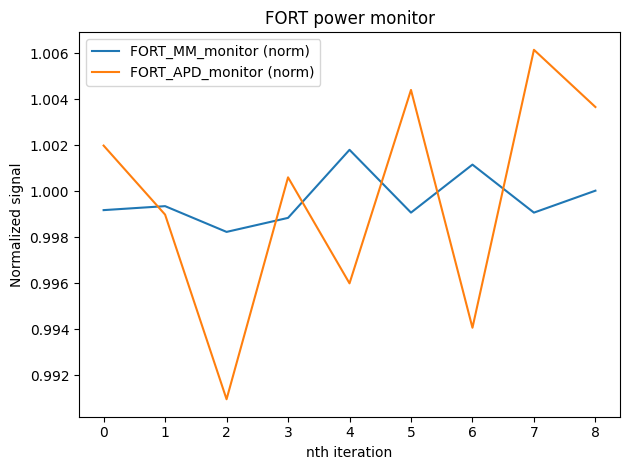

In [218]:
plt.figure()

plt.plot(
    FORT_MM_monitor / best_852_power_ref / (FORT_APD_monitor / set_point_FORT_APD_loading),
    label="FORT_MM_monitor (norm)"
)

plt.plot(
    FORT_APD_monitor / set_point_FORT_APD_loading,
    label="FORT_APD_monitor (norm)"
)

plt.xlabel("nth iteration")
plt.ylabel("Normalized signal")
plt.title("FORT power monitor")
# plt.ylim(0,1.1)
plt.legend()
plt.tight_layout()
plt.show()

### Fidelity Calculations

In [89]:
"""
Fidelity calculations.

The best I have so far:
### z-basis values from the bar chart RID 30757
P_SPCM0_Z1 = [0.55, 0.05]
P_SPCM1_Z1 = [0.02, 0.014]
P_SPCM0_Zm1 = [0.02, 0.014]
P_SPCM1_Zm1 = [0.41, 0.049]

### x-basis values from the bar chart RID 31379
P_SPCM0_X1 = [0.46, 0.05]
P_SPCM1_X1 = [0.03, 0.017]
P_SPCM0_Xm1 = [0.0, 0.0]
P_SPCM1_Xm1 = [0.51, 0.05]

"""
# ### z-basis values from the bar chart from the bar chart RID14762
# P_SPCM1_Z1 = [0.035, 0.027]
# P_SPCM0_Z1 = [0.38, 0.017]
# P_SPCM1_Zm1 = [0.462, 0.049]
# P_SPCM0_Zm1 = [0.127, 0.058]

# ### x-basis values from the bar chart RID 31379
# P_SPCM1_X1 = [0.035, 0.027]
# P_SPCM0_X1 = [0.03, 0.017]
# P_SPCM1_Xm1 = [0.0, 0.0]
# P_SPCM0_Xm1 = [0.51, 0.05]


# ### z-basis values from the bar chart RID 30757
# P_SPCM0_Z1 = [0.55, 0.05]
# P_SPCM1_Z1 = [0.02, 0.014]
# P_SPCM0_Zm1 = [0.02, 0.014]
# P_SPCM1_Zm1 = [0.41, 0.049]

# ### x-basis values from the bar chart RID 31379
# P_SPCM0_X1 = [0.46, 0.05]
# P_SPCM1_X1 = [0.03, 0.017]
# P_SPCM0_Xm1 = [0.0, 0.0]
# P_SPCM1_Xm1 = [0.51, 0.05]


### Node2 results 2026-07-28
### z-basis values from the bar chart RID 18790
# ##### 0.9 - with 4 SPCMs
# P_SPCM1_Z1 = [0.018, 0.012]
# P_SPCM0_Z1 = [0.514, 0.030]
# P_SPCM1_Zm1 = [0.440, 0.029]
# P_SPCM0_Zm1 = [0.037, 0.014]
# P_SPCM1_X1 = [0.018, 0.012]
# P_SPCM0_X1 = [0.514, 0.030]
# P_SPCM1_Xm1 = [0.440, 0.029]
# P_SPCM0_Xm1 = [0.037, 0.014]

# # ##### 0.919 - only with Node1 SPCMs
# P_SPCM1_Z1 = [0.009, 0.021]
# P_SPCM0_Z1 = [0.554, 0.038]
# P_SPCM1_Zm1 = [0.402, 0.047]
# P_SPCM0_Zm1 = [0.032, 0.040]
# P_SPCM1_X1 = [0.009, 0.021]
# P_SPCM0_X1 = [0.554, 0.038]
# P_SPCM1_Xm1 = [0.402, 0.047]
# P_SPCM0_Xm1 = [0.032, 0.040]

# ### Node2 results 2026-07-28 Accounting for inefficiency
# ### z-basis values from the bar chart RID 18850
# P_SPCM1_Z1 = [0.580, 0.029]
# P_SPCM0_Z1 = [0.000, 0.007]
# P_SPCM1_Zm1 = [0.031, 0.013]
# P_SPCM0_Zm1 = [0.409, 0.027]

# ### x-basis values from the bar chart RID 19120
# P_SPCM1_X1 = [0.501, 0.028]
# P_SPCM0_X1 = [0.023, 0.011]
# P_SPCM1_Xm1 = [0.030, 0.014]
# P_SPCM0_Xm1 = [0.411, 0.027]


# ### Node2 results 2026-08-03
# ### z
# P_SPCM1_Z1 = [0.572, 0.029]
# P_SPCM0_Z1 = [0.016, 0.012]
# P_SPCM1_Zm1 = [0.013, 0.010]
# P_SPCM0_Zm1 = [0.420, 0.027]

# P_SPCM0_X1 = [0.037, 0.021]
# P_SPCM1_X1 = [0.517, 0.050]
# P_SPCM0_Xm1 = [0.417, 0.049]
# P_SPCM1_Xm1 = [0.029, 0.017]


# P_SPCM1_Z1 = [0.565, 0.029]
# P_SPCM0_Z1 = [0.017, 0.012]
# P_SPCM1_Zm1 = [0.013, 0.010]
# P_SPCM0_Zm1 = [0.425, 0.027]

P_SPCM1_Z1 = [0.000, 0.000]
P_SPCM0_Z1 = [0.558, 0.050]
P_SPCM1_Zm1 = [0.413, 0.049]
P_SPCM0_Zm1 = [0.029, 0.017]

P_SPCM1_X1 = [0.035, 0.020]
P_SPCM0_X1 = [0.525, 0.050]
P_SPCM1_Xm1 = [0.411, 0.049]
P_SPCM0_Xm1 = [0.029, 0.017]



# ### x-basis values from the bar chart RID 18904 
# P_SPCM1_X1 = [0.037, 0.021]
# P_SPCM0_X1 = [0.517, 0.050]
# P_SPCM1_Xm1 = [0.417, 0.049]
# P_SPCM0_Xm1 = [0.029, 0.017]

# P_SPCM1_X1 = [0.550, 0.029]
# P_SPCM0_X1 = [0.029, 0.013]
# P_SPCM1_Xm1 = [0.059, 0.017]
# P_SPCM0_Xm1 = [0.387, 0.026]

# P_SPCM0_X1 = [0.037, 0.021]
# P_SPCM1_X1 = [0.517, 0.050]
# P_SPCM0_Xm1 = [0.417, 0.049]
# P_SPCM1_Xm1 = [0.029, 0.017]


# Unpack (value, sigma)
a, da = P_SPCM0_Z1
b, db = P_SPCM1_Z1
c, dc = P_SPCM0_Zm1
d, dd = P_SPCM1_Zm1
e, de = P_SPCM0_X1
f, df = P_SPCM1_X1
g, dg = P_SPCM0_Xm1
h, dh = P_SPCM1_Xm1

# --- Helper: variance for sqrt(b*c) with independence ---
def sqrt_prod_sigma2(b, db, c, dc):
    # handle edge cases robustly
    if b <= 0 or c <= 0:
        return 0.0
    y = np.sqrt(b*c)
    dy_db = 0.5*np.sqrt(c/b)
    dy_dc = 0.5*np.sqrt(b/c)
    return (dy_db*db)**2 + (dy_dc*dc)**2  # covariances assumed 0

# Compute central value
sqrt_bc = np.sqrt(max(b*c, 0.0))
F_low = 0.5*(a + d - 2.0*sqrt_bc + e + h - f - g)

# Propagate uncertainty (sum/diff → variances add; factor -2 gives ×4 on the variance of sqrt term)
var_sqrt = sqrt_prod_sigma2(b, db, c, dc)
var_F = 0.25*(da**2 + dd**2 + 4.0*var_sqrt + de**2 + dh**2 + df**2 + dg**2)
F_low_err = np.sqrt(max(var_F, 0.0))

print(f"Fidelity lower bound = {F_low:.3f} ± {F_low_err:.3f}")


Fidelity lower bound = 0.922 ± 0.051


### [QWP] Joint Probabilities with AllSPCMs - In 3x2 plot all selected files

experiment: atom_photon_parity_9_AllSPCM_experiment
override: {'t_start_MW_mapping_mu': 10000, 'monitor_magnetometer_in_end_measurement': False, 'target_780_HWP': 20.0, 'f_microwaves_m11_dds':331.939*MHz, 't_MW_RF_pulse': 45*us, 't_photon_collection_time': 150*ns, 'gate_start_offset_mu': 500, 'n_excitation_attempts': 1}
Photon clicks included: original BS output = 470, other BS output = 530, combined = 1000
Visibility (H | mF=+1): 0.433 ± 0.174
Visibility (V | mF=+1): 0.162 ± 0.059
Visibility (H | mF=-1): 0.149 ± 0.052
Visibility (V | mF=-1): 0.714 ± 0.099

RID: 19016, n_measurements: 100, 780_HWP: 20.0, t_start_MW_mapping_mu: 10000, t_MW_RF_pulse: 4.4999999999999996e-05
Visibility (sum A): 0.358 ± 0.081
Visibility (sum B): 0.100 ± 0.025

Optimal QWP angle θ* = 55.530° (maximum separation = 0.722)
P_SPCM1_Z1 = [0.076, 0.015]
P_SPCM0_Z1 = [0.364, 0.028]
P_SPCM1_Zm1 = [0.484, 0.029]
P_SPCM0_Zm1 = [0.050, 0.014]
P_SPCM1_X1 = [0.076, 0.015]
P_SPCM0_X1 = [0.364, 0.028]
P_SPCM1_Xm1 = [0.484,

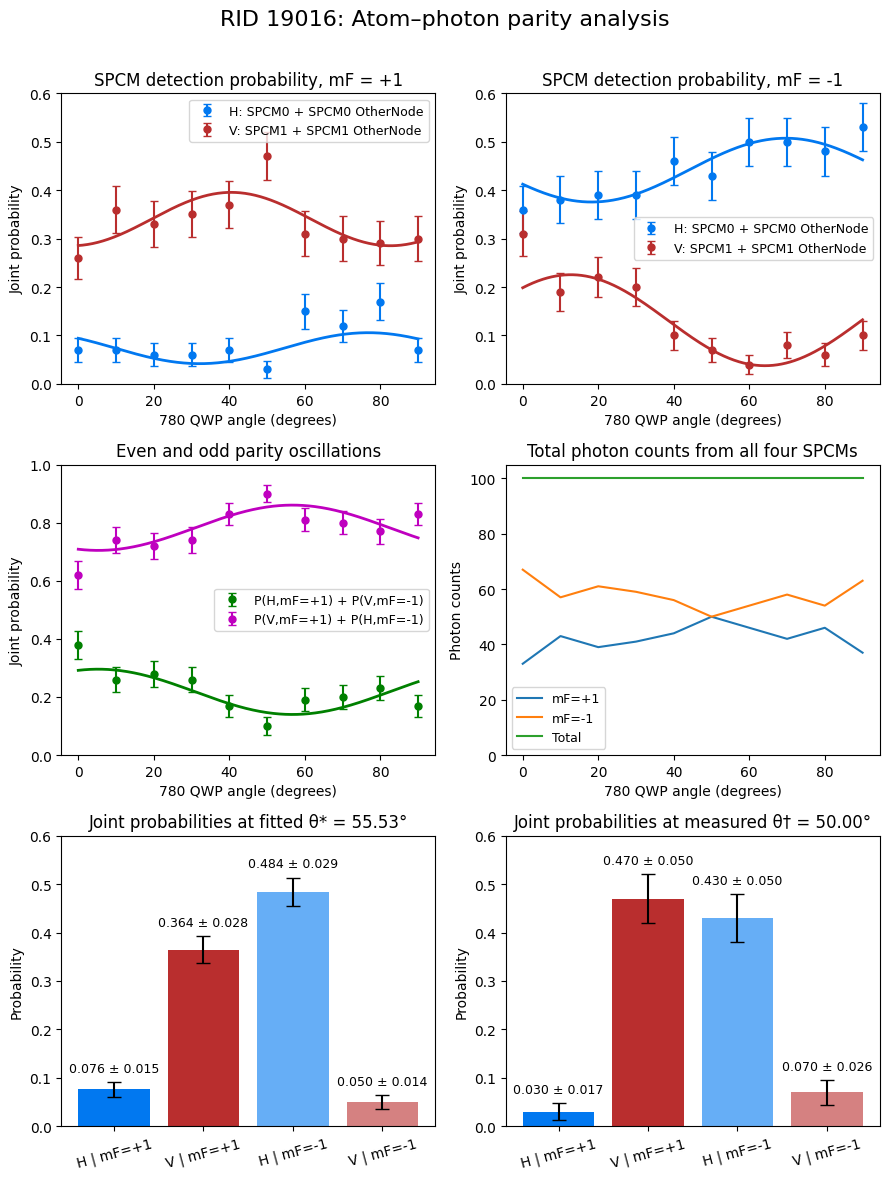

In [437]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


file_indices = {
    # 117:'',
    # 119:'',
    # 122:''

    81:''
} 

for idx,f_item in enumerate(file_indices.items()):
    f_idx,f_comment = f_item   # idx - f_item = {f_idx: f_comment}
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    print("experiment:",experiment_function)
    print("override:",override_ExperimentVariables)
    
    # ============================================================
    # Prepare data
    # ============================================================
    
    angles = angle_780_QWP
    
    spcm0 = SPCM0_SinglePhoton[1:] > 0
    spcm1 = SPCM1_SinglePhoton[1:] > 0
    spcm0_OtherNode = SPCM0_OtherNode_SinglePhoton[1:] > 0
    spcm1_OtherNode = SPCM1_OtherNode_SinglePhoton[1:] > 0
    
    # spcm0 = spcm0_OtherNode
    # spcm1 = spcm1_OtherNode
    # spcm0_OtherNode = SPCM0_SinglePhoton[1:] > 0
    # spcm1_OtherNode = SPCM1_SinglePhoton[1:] > 0
    # spcm0 = SPCM0_OtherNode_SinglePhoton[1:] > 0
    # spcm1 = SPCM1_OtherNode_SinglePhoton[1:] > 0
    
    # Alternative datasets:
    # spcm0 = SPCM0_SinglePhoton_parity[1:] > 0
    # spcm1 = SPCM1_SinglePhoton_parity[1:] > 0
    # spcm0_OtherNode = SPCM0_OtherNode_SinglePhoton_parity[1:] > 0
    # spcm1_OtherNode = SPCM1_OtherNode_SinglePhoton_parity[1:] > 0
    
    spcm0_combined = spcm0.astype(np.int8) + spcm0_OtherNode.astype(np.int8)  # H
    spcm1_combined = spcm1.astype(np.int8) + spcm1_OtherNode.astype(np.int8)  # V
    
    atom_signal = AllSPCMs_parity_RO[1:] / t_SPCM_second_shot
    atom_Z1_mask = atom_signal <= single_atom_threshold
    atom_Zm1_mask = ~atom_Z1_mask
    
    event_lengths = {
        "angles": len(angles),
        "spcm0": len(spcm0),
        "spcm1": len(spcm1),
        "spcm0_OtherNode": len(spcm0_OtherNode),
        "spcm1_OtherNode": len(spcm1_OtherNode),
        "atom_signal": len(atom_signal),
    }
    
    if len(set(event_lengths.values())) != 1:
        raise ValueError(f"Per-event array length mismatch: {event_lengths}")
    
    unique_angles = np.unique(angles)
    
    clicks_original_arm = int(np.sum(spcm0) + np.sum(spcm1))
    clicks_other_arm = int(np.sum(spcm0_OtherNode) + np.sum(spcm1_OtherNode))
    clicks_combined = clicks_original_arm + clicks_other_arm
    
    print(f"Photon clicks included: original BS output = {clicks_original_arm}, other BS output = {clicks_other_arm}, combined = {clicks_combined}")
    
    
    # ============================================================
    # Channel-efficiency correction
    # ============================================================
    
    eta_SPCM0_channel = 1.0
    eta_SPCM1_channel = 1.0
    # eta_SPCM1_channel = 0.7
    eta_SPCM0_OtherNode_channel = 1.0
    eta_SPCM1_OtherNode_channel = 1.0 
    w_SPCM0 = 1.0 / float(eta_SPCM0_channel)
    w_SPCM1 = 1.0 / float(eta_SPCM1_channel)
    w_SPCM0_OtherNode = 1.0 / float(eta_SPCM0_OtherNode_channel)
    w_SPCM1_OtherNode = 1.0 / float(eta_SPCM1_OtherNode_channel)
    
    
    # ============================================================
    # Analysis helper functions
    # ============================================================
    
    def bin_counts_for_state(angles, spcm0_combined, spcm1_combined, atom_mask):
        x, c0, c1 = [], [], []
    
        for angle in unique_angles:
            selected = (angles == angle) & atom_mask
            x.append(angle)
            c0.append(int(np.sum(spcm0_combined[selected])))
            c1.append(int(np.sum(spcm1_combined[selected])))
    
        return np.asarray(x), np.asarray(c0, dtype=int), np.asarray(c1, dtype=int)
    
    
    def corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1, group_mask):
        counts = np.vstack([counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1]).astype(float)
        weights = np.array([w_SPCM0, w_SPCM1, w_SPCM0_OtherNode, w_SPCM1_OtherNode], dtype=float)[:, None]
        mask = np.asarray(group_mask, dtype=bool)[:, None]
    
        weighted_counts = weights * counts
        denominator = np.sum(weighted_counts, axis=0)
        numerator = np.sum(weighted_counts * mask, axis=0)
    
        probability = np.full_like(denominator, np.nan, dtype=float)
        np.divide(numerator, denominator, out=probability, where=denominator > 0)
    
        gradient = np.zeros_like(counts, dtype=float)
        valid = denominator > 0
        gradient[:, valid] = weights * (mask.astype(float) - probability[None, valid]) / denominator[None, valid]
    
        variance = np.sum(gradient**2 * counts, axis=0)
        probability_error = np.sqrt(np.maximum(variance, 0.0))
    
        return probability, probability_error
    
    
    def sinusoid_varf(theta_deg, amplitude, frequency, phase, offset):
        return amplitude * np.cos(np.deg2rad(frequency * theta_deg) + phase) + offset
    
    
    def fit_sinusoid_prob(x, probability, probability_error, f0=4.0):
        x = np.asarray(x, dtype=float)
        probability = np.asarray(probability, dtype=float)
        sigma = np.clip(np.asarray(probability_error, dtype=float), 1e-6, None)
    
        amplitude_guess = (np.nanmax(probability) - np.nanmin(probability)) / 2.0 if np.isfinite(probability).all() else 0.2
        offset_guess = np.nanmean(probability) if np.isfinite(probability).all() else 0.5
    
        bounds = ([-1.0, 3.5, -2 * np.pi, 0.0], [1.0, 4.5, 2 * np.pi, 1.0])
        initial_parameters = [np.clip(amplitude_guess, 0.0, 0.9), f0, 0.0, np.clip(offset_guess, 0.0, 1.0)]
    
        popt, pcov = curve_fit(
            sinusoid_varf,
            x,
            probability,
            p0=initial_parameters,
            sigma=sigma,
            absolute_sigma=True,
            bounds=bounds,
            maxfev=20000,
        )
    
        perr = np.sqrt(np.diag(pcov))
        amplitude, frequency, phase, offset = popt
        amplitude_error, offset_error = perr[0], perr[3]
        covariance_amplitude_offset = pcov[0, 3]
    
        if offset <= 0:
            visibility, visibility_error = np.nan, np.nan
        else:
            visibility = np.abs(amplitude) / offset
            sign_amplitude = 1.0 if amplitude >= 0 else -1.0
            dV_dA = sign_amplitude / offset
            dV_dOffset = -np.abs(amplitude) / offset**2
            visibility_variance = dV_dA**2 * amplitude_error**2 + dV_dOffset**2 * offset_error**2 + 2 * dV_dA * dV_dOffset * covariance_amplitude_offset
            visibility_error = np.sqrt(max(visibility_variance, 0.0))
    
        x_fit = np.linspace(x.min(), x.max(), 400)
        y_fit = sinusoid_varf(x_fit, *popt)
    
        return popt, perr, (x_fit, y_fit), (visibility, visibility_error), pcov
    
    
    def fit_eval(theta_deg, popt):
        return np.clip(sinusoid_varf(np.asarray(theta_deg, dtype=float), *popt), 0.0, 1.0)
    
    
    def prob_sigma_at_theta(theta_deg, popt, pcov):
        amplitude, frequency, phase, offset = popt
        argument = np.deg2rad(frequency * theta_deg) + phase
        jacobian = np.array([np.cos(argument), -amplitude * np.sin(argument) * np.pi / 180.0 * theta_deg, -amplitude * np.sin(argument), 1.0])
        return np.sqrt(max(float(jacobian @ pcov @ jacobian), 0.0))
    
    
    # ============================================================
    # Plotting helper functions
    # ============================================================
    
    def probability_ylim(*arrays):
        finite_values = []
    
        for array in arrays:
            array = np.asarray(array, dtype=float).ravel()
            finite_values.extend(array[np.isfinite(array)])
    
        if len(finite_values) == 0:
            return 1.0
    
        y_max = np.max(finite_values)
        return max(0.1, min(1.0, np.ceil((y_max - 1e-12) * 10) / 10))
    
    
    def count_ylim(*arrays):
        finite_values = []
    
        for array in arrays:
            array = np.asarray(array, dtype=float).ravel()
            finite_values.extend(array[np.isfinite(array)])
    
        if len(finite_values) == 0:
            return 1.0
    
        y_max = np.max(finite_values)
    
        if y_max <= 10:
            step = 1
        elif y_max <= 100:
            step = 10
        elif y_max <= 1000:
            step = 100
        else:
            step = 10 ** np.floor(np.log10(y_max))
    
        return np.ceil((y_max - 1e-12) / step) * step
    
    
    def plot_probability_subplot(ax, x, y0, err0, y1, err1, fit0, fit1, title, labels, colors):
        ax.errorbar(x, y0, yerr=err0, fmt="o", markersize=5, capsize=3, color=colors[0], label=labels[0])
        ax.errorbar(x, y1, yerr=err1, fmt="o", markersize=5, capsize=3, color=colors[1], label=labels[1])
        ax.plot(fit0[0], fit0[1], "-", linewidth=2, color=colors[0])
        ax.plot(fit1[0], fit1[1], "-", linewidth=2, color=colors[1])
    
        ax.set_xlabel("780 QWP angle (degrees)")
        ax.set_ylabel("Joint probability")
        ax.set_title(title)
        ax.set_ylim(0, probability_ylim(y0 + err0, y1 + err1, fit0[1], fit1[1]))
        ax.legend(fontsize=9)
        ax.grid(False)
    
    
    def plot_bar_subplot(ax, labels, values, errors, title):
        x_positions = np.arange(len(labels))
        values = np.asarray(values, dtype=float)
        errors = np.asarray(errors, dtype=float)
        colors = [(*color1[:3], 1.0), (*color2[:3], 1.0), (*color1[:3], 0.6), (*color2[:3], 0.6)]
    
        bars = ax.bar(x_positions, values, yerr=errors, capsize=5, color=colors, edgecolor="none", linewidth=0)
        y_max = probability_ylim(values + errors)
    
        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, rotation=15)
        ax.set_ylabel("Probability")
        ax.set_title(title)
        ax.set_ylim(0, y_max)
        ax.grid(False)
    
        for bar, value, error in zip(bars, values, errors):
            text_y = min(value + error + 0.015, y_max - 0.02)
            ax.text(bar.get_x() + bar.get_width() / 2, text_y, f"{value:.3f} ± {error:.3f}", ha="center", va="bottom", fontsize=9)
    
    
    # ============================================================
    # Bin counts
    # ============================================================
    
    angles_Z1, counts_SPCM0_Z1, counts_SPCM1_Z1 = bin_counts_for_state(angles, spcm0_combined, spcm1_combined, atom_Z1_mask)
    angles_Zm1, counts_SPCM0_Zm1, counts_SPCM1_Zm1 = bin_counts_for_state(angles, spcm0_combined, spcm1_combined, atom_Zm1_mask)
    
    total_counts = counts_SPCM0_Z1 + counts_SPCM1_Z1 + counts_SPCM0_Zm1 + counts_SPCM1_Zm1
    
    
    # ============================================================
    # Four joint probabilities
    # ============================================================
    
    prob_SPCM0_Z1, prob_err_SPCM0_Z1 = corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1, [True, False, False, False])
    prob_SPCM1_Z1, prob_err_SPCM1_Z1 = corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1, [False, True, False, False])
    prob_SPCM0_Zm1, prob_err_SPCM0_Zm1 = corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1, [False, False, True, False])
    prob_SPCM1_Zm1, prob_err_SPCM1_Zm1 = corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1, [False, False, False, True])
    
    
    # ============================================================
    # Fit four joint probabilities
    # ============================================================
    
    popt0_Z1, _, (angles_fit_SPCM0_Z1, y_fit_SPCM0_Z1), (vis_SPCM0_Z1, vis_err_SPCM0_Z1), pcov0_Z1 = fit_sinusoid_prob(angles_Z1, prob_SPCM0_Z1, prob_err_SPCM0_Z1)
    popt1_Z1, _, (angles_fit_SPCM1_Z1, y_fit_SPCM1_Z1), (vis_SPCM1_Z1, vis_err_SPCM1_Z1), pcov1_Z1 = fit_sinusoid_prob(angles_Z1, prob_SPCM1_Z1, prob_err_SPCM1_Z1)
    popt0_Zm1, _, (angles_fit_SPCM0_Zm1, y_fit_SPCM0_Zm1), (vis_SPCM0_Zm1, vis_err_SPCM0_Zm1), pcov0_Zm1 = fit_sinusoid_prob(angles_Zm1, prob_SPCM0_Zm1, prob_err_SPCM0_Zm1)
    popt1_Zm1, _, (angles_fit_SPCM1_Zm1, y_fit_SPCM1_Zm1), (vis_SPCM1_Zm1, vis_err_SPCM1_Zm1), pcov1_Zm1 = fit_sinusoid_prob(angles_Zm1, prob_SPCM1_Zm1, prob_err_SPCM1_Zm1)
    
    print(f"Visibility (H | mF=+1): {vis_SPCM0_Z1:.3f} ± {vis_err_SPCM0_Z1:.3f}")
    print(f"Visibility (V | mF=+1): {vis_SPCM1_Z1:.3f} ± {vis_err_SPCM1_Z1:.3f}")
    print(f"Visibility (H | mF=-1): {vis_SPCM0_Zm1:.3f} ± {vis_err_SPCM0_Zm1:.3f}")
    print(f"Visibility (V | mF=-1): {vis_SPCM1_Zm1:.3f} ± {vis_err_SPCM1_Zm1:.3f}")
    
    
    # ============================================================
    # Even and odd parity
    # ============================================================
    
    prob_sum_A, err_sum_A = corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1, [True, False, False, True])
    prob_sum_B, err_sum_B = corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1, [False, True, True, False])
    
    popt_sumA, _, (xfit_sumA, yfit_sumA), (vis_sumA, viserr_sumA), _ = fit_sinusoid_prob(unique_angles, prob_sum_A, err_sum_A)
    popt_sumB, _, (xfit_sumB, yfit_sumB), (vis_sumB, viserr_sumB), _ = fit_sinusoid_prob(unique_angles, prob_sum_B, err_sum_B)
    
    print()
    print(f"RID: {rid}, n_measurements: {n_measurements}, 780_HWP: {angle_780_HWP[0]}, t_start_MW_mapping_mu: {t_start_MW_mapping_mu}, t_MW_RF_pulse: {t_MW_RF_pulse}")
    print(f"Visibility (sum A): {vis_sumA:.3f} ± {viserr_sumA:.3f}")
    print(f"Visibility (sum B): {vis_sumB:.3f} ± {viserr_sumB:.3f}")
    
    
    # ============================================================
    # Best angle from fitted curves
    # ============================================================
    
    theta_grid = np.linspace(float(unique_angles.min()), float(unique_angles.max()), 5001)
    
    y0_Z1_grid = fit_eval(theta_grid, popt0_Z1)
    y1_Z1_grid = fit_eval(theta_grid, popt1_Z1)
    y0_Zm1_grid = fit_eval(theta_grid, popt0_Zm1)
    y1_Zm1_grid = fit_eval(theta_grid, popt1_Zm1)
    
    separation_grid = np.abs(y0_Z1_grid - y1_Z1_grid) + np.abs(y0_Zm1_grid - y1_Zm1_grid)
    
    i_star = int(np.argmax(separation_grid))
    theta_star = float(theta_grid[i_star])
    
    P_SPCM0_mFplus = float(fit_eval(theta_star, popt0_Z1))
    P_SPCM1_mFplus = float(fit_eval(theta_star, popt1_Z1))
    P_SPCM0_mFminus = float(fit_eval(theta_star, popt0_Zm1))
    P_SPCM1_mFminus = float(fit_eval(theta_star, popt1_Zm1))
    
    print()
    print(f"Optimal QWP angle θ* = {theta_star:.3f}° (maximum separation = {separation_grid[i_star]:.3f})")
    
    
    # ============================================================
    # Fitted probability uncertainties
    # ============================================================
    
    labels = ["H | mF=+1", "V | mF=+1", "H | mF=-1", "V | mF=-1"]
    values = [P_SPCM0_mFplus, P_SPCM1_mFplus, P_SPCM0_mFminus, P_SPCM1_mFminus]
    errors = [
        prob_sigma_at_theta(theta_star, popt0_Z1, pcov0_Z1),
        prob_sigma_at_theta(theta_star, popt1_Z1, pcov1_Z1),
        prob_sigma_at_theta(theta_star, popt0_Zm1, pcov0_Zm1),
        prob_sigma_at_theta(theta_star, popt1_Zm1, pcov1_Zm1),
    ]
    
    
    # ============================================================
    # Best angle from measured data
    # ============================================================
    
    p11 = prob_SPCM0_Z1
    p22 = prob_SPCM1_Z1
    p33 = prob_SPCM0_Zm1
    p44 = prob_SPCM1_Zm1
    
    separation_data_1 = p11 + p44 - 2 * np.sqrt(p22 * p33)
    separation_data_2 = p22 + p33 - 2 * np.sqrt(p11 * p44)
    separation_data = separation_data_1 if np.nanmax(separation_data_1) > np.nanmax(separation_data_2) else separation_data_2
    
    idx_data_star = int(np.nanargmax(separation_data))
    theta_data_star = float(unique_angles[idx_data_star])
    Nstar = int(total_counts[idx_data_star])
    
    values_data = [
        float(prob_SPCM0_Z1[idx_data_star]),
        float(prob_SPCM1_Z1[idx_data_star]),
        float(prob_SPCM0_Zm1[idx_data_star]),
        float(prob_SPCM1_Zm1[idx_data_star]),
    ]
    
    errors_data = [
        float(prob_err_SPCM0_Z1[idx_data_star]),
        float(prob_err_SPCM1_Z1[idx_data_star]),
        float(prob_err_SPCM0_Zm1[idx_data_star]),
        float(prob_err_SPCM1_Zm1[idx_data_star]),
    ]
    
    ######
    
    bar_names_Z = ["P_SPCM1_Z1", "P_SPCM0_Z1", "P_SPCM1_Zm1", "P_SPCM0_Zm1"]
    bar_names_X = ["P_SPCM1_X1", "P_SPCM0_X1", "P_SPCM1_Xm1", "P_SPCM0_Xm1"]
    
    ### printing out for convenience
    for name, value, error in zip(bar_names_Z, values, errors):
        print(f"{name} = [{value:.3f}, {error:.3f}]")
    for name, value, error in zip(bar_names_X, values, errors):
        print(f"{name} = [{value:.3f}, {error:.3f}]")
        
    print(f"Data-selected QWP angle θ† = {theta_data_star:.3f}° (maximum separation = {separation_data[idx_data_star]:.3f}; N={Nstar})")
    
    ### printing out for convenience
    for name, value, error in zip(bar_names_Z, values, errors):
        print(f"{name} = [{value:.3f}, {error:.3f}]")
    for name, value, error in zip(bar_names_X, values, errors):
        print(f"{name} = [{value:.3f}, {error:.3f}]")
        
    # ============================================================
    # Combined 3-row × 2-column figure
    # ============================================================
    
    fig, axes = plt.subplots(3, 2, figsize=(9, 12))
    axes = axes.ravel()
    
    # Row 1: mF = +1 and mF = -1
    plot_probability_subplot(
        axes[0],
        angles_Z1,
        prob_SPCM0_Z1,
        prob_err_SPCM0_Z1,
        prob_SPCM1_Z1,
        prob_err_SPCM1_Z1,
        (angles_fit_SPCM0_Z1, y_fit_SPCM0_Z1),
        (angles_fit_SPCM1_Z1, y_fit_SPCM1_Z1),
        "SPCM detection probability, mF = +1",
        ["H: SPCM0 + SPCM0 OtherNode", "V: SPCM1 + SPCM1 OtherNode"],
        [color1, color2],
    )
    
    plot_probability_subplot(
        axes[1],
        angles_Zm1,
        prob_SPCM0_Zm1,
        prob_err_SPCM0_Zm1,
        prob_SPCM1_Zm1,
        prob_err_SPCM1_Zm1,
        (angles_fit_SPCM0_Zm1, y_fit_SPCM0_Zm1),
        (angles_fit_SPCM1_Zm1, y_fit_SPCM1_Zm1),
        "SPCM detection probability, mF = -1",
        ["H: SPCM0 + SPCM0 OtherNode", "V: SPCM1 + SPCM1 OtherNode"],
        [color1, color2],
    )
    
    # Row 2, left: parity
    plot_probability_subplot(
        axes[2],
        unique_angles,
        prob_sum_A,
        err_sum_A,
        prob_sum_B,
        err_sum_B,
        (xfit_sumA, yfit_sumA),
        (xfit_sumB, yfit_sumB),
        "Even and odd parity oscillations",
        ["P(H,mF=+1) + P(V,mF=-1)", "P(V,mF=+1) + P(H,mF=-1)"],
        ["g", "m"],
    )
    
    # Row 2, right: photon counts
    axes[3].plot(angles_Z1, counts_SPCM0_Z1 + counts_SPCM1_Z1, label="mF=+1")
    axes[3].plot(angles_Zm1, counts_SPCM0_Zm1 + counts_SPCM1_Zm1, label="mF=-1")
    axes[3].plot(angles_Zm1, total_counts, label="Total")
    axes[3].set_xlabel("780 QWP angle (degrees)")
    axes[3].set_ylabel("Photon counts")
    axes[3].set_title("Total photon counts from all four SPCMs")
    axes[3].set_ylim(0, count_ylim(total_counts)+5)
    axes[3].legend(fontsize=9)
    axes[3].grid(False)
    
    # Row 3: fitted and measured probabilities
    plot_bar_subplot(axes[4], labels, values, errors, f"Joint probabilities at fitted θ* = {theta_star:.2f}°")
    plot_bar_subplot(axes[5], labels, values_data, errors_data, f"Joint probabilities at measured θ† = {theta_data_star:.2f}°")
    
    fig.suptitle(f"RID {rid}: Atom–photon parity analysis", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig("Parity_analysis_3x2.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

### [RF pulse] Joint Probabilities with AllSPCMs - In 3x2 plot all selected files

In [507]:
scan_sequence1

array([38, 41, 44, 47, 50, 53], dtype=int32)

In [505]:
len(angle_780_QWP)

1000

experiment: atom_photon_parity_9_AllSPCM_experiment
override: {'t_start_MW_mapping_mu': 10000, 'monitor_magnetometer_in_end_measurement': False, 'target_780_QWP': 230.0, 'target_780_HWP':20.0,'f_microwaves_m11_dds':331.939*MHz, 't_MW_RF_pulse': 43*us, 't_photon_collection_time': 150*ns, 'gate_start_offset_mu': 500, 'n_excitation_attempts': 1}
Photon clicks included: original BS output = 265, other BS output = 335, combined = 600
Visibility (H | mF=+1): 0.597 ± 150.893
Visibility (V | mF=+1): 0.459 ± 38.214
Visibility (H | mF=-1): 15292871648.591 ± 47371034712230556860416.000
Visibility (V | mF=-1): 1.001 ± 0.099

RID: 19143, n_measurements: 100, 780_HWP: 20.0, t_start_MW_mapping_mu: 10000, t_MW_RF_pulse: 4.2999999999999995e-05
Visibility (sum A): 1.133 ± 327.857
Visibility (sum B): 0.396 ± 32.418

Optimal QWP angle θ* = 47.063° (maximum separation = 0.155)
P_SPCM1_Z1 = [0.529, 0.036]
P_SPCM0_Z1 = [0.408, 0.037]
P_SPCM1_Zm1 = [0.034, 0.012]
P_SPCM0_Zm1 = [0.000, 0.000]
P_SPCM1_X1 = [0.5

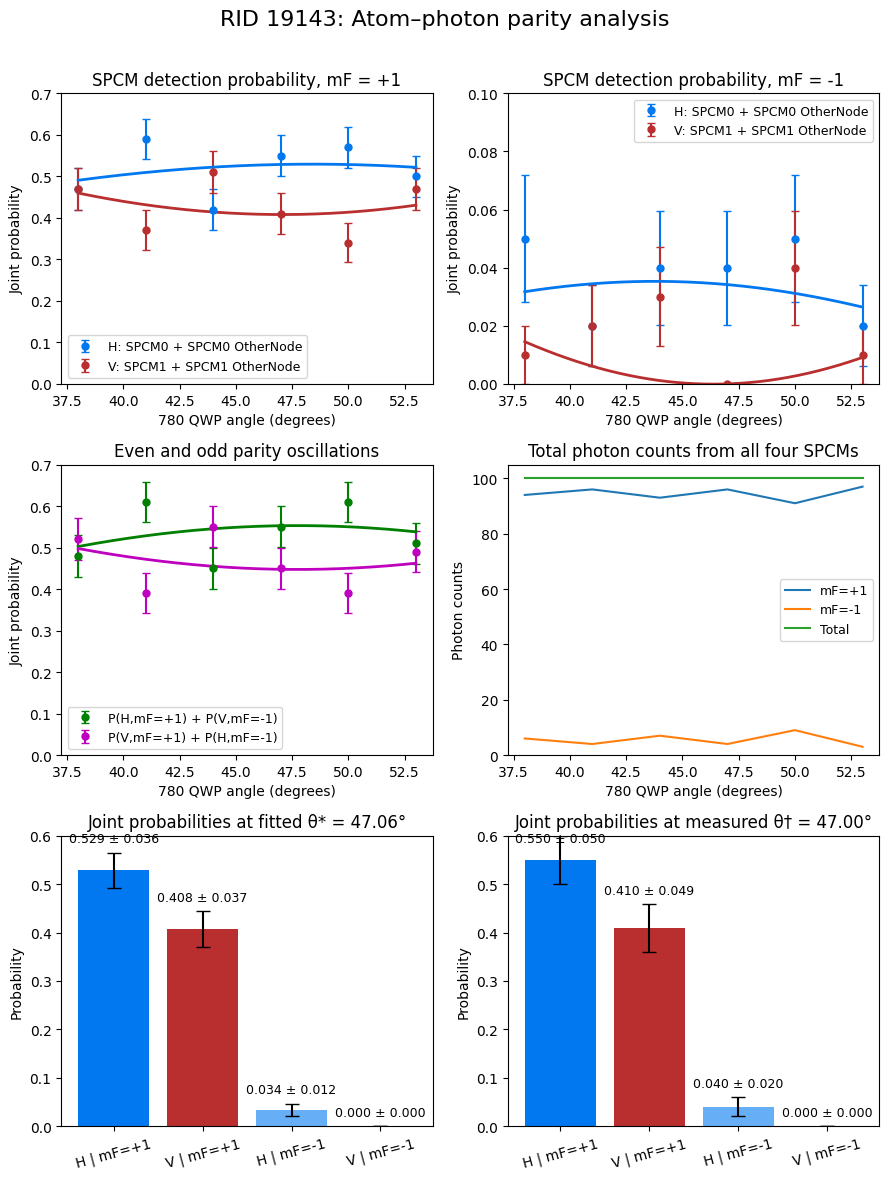

In [508]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


file_indices = {
    # 117:'',
    # 119:'',
    # 122:''

    144:''
} 

for idx,f_item in enumerate(file_indices.items()):
    f_idx,f_comment = f_item   # idx - f_item = {f_idx: f_comment}
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    print("experiment:",experiment_function)
    print("override:",override_ExperimentVariables)
    
    # ============================================================
    # Prepare data
    # ============================================================
    
    # angles = angle_780_QWP
    angles = np.repeat(scan_sequence1, 100)
    
    spcm0 = SPCM0_SinglePhoton[1:] > 0
    spcm1 = SPCM1_SinglePhoton[1:] > 0
    spcm0_OtherNode = SPCM0_OtherNode_SinglePhoton[1:] > 0
    spcm1_OtherNode = SPCM1_OtherNode_SinglePhoton[1:] > 0
    
    # spcm0 = spcm0_OtherNode
    # spcm1 = spcm1_OtherNode
    # spcm0_OtherNode = SPCM0_SinglePhoton[1:] > 0
    # spcm1_OtherNode = SPCM1_SinglePhoton[1:] > 0
    # spcm0 = SPCM0_OtherNode_SinglePhoton[1:] > 0
    # spcm1 = SPCM1_OtherNode_SinglePhoton[1:] > 0
    
    # Alternative datasets:
    # spcm0 = SPCM0_SinglePhoton_parity[1:] > 0
    # spcm1 = SPCM1_SinglePhoton_parity[1:] > 0
    # spcm0_OtherNode = SPCM0_OtherNode_SinglePhoton_parity[1:] > 0
    # spcm1_OtherNode = SPCM1_OtherNode_SinglePhoton_parity[1:] > 0
    
    spcm0_combined = spcm0.astype(np.int8) + spcm0_OtherNode.astype(np.int8)  # H
    spcm1_combined = spcm1.astype(np.int8) + spcm1_OtherNode.astype(np.int8)  # V
    
    atom_signal = AllSPCMs_parity_RO[1:] / t_SPCM_second_shot
    atom_Z1_mask = atom_signal <= single_atom_threshold
    atom_Zm1_mask = ~atom_Z1_mask
    
    event_lengths = {
        "angles": len(angles),
        "spcm0": len(spcm0),
        "spcm1": len(spcm1),
        "spcm0_OtherNode": len(spcm0_OtherNode),
        "spcm1_OtherNode": len(spcm1_OtherNode),
        "atom_signal": len(atom_signal),
    }
    
    if len(set(event_lengths.values())) != 1:
        raise ValueError(f"Per-event array length mismatch: {event_lengths}")
    
    unique_angles = np.unique(angles)
    
    clicks_original_arm = int(np.sum(spcm0) + np.sum(spcm1))
    clicks_other_arm = int(np.sum(spcm0_OtherNode) + np.sum(spcm1_OtherNode))
    clicks_combined = clicks_original_arm + clicks_other_arm
    
    print(f"Photon clicks included: original BS output = {clicks_original_arm}, other BS output = {clicks_other_arm}, combined = {clicks_combined}")
    
    
    # ============================================================
    # Channel-efficiency correction
    # ============================================================
    
    eta_SPCM0_channel = 1.0
    eta_SPCM1_channel = 1.0
    # eta_SPCM1_channel = 0.7
    eta_SPCM0_OtherNode_channel = 1.0
    eta_SPCM1_OtherNode_channel = 1.0 
    w_SPCM0 = 1.0 / float(eta_SPCM0_channel)
    w_SPCM1 = 1.0 / float(eta_SPCM1_channel)
    w_SPCM0_OtherNode = 1.0 / float(eta_SPCM0_OtherNode_channel)
    w_SPCM1_OtherNode = 1.0 / float(eta_SPCM1_OtherNode_channel)
    
    
    # ============================================================
    # Analysis helper functions
    # ============================================================
    
    def bin_counts_for_state(angles, spcm0_combined, spcm1_combined, atom_mask):
        x, c0, c1 = [], [], []
    
        for angle in unique_angles:
            selected = (angles == angle) & atom_mask
            x.append(angle)
            c0.append(int(np.sum(spcm0_combined[selected])))
            c1.append(int(np.sum(spcm1_combined[selected])))
    
        return np.asarray(x), np.asarray(c0, dtype=int), np.asarray(c1, dtype=int)
    
    
    def corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1, group_mask):
        counts = np.vstack([counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1]).astype(float)
        weights = np.array([w_SPCM0, w_SPCM1, w_SPCM0_OtherNode, w_SPCM1_OtherNode], dtype=float)[:, None]
        mask = np.asarray(group_mask, dtype=bool)[:, None]
    
        weighted_counts = weights * counts
        denominator = np.sum(weighted_counts, axis=0)
        numerator = np.sum(weighted_counts * mask, axis=0)
    
        probability = np.full_like(denominator, np.nan, dtype=float)
        np.divide(numerator, denominator, out=probability, where=denominator > 0)
    
        gradient = np.zeros_like(counts, dtype=float)
        valid = denominator > 0
        gradient[:, valid] = weights * (mask.astype(float) - probability[None, valid]) / denominator[None, valid]
    
        variance = np.sum(gradient**2 * counts, axis=0)
        probability_error = np.sqrt(np.maximum(variance, 0.0))
    
        return probability, probability_error
    
    
    def sinusoid_varf(theta_deg, amplitude, frequency, phase, offset):
        return amplitude * np.cos(np.deg2rad(frequency * theta_deg) + phase) + offset
    
    
    def fit_sinusoid_prob(x, probability, probability_error, f0=4.0):
        x = np.asarray(x, dtype=float)
        probability = np.asarray(probability, dtype=float)
        sigma = np.clip(np.asarray(probability_error, dtype=float), 1e-6, None)
    
        amplitude_guess = (np.nanmax(probability) - np.nanmin(probability)) / 2.0 if np.isfinite(probability).all() else 0.2
        offset_guess = np.nanmean(probability) if np.isfinite(probability).all() else 0.5
    
        bounds = ([-1.0, 3.5, -2 * np.pi, 0.0], [1.0, 4.5, 2 * np.pi, 1.0])
        initial_parameters = [np.clip(amplitude_guess, 0.0, 0.9), f0, 0.0, np.clip(offset_guess, 0.0, 1.0)]
    
        popt, pcov = curve_fit(
            sinusoid_varf,
            x,
            probability,
            p0=initial_parameters,
            sigma=sigma,
            absolute_sigma=True,
            bounds=bounds,
            maxfev=20000,
        )
    
        perr = np.sqrt(np.diag(pcov))
        amplitude, frequency, phase, offset = popt
        amplitude_error, offset_error = perr[0], perr[3]
        covariance_amplitude_offset = pcov[0, 3]
    
        if offset <= 0:
            visibility, visibility_error = np.nan, np.nan
        else:
            visibility = np.abs(amplitude) / offset
            sign_amplitude = 1.0 if amplitude >= 0 else -1.0
            dV_dA = sign_amplitude / offset
            dV_dOffset = -np.abs(amplitude) / offset**2
            visibility_variance = dV_dA**2 * amplitude_error**2 + dV_dOffset**2 * offset_error**2 + 2 * dV_dA * dV_dOffset * covariance_amplitude_offset
            visibility_error = np.sqrt(max(visibility_variance, 0.0))
    
        x_fit = np.linspace(x.min(), x.max(), 400)
        y_fit = sinusoid_varf(x_fit, *popt)
    
        return popt, perr, (x_fit, y_fit), (visibility, visibility_error), pcov
    
    
    def fit_eval(theta_deg, popt):
        return np.clip(sinusoid_varf(np.asarray(theta_deg, dtype=float), *popt), 0.0, 1.0)
    
    
    def prob_sigma_at_theta(theta_deg, popt, pcov):
        amplitude, frequency, phase, offset = popt
        argument = np.deg2rad(frequency * theta_deg) + phase
        jacobian = np.array([np.cos(argument), -amplitude * np.sin(argument) * np.pi / 180.0 * theta_deg, -amplitude * np.sin(argument), 1.0])
        return np.sqrt(max(float(jacobian @ pcov @ jacobian), 0.0))
    
    
    # ============================================================
    # Plotting helper functions
    # ============================================================
    
    def probability_ylim(*arrays):
        finite_values = []
    
        for array in arrays:
            array = np.asarray(array, dtype=float).ravel()
            finite_values.extend(array[np.isfinite(array)])
    
        if len(finite_values) == 0:
            return 1.0
    
        y_max = np.max(finite_values)
        return max(0.1, min(1.0, np.ceil((y_max - 1e-12) * 10) / 10))
    
    
    def count_ylim(*arrays):
        finite_values = []
    
        for array in arrays:
            array = np.asarray(array, dtype=float).ravel()
            finite_values.extend(array[np.isfinite(array)])
    
        if len(finite_values) == 0:
            return 1.0
    
        y_max = np.max(finite_values)
    
        if y_max <= 10:
            step = 1
        elif y_max <= 100:
            step = 10
        elif y_max <= 1000:
            step = 100
        else:
            step = 10 ** np.floor(np.log10(y_max))
    
        return np.ceil((y_max - 1e-12) / step) * step
    
    
    def plot_probability_subplot(ax, x, y0, err0, y1, err1, fit0, fit1, title, labels, colors):
        ax.errorbar(x, y0, yerr=err0, fmt="o", markersize=5, capsize=3, color=colors[0], label=labels[0])
        ax.errorbar(x, y1, yerr=err1, fmt="o", markersize=5, capsize=3, color=colors[1], label=labels[1])
        ax.plot(fit0[0], fit0[1], "-", linewidth=2, color=colors[0])
        ax.plot(fit1[0], fit1[1], "-", linewidth=2, color=colors[1])
    
        ax.set_xlabel("780 QWP angle (degrees)")
        ax.set_ylabel("Joint probability")
        ax.set_title(title)
        ax.set_ylim(0, probability_ylim(y0 + err0, y1 + err1, fit0[1], fit1[1]))
        ax.legend(fontsize=9)
        ax.grid(False)
    
    
    def plot_bar_subplot(ax, labels, values, errors, title):
        x_positions = np.arange(len(labels))
        values = np.asarray(values, dtype=float)
        errors = np.asarray(errors, dtype=float)
        colors = [(*color1[:3], 1.0), (*color2[:3], 1.0), (*color1[:3], 0.6), (*color2[:3], 0.6)]
    
        bars = ax.bar(x_positions, values, yerr=errors, capsize=5, color=colors, edgecolor="none", linewidth=0)
        y_max = probability_ylim(values + errors)
    
        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, rotation=15)
        ax.set_ylabel("Probability")
        ax.set_title(title)
        ax.set_ylim(0, y_max)
        ax.grid(False)
    
        for bar, value, error in zip(bars, values, errors):
            text_y = min(value + error + 0.015, y_max - 0.02)
            ax.text(bar.get_x() + bar.get_width() / 2, text_y, f"{value:.3f} ± {error:.3f}", ha="center", va="bottom", fontsize=9)
    
    
    # ============================================================
    # Bin counts
    # ============================================================
    
    angles_Z1, counts_SPCM0_Z1, counts_SPCM1_Z1 = bin_counts_for_state(angles, spcm0_combined, spcm1_combined, atom_Z1_mask)
    angles_Zm1, counts_SPCM0_Zm1, counts_SPCM1_Zm1 = bin_counts_for_state(angles, spcm0_combined, spcm1_combined, atom_Zm1_mask)
    
    total_counts = counts_SPCM0_Z1 + counts_SPCM1_Z1 + counts_SPCM0_Zm1 + counts_SPCM1_Zm1
    
    
    # ============================================================
    # Four joint probabilities
    # ============================================================
    
    prob_SPCM0_Z1, prob_err_SPCM0_Z1 = corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1, [True, False, False, False])
    prob_SPCM1_Z1, prob_err_SPCM1_Z1 = corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1, [False, True, False, False])
    prob_SPCM0_Zm1, prob_err_SPCM0_Zm1 = corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1, [False, False, True, False])
    prob_SPCM1_Zm1, prob_err_SPCM1_Zm1 = corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1, [False, False, False, True])
    
    
    # ============================================================
    # Fit four joint probabilities
    # ============================================================
    
    popt0_Z1, _, (angles_fit_SPCM0_Z1, y_fit_SPCM0_Z1), (vis_SPCM0_Z1, vis_err_SPCM0_Z1), pcov0_Z1 = fit_sinusoid_prob(angles_Z1, prob_SPCM0_Z1, prob_err_SPCM0_Z1)
    popt1_Z1, _, (angles_fit_SPCM1_Z1, y_fit_SPCM1_Z1), (vis_SPCM1_Z1, vis_err_SPCM1_Z1), pcov1_Z1 = fit_sinusoid_prob(angles_Z1, prob_SPCM1_Z1, prob_err_SPCM1_Z1)
    popt0_Zm1, _, (angles_fit_SPCM0_Zm1, y_fit_SPCM0_Zm1), (vis_SPCM0_Zm1, vis_err_SPCM0_Zm1), pcov0_Zm1 = fit_sinusoid_prob(angles_Zm1, prob_SPCM0_Zm1, prob_err_SPCM0_Zm1)
    popt1_Zm1, _, (angles_fit_SPCM1_Zm1, y_fit_SPCM1_Zm1), (vis_SPCM1_Zm1, vis_err_SPCM1_Zm1), pcov1_Zm1 = fit_sinusoid_prob(angles_Zm1, prob_SPCM1_Zm1, prob_err_SPCM1_Zm1)
    
    print(f"Visibility (H | mF=+1): {vis_SPCM0_Z1:.3f} ± {vis_err_SPCM0_Z1:.3f}")
    print(f"Visibility (V | mF=+1): {vis_SPCM1_Z1:.3f} ± {vis_err_SPCM1_Z1:.3f}")
    print(f"Visibility (H | mF=-1): {vis_SPCM0_Zm1:.3f} ± {vis_err_SPCM0_Zm1:.3f}")
    print(f"Visibility (V | mF=-1): {vis_SPCM1_Zm1:.3f} ± {vis_err_SPCM1_Zm1:.3f}")
    
    
    # ============================================================
    # Even and odd parity
    # ============================================================
    
    prob_sum_A, err_sum_A = corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1, [True, False, False, True])
    prob_sum_B, err_sum_B = corrected_joint_prob_and_err(counts_SPCM0_Z1, counts_SPCM1_Z1, counts_SPCM0_Zm1, counts_SPCM1_Zm1, [False, True, True, False])
    
    popt_sumA, _, (xfit_sumA, yfit_sumA), (vis_sumA, viserr_sumA), _ = fit_sinusoid_prob(unique_angles, prob_sum_A, err_sum_A)
    popt_sumB, _, (xfit_sumB, yfit_sumB), (vis_sumB, viserr_sumB), _ = fit_sinusoid_prob(unique_angles, prob_sum_B, err_sum_B)
    
    print()
    print(f"RID: {rid}, n_measurements: {n_measurements}, 780_HWP: {angle_780_HWP[0]}, t_start_MW_mapping_mu: {t_start_MW_mapping_mu}, t_MW_RF_pulse: {t_MW_RF_pulse}")
    print(f"Visibility (sum A): {vis_sumA:.3f} ± {viserr_sumA:.3f}")
    print(f"Visibility (sum B): {vis_sumB:.3f} ± {viserr_sumB:.3f}")
    
    
    # ============================================================
    # Best angle from fitted curves
    # ============================================================
    
    theta_grid = np.linspace(float(unique_angles.min()), float(unique_angles.max()), 5001)
    
    y0_Z1_grid = fit_eval(theta_grid, popt0_Z1)
    y1_Z1_grid = fit_eval(theta_grid, popt1_Z1)
    y0_Zm1_grid = fit_eval(theta_grid, popt0_Zm1)
    y1_Zm1_grid = fit_eval(theta_grid, popt1_Zm1)
    
    separation_grid = np.abs(y0_Z1_grid - y1_Z1_grid) + np.abs(y0_Zm1_grid - y1_Zm1_grid)
    
    i_star = int(np.argmax(separation_grid))
    theta_star = float(theta_grid[i_star])
    
    P_SPCM0_mFplus = float(fit_eval(theta_star, popt0_Z1))
    P_SPCM1_mFplus = float(fit_eval(theta_star, popt1_Z1))
    P_SPCM0_mFminus = float(fit_eval(theta_star, popt0_Zm1))
    P_SPCM1_mFminus = float(fit_eval(theta_star, popt1_Zm1))
    
    print()
    print(f"Optimal QWP angle θ* = {theta_star:.3f}° (maximum separation = {separation_grid[i_star]:.3f})")
    
    
    # ============================================================
    # Fitted probability uncertainties
    # ============================================================
    
    labels = ["H | mF=+1", "V | mF=+1", "H | mF=-1", "V | mF=-1"]
    values = [P_SPCM0_mFplus, P_SPCM1_mFplus, P_SPCM0_mFminus, P_SPCM1_mFminus]
    errors = [
        prob_sigma_at_theta(theta_star, popt0_Z1, pcov0_Z1),
        prob_sigma_at_theta(theta_star, popt1_Z1, pcov1_Z1),
        prob_sigma_at_theta(theta_star, popt0_Zm1, pcov0_Zm1),
        prob_sigma_at_theta(theta_star, popt1_Zm1, pcov1_Zm1),
    ]
    
    
    # ============================================================
    # Best angle from measured data
    # ============================================================
    
    p11 = prob_SPCM0_Z1
    p22 = prob_SPCM1_Z1
    p33 = prob_SPCM0_Zm1
    p44 = prob_SPCM1_Zm1
    
    separation_data_1 = p11 + p44 - 2 * np.sqrt(p22 * p33)
    separation_data_2 = p22 + p33 - 2 * np.sqrt(p11 * p44)
    separation_data = separation_data_1 if np.nanmax(separation_data_1) > np.nanmax(separation_data_2) else separation_data_2
    
    idx_data_star = int(np.nanargmax(separation_data))
    theta_data_star = float(unique_angles[idx_data_star])
    Nstar = int(total_counts[idx_data_star])
    
    values_data = [
        float(prob_SPCM0_Z1[idx_data_star]),
        float(prob_SPCM1_Z1[idx_data_star]),
        float(prob_SPCM0_Zm1[idx_data_star]),
        float(prob_SPCM1_Zm1[idx_data_star]),
    ]
    
    errors_data = [
        float(prob_err_SPCM0_Z1[idx_data_star]),
        float(prob_err_SPCM1_Z1[idx_data_star]),
        float(prob_err_SPCM0_Zm1[idx_data_star]),
        float(prob_err_SPCM1_Zm1[idx_data_star]),
    ]
    
    ######
    
    bar_names_Z = ["P_SPCM1_Z1", "P_SPCM0_Z1", "P_SPCM1_Zm1", "P_SPCM0_Zm1"]
    bar_names_X = ["P_SPCM1_X1", "P_SPCM0_X1", "P_SPCM1_Xm1", "P_SPCM0_Xm1"]
    
    ### printing out for convenience
    for name, value, error in zip(bar_names_Z, values, errors):
        print(f"{name} = [{value:.3f}, {error:.3f}]")
    for name, value, error in zip(bar_names_X, values, errors):
        print(f"{name} = [{value:.3f}, {error:.3f}]")
        
    print(f"Data-selected QWP angle θ† = {theta_data_star:.3f}° (maximum separation = {separation_data[idx_data_star]:.3f}; N={Nstar})")
    
    ### printing out for convenience
    for name, value, error in zip(bar_names_Z, values, errors):
        print(f"{name} = [{value:.3f}, {error:.3f}]")
    for name, value, error in zip(bar_names_X, values, errors):
        print(f"{name} = [{value:.3f}, {error:.3f}]")
        
    # ============================================================
    # Combined 3-row × 2-column figure
    # ============================================================
    
    fig, axes = plt.subplots(3, 2, figsize=(9, 12))
    axes = axes.ravel()
    
    # Row 1: mF = +1 and mF = -1
    plot_probability_subplot(
        axes[0],
        angles_Z1,
        prob_SPCM0_Z1,
        prob_err_SPCM0_Z1,
        prob_SPCM1_Z1,
        prob_err_SPCM1_Z1,
        (angles_fit_SPCM0_Z1, y_fit_SPCM0_Z1),
        (angles_fit_SPCM1_Z1, y_fit_SPCM1_Z1),
        "SPCM detection probability, mF = +1",
        ["H: SPCM0 + SPCM0 OtherNode", "V: SPCM1 + SPCM1 OtherNode"],
        [color1, color2],
    )
    
    plot_probability_subplot(
        axes[1],
        angles_Zm1,
        prob_SPCM0_Zm1,
        prob_err_SPCM0_Zm1,
        prob_SPCM1_Zm1,
        prob_err_SPCM1_Zm1,
        (angles_fit_SPCM0_Zm1, y_fit_SPCM0_Zm1),
        (angles_fit_SPCM1_Zm1, y_fit_SPCM1_Zm1),
        "SPCM detection probability, mF = -1",
        ["H: SPCM0 + SPCM0 OtherNode", "V: SPCM1 + SPCM1 OtherNode"],
        [color1, color2],
    )
    
    # Row 2, left: parity
    plot_probability_subplot(
        axes[2],
        unique_angles,
        prob_sum_A,
        err_sum_A,
        prob_sum_B,
        err_sum_B,
        (xfit_sumA, yfit_sumA),
        (xfit_sumB, yfit_sumB),
        "Even and odd parity oscillations",
        ["P(H,mF=+1) + P(V,mF=-1)", "P(V,mF=+1) + P(H,mF=-1)"],
        ["g", "m"],
    )
    
    # Row 2, right: photon counts
    axes[3].plot(angles_Z1, counts_SPCM0_Z1 + counts_SPCM1_Z1, label="mF=+1")
    axes[3].plot(angles_Zm1, counts_SPCM0_Zm1 + counts_SPCM1_Zm1, label="mF=-1")
    axes[3].plot(angles_Zm1, total_counts, label="Total")
    axes[3].set_xlabel("780 QWP angle (degrees)")
    axes[3].set_ylabel("Photon counts")
    axes[3].set_title("Total photon counts from all four SPCMs")
    axes[3].set_ylim(0, count_ylim(total_counts)+5)
    axes[3].legend(fontsize=9)
    axes[3].grid(False)
    
    # Row 3: fitted and measured probabilities
    plot_bar_subplot(axes[4], labels, values, errors, f"Joint probabilities at fitted θ* = {theta_star:.2f}°")
    plot_bar_subplot(axes[5], labels, values_data, errors_data, f"Joint probabilities at measured θ† = {theta_data_star:.2f}°")
    
    fig.suptitle(f"RID {rid}: Atom–photon parity analysis", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig("Parity_analysis_3x2.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)